In [71]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn # To ignore some warnings from sklearn logistic regression
from sklearn.exceptions import ConvergenceWarning # To avoid logistic regression failing in case of perfect separation

import datetime
import numpy as np
from scipy.optimize import minimize # minimizing function for AIOLI
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
import pandas as pd
from sklearn.linear_model import LogisticRegression # for classic logistic regression
from typing import Literal
from sklearn.neighbors import KDTree # For Knn for SMOTE

options={"disp": False} # To not get verbose from minimize function
np.set_printoptions(suppress=True, precision=4) #removes e notation
pd.options.display.float_format = '{:.10f}'.format # To remove e notation

# Global variables

In [72]:
default_n = 100
default_runs = 10
default_test_size = 100

# Algorithms

## Helper functions for algorithms

In [73]:
def sig(z):
    """ Sigmoid function that avoids overflow """
    if z < 0:
        return np.exp(z) / (1 + np.exp(z))
    else:
        return 1 / (1 + np.exp(-z))

In [74]:
def calculate_OTB(array, method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None, p = 0.5):
    """ Weighted average function
    ----
    Parameters:
        p: Proportion of last observations to average over. Ex p = 0.3 means average over last 30% of observations.
    Methods:
        Suffix averaging: Average over last p percentage of observations.
        Uniform: Average over all iterates equally
        Last iterate: Consider only the last iterate.
        """
    n = len(array)
    # Check p is a proportion
    if p is None:
        p = 0.5
    if not (0 <= p <= 1):
        raise ValueError("p must be between 0 and 1")

    match method:
        case "suffix_averaging":
            i = round((1-p)*n)
            result = np.mean(array[i:], axis=0)
        case "last_iterate":
            last_iterate = n - 1
            result = array[last_iterate]
        case _: # Uniform is default
            result = np.mean(array, axis=0)

    return result

In [75]:
def log_loss(betas,data_x,data_y):
    """ Works for a vector of betas and a whole dataset """
    return np.mean(np.logaddexp(0,-data_y*np.inner(data_x,betas)))

In [76]:
def generate_x(n,d, correlated = False, means = None, sds = None, highly_correlated = False, seed = 40, standardized = False):
    seed_used = seed
    rng = np.random.default_rng(seed) # Random number generator
    x = []

    if sds is None:
        sds = rng.uniform(0.1,0.5,d)
    if means is None:
        means = [rng.normal(1,sd,1).item() for sd in sds]
    # Put variances in covariance matrix
    cov = np.diag(sds**2)

    if not correlated:
        x = rng.multivariate_normal(means,cov, size = n)
    if correlated:
        # Create off diagonal, triangular matrix
        off_diag = np.triu(rng.uniform(0,2, size = (d,d)))
        cov = cov + off_diag + off_diag.T
        x = rng.multivariate_normal(means,cov, size = n)
    if highly_correlated and d == 3:
        x1 = generate_x(n,1, seed = seed_used)
        x2 = x1 + rng.normal(2,1)
        x3 = x1 + x2
        x = np.concatenate((x1,x2,x3), axis = 1)

    if standardized:
        standardized_x = (x - np.mean(x, axis=0) ) / np.std(x, axis=0)
        x = standardized_x
    return x


In [77]:
def generate_y(n,x, betas, seed = 40, plot = False, method: Literal["sigmoid", "sinusoidal", "quadratic", "sig(1/x)", "only_x1_x2"] | None = None):
    y = np.zeros(n)
    prob_y1 = np.zeros(n)
    rng = np.random.default_rng(seed) # Random number generator

    match method:
        case "sinusoidal":
            prob_y1 = [(1/2)*np.sin(5*np.inner(x_t,betas))+1/2 for x_t in x]

            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "quadratic":
            prob_y1 = [sig(np.inner((x_t**2),betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "sig(1/x)":
            prob_y1 = [sig(np.inner((1/x_t),betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "only_x1_x2":
            x1_x2 = x[:,0:2]
            prob_y1 = [sig(np.inner(x1_x2_t,betas[0:2])) for x1_x2_t in x1_x2]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "alternating":
             y = np.tile([1,-1],round(n/2))

        case "sign":
            y = [np.sign(np.inner(x_t,betas)) for x_t in x]

        case _: # Sigmoid function is default
            prob_y1 = [sig(np.inner(x_t,betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

    # Graphs
    if plot:
        for i in range(x.shape[1]):
            sns.scatterplot(x = x[:,i].flatten(), y = prob_y1)
            plt.title(f"P(Y=1) over x{i+1}")
            plt.show()

    return np.array(y)

In [78]:
(1/2)*np.sin(5*np.inner([1,-2,0.83],[2.4,0.8,-1.2]))+1/2

np.float64(0.0847513147540147)

## Generate data

In [215]:
def generate_data(setting, balanced = True, seed = 30, n = default_n, x_means = None, B = 4, a = 1, b = -1, plot_y = False, X_hazan = 1,d = 3, hyperparameter_analysis = False, betas = None, B_hazan = None):
    # Allocate space for variables
    x = []
    y = []
    betas = [] if betas is None else betas
    # betas = betas
    rng = np.random.default_rng(seed)
    hazan_py1 = 0
    # Define x means based on balanced or unbalanced setting
    x_means_simulation = [1,-2,0.83] if x_means is None else x_means
    # test_size = round(default_test_ratio*n)
    test_size = default_test_size
    full_n = n+test_size
    av_sigma_hidden = None

    # Generate data according to setup
    match setting:
        case "well specified":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            if None in betas or len(betas) == 0:
                betas = [0.4,-0.3,-1.2] if balanced else [-1,-1.7,2.6] # average sigmoid balanced: 0.5, unbalanced : 0.01

            y = generate_y(full_n,x,betas = betas, seed = seed)

        case "high dimensional":
            # Define betas and x means to fit high dimensionality
            betas = [2,0.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7] if balanced else [2,1.8,-3.7,1.4,0.5,0.2,-1,-0.3,2.2,0.1,0.6,1.9,-1.4,2.7,-1.4,0.5,-1,3.2,1.5,-1.5,-2.4,1.2,3.6,-0.8,-1.2]
            x_means_simulation = [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1]
            if hyperparameter_analysis:
                x_means_simulation = [2, -4.2, 1, 2.4, -1.6, -3.8, -5, -4.1,0.2, 6, 1, -3, 4.2, -2.1,5.6, -6,6.3, 4.5, -1.3, 6.2, 2.3, 1.4, 4, -2, 2] if balanced else [2, -4.2, 1, 2.4, -1.6, -3.8, -5, -4.1,0.2, 6, 1, -3, 4.2, -2.1,5.6, -6,6.3, 5.8, -1.3, 6.2, 2.3, 1.4, 4, -2, 2.6]
            # Generate x again for the high dimensional setting
            x = generate_x(full_n,25, means = x_means_simulation, seed = seed)
            y = generate_y(full_n,x,betas = betas, seed = seed)

        case "quadratic":
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            betas = [-1.44,0.5,-0.8] if balanced else [0.9,-1.1,-1.2]
            y = generate_y(full_n,x,betas = betas, seed = seed, method = "quadratic")
        case "hazan 1-dimensional":
            # B = np.log(full_n) if B_hazan is None else B_hazan
            B = 1 if B_hazan is None else B_hazan
            # B = 300
            # epsilon = (B**(2/3))/(n**(2/3))
            epsilon = 0.01
            theta = np.sqrt(epsilon)/B
            hazan_py1 = theta/2 + X_hazan*epsilon/B
            xy = rng.choice([[1- theta/2,a],[theta,b]], size = full_n, p = [theta/2 + X_hazan*epsilon/B, 1- (theta/2 + X_hazan*epsilon/B)])
            x = xy[:,0]
            y = xy[:,1]
            x = x.reshape(full_n,1)
        case "binomial_x":
            d = 1
            p_i = rng.uniform(0.1,0.9, d)
            n_i = rng.uniform(1,10, d).astype(int)
            x = rng.binomial(n = n_i, p = p_i, size = (full_n,d))
            # Just to have the correct d later
            x_means_simulation = np.zeros(d)
            # betas = rng.uniform(size = d,low = -0.5,high = 0.8)
            betas = rng.uniform(-0.8,0.8,d)
            av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3)
            # Ensure balance levels
            if balanced:
                threshold = 0.4
                while  av_sigma < threshold or av_sigma > threshold +0.2:
                    p_i = rng.uniform(0.1,0.9, d)
                    n_i = rng.uniform(1,10, d).astype(int)
                    x = rng.binomial(n = n_i, p = p_i, size = (full_n,d))
                    betas = rng.uniform(-0.8,0.8,d)
                    av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3)
            elif not balanced:
                threshold =  1 - 1 / n - 0.002
                # Sample betas again if its not unbalanced enough
                while  av_sigma < threshold :
                    p_i = rng.uniform(0.1,0.9, d)
                    n_i = rng.uniform(1,10, d).astype(int)
                    x = rng.binomial(n = n_i, p = p_i, size = (full_n,d))
                    betas = rng.uniform(-0.8,0.8,d)
                    av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3)
            prob_y1 = [sig(np.inner(xt,betas)) for xt in x]
            y = np.array([rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1])

            if d==1: x = x.reshape(full_n,1)
        case "highly correlated x":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed, highly_correlated = True)
            if None in betas or len(betas) == 0:
                betas = [2.4,0.8,-1.2] if balanced else [2.4,1.5,-1.2] # average sigmoid balanced: 0.5, unbalanced : 0.002

            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y)
        case "alternating":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            if None in betas or len(betas) == 0:
                betas = [2.4,0.8,-1.2] if balanced else [2.4,1.5,-1.2] # average sigmoid balanced: 0.5, unbalanced : 0.002
            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y, method = "alternating")
            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y)
        case "sinusoidal":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed)
            if None in betas or len(betas) == 0:
                betas = [2.4,1.8,-1.2] if balanced else [-0.104,0.5,1] # imbalanced is average 0.216
            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y, method = "sinusoidal")

        case "sign":
            # Generate data
            x = generate_x(full_n,d, means = x_means_simulation, seed = seed, sds = np.array([1,1,1]))
            if None in betas or len(betas) == 0:
                betas = [-0.8,-1.4,-2.6] if balanced else [1.3,-3.7,-1.2] # average
            y = generate_y(full_n,x,betas = betas, seed = seed, plot = plot_y, method = "sign")

        case "hidden x":
            # Define betas and x means to fit high dimensionality
            betas_hidden = [2,0.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7] if balanced else [2,1.8,-3.7,1.4,0.5,0.2,-1,-0.3,2.2,0.1,0.6,1.9,-1.4,2.7,-1.4,0.5,-1,3.2,1.5,-1.5,-2.4,1.2,3.6,-0.8,-1.2]
            betas = betas_hidden[:3]
            x_means_simulation_hidden = [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1]

            # Generate x again for the high dimensional setting
            x_hidden = generate_x(full_n,25, means = x_means_simulation_hidden, seed = seed)
            av_sigma_hidden = round(np.mean( [sig(xb) for xb in np.inner(x_hidden,betas_hidden)]),3)
            y = generate_y(full_n,x_hidden,betas = betas_hidden, seed = seed)

            x = x_hidden[:,:3]

    if setting == "hazan 1-dimensional":
        print(f"{n} (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of {hazan_py1}")
    else:
        d = len(x_means_simulation)
        if setting == "sign":

            print(f"{n} (training) samples were generated in the {setting} {"balanced" if balanced else "unbalanced"} setting. Using {d} variable(s), with an average P(Y=1) of {sum(y == 1)/len(y)}")
        else:
            av_sigma = round(np.mean( [sig(xb) for xb in np.inner(x,betas)]),3) if av_sigma_hidden is None else av_sigma_hidden
            av_sin = round(np.mean( [(1/2)*np.sin(5*xb) +1/2 for xb in np.inner(x,betas)]),3)
            print(f"{n} (training) samples were generated in the {setting} {"balanced" if balanced else "unbalanced"} setting. Using {d} variable(s), with an average P(Y=1) of {av_sin if setting == "sinusoidal" else av_sigma}")

    # Make train/test split

    x_train = x[test_size:]
    y_train = y[test_size:]
    x_test = x[:test_size]
    y_test = y[:test_size]

    return x_train, y_train, x_test, y_test

In [250]:
global_sinusoidal_unbalanced = [-0.104,0.5,1]
a,b,c,d = generate_data("sinusoidal", n = 100, balanced = False, B_hazan = 1 )
# [1,2,3,4][:2]
print(sum(b == 1)/len(b))
print(sum(d == 1)/len(d))

100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.331
0.34
0.26


In [81]:
np.log(20)

np.float64(2.995732273553991)

In [82]:
1/100

0.01

In [83]:
np.inner([1,-2,0.83],[1.2,-0.3,-1.2])

np.float64(0.8039999999999999)

In [84]:
c

array([[-1.6614,  1.7914,  0.4614],
       [-1.5881,  1.7264,  0.6591],
       [-1.5327,  1.9358,  0.3091],
       [-1.5948,  1.7831,  0.4376],
       [-1.5042,  1.6569,  0.6689],
       [-1.6983,  2.2664,  0.3536],
       [-1.7266,  2.4401,  0.765 ],
       [-1.6581,  1.9883,  0.0399],
       [-1.8304,  2.0646,  0.3571],
       [-1.3587,  1.9854,  0.307 ],
       [-1.578 ,  2.1471,  0.4788],
       [-1.3295,  1.9798,  0.1529],
       [-1.5939,  2.1253,  0.4411],
       [-1.7093,  1.8198,  0.0293],
       [-1.759 ,  1.7235,  0.561 ],
       [-1.7565,  2.2189,  0.5324],
       [-1.4005,  2.088 ,  0.3978],
       [-1.7991,  2.0871,  0.6201],
       [-1.5043,  2.2966,  0.4064],
       [-1.7024,  1.9182,  0.4788],
       [-1.2662,  2.0995,  0.5516],
       [-1.4519,  1.6294,  0.3292],
       [-1.4147,  2.2088,  0.2439],
       [-1.6292,  1.9831,  0.4752],
       [-1.3956,  2.2327,  0.4018],
       [-1.9327,  2.287 ,  0.374 ],
       [-1.1924,  2.5988,  0.7026],
       [-1.3677,  2.3519,  0

In [85]:
np.sum(log_loss(np.array([0.4,-0.3,-1.2]),c,d))

np.float64(1.093805147369947)

In [86]:
np.sum(log_loss(np.array([0.4,-0.3,-1.2]),c,d))

np.float64(1.093805147369947)

In [87]:
len(a)
# sns.scatterplot(x = a[:,0], y = a[:,1])

50

In [88]:
a = [None,]
if None in a:
    print("hi")

hi


In [89]:
a,b,c,d = generate_data("hazan 1-dimensional", n =500)


500 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005


In [90]:
a = generate_x(100,3, means = [2,2,1])
generate_y(100, x = a, betas = [2,1,0.1],method = "sinusoidal" )


array([-1,  1, -1,  1, -1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1, -1,
       -1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1, -1,  1, -1,
        1,  1,  1, -1, -1,  1,  1, -1,  1,  1,  1,  1,  1, -1, -1,  1,  1,
        1,  1,  1,  1, -1,  1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1,  1, -1, -1, -1,  1, -1,  1, -1, -1,  1,  1,
        1, -1, -1, -1, -1, -1,  1, -1,  1,  1, -1, -1, -1, -1, -1])

### Test functions

In [91]:
hola = generate_x(200,2, means = [0.5,1.2])

In [92]:
adios = generate_y(200,generate_x(200,2, means = [0.5,1.2]),[0.1,0.3], method = "sinusoidal", plot = False)
# adios2 = generate_y(200,generate_x(200,3, means = xs_balanced),bs_balanced, method = "sinusoidal", plot = True)
print(sum(adios == 1))
print(sum(adios == -1))

169
31


## Online Gradient Descent

In [93]:
def online_gd(data_y, data_x, OTB_method = None, OTB_average_proportion = None):
    """Online gradient descent
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.

    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.

    loss = np.zeros(n)
    G = 1 # Max gradient
    eta = 1
    gradient = np.zeros(d)
    y_hat = np.zeros(n)

    for t in range(n):
        # Observe context vector for this round
        xt = data_x[t]

        # Update parameter (beta)
        if t == 0:
            beta_tilde = np.zeros(d)
        else:
            beta_tilde = betas[t-1] - eta*gradient

        # Euclidean projection of beta onto the L2 ball
        #betas[t] = project_onto_l2_ball(beta_tilde,B)
        betas[t] = beta_tilde

        # Issue prediction
        y_hat[t] = sig(np.inner(betas[t],xt))

        # Observe true y from the data
        yt = data_y[t]

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        # update maximum gradient
        G = np.max([G,np.linalg.norm(gradient)**2])

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Recalculate eta
        eta = 1 / np.sqrt((t+1) * G) # Here t+1 simply because python initializes t to 0

    # Store endtime
    end_time =  datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas,
        "predictions": y_hat
    }


### Testing ODG

In [94]:
#ogd = online_gd(n = 40,d = 3,data_y = y,data_x = x,B = 40)

## AIOLI

In [95]:
class AIOLI:
    def __init__(self):
        self.first_sum  = []
        self.etas_gradients = []
        self.x0 = [] # Initializer for minimizing algorithm
        self.reg_lambda = 0
        self.train_size = 0
        self.d = 0
        self.n = 0

    # Define function to minimize for AIOLI
    @staticmethod # Because I dont use the self
    def parameter_function_AIOLI(b, xt, reg_lambda, first_sum, etas_gradients):
        l_hat = np.inner(b,first_sum) + b @ etas_gradients @ b #  @ to do matrix-vector multiplication
        # Use function np.logaddexp = log(exp(x1) + exp(x2)) to ensure numerical stability, not sure how it works
        result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)**2
        return result

    def new_point_loss(self,X,Y, OTB_method):
        convergence_new = 0
        beta_hat = np.zeros((self.train_size,self.d))
        first_sum  = np.zeros(self.d)
        etas_gradients = np.zeros((self.d,self.d))
        for t in range(self.train_size):
            # Minimize using data up until t-1
            result = minimize(self.parameter_function_AIOLI, self.x0, method = "l-bfgs-b", args=(X, self.reg_lambda,first_sum, etas_gradients))
            beta_hat[t] = result.x
            convergence_new += result.success
            # Update minimization elements for next round
            first_sum += self.first_sum[t]
            etas_gradients += self.etas_gradients[t]

        # Get OTB
        big_beta = calculate_OTB(beta_hat, OTB_method)

        # Suffer loss
        loss_point = np.logaddexp(0,-Y*np.inner(X,big_beta))

        return loss_point

    def new_data_loss(self,new_data_x,new_data_y, OTB_method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None):
        start_time = datetime.datetime.now()
        new_losses = [ self.new_point_loss(X,Y, OTB_method) for (X,Y) in zip(new_data_x,new_data_y) ] # Zip pairs the rows of x and y
        end_time = datetime.datetime.now()
        return{
                "runtime" : (end_time - start_time).total_seconds(),
                "loss" : np.mean(new_losses)
            }


    def fit(self, data_y, data_x, B, X, OTB_method = None, OTB_average_proportion = None, minimize_method = "l-bfgs-b", dynamic_B = False):
        """AIOLI
        This is the function to run AIOLI.

        Parameters
        ---------
        data_y : ndarray
            Vector with outcome(y) values. Dimensions: n x 1
        data_x: ndarray
            Array with independent variables. Dimensions: n x d
        B: float
            Radius of the L2 ball constraint for the parameter vector beta
        X: float
            Radius of the L2 ball constraint for the feature vector x"""
        # Record start time
        start_time = datetime.datetime.now()

        # Get data dimensions
        self.n = data_x.shape[0]
        n = self.n
        self.d = data_x.shape[1]
        d = self.d
        self.x0 = np.zeros(d) # Initializer for minimizing algorithm
        self.train_size = n
        # Initialize vectors for storage
        betas = np.zeros((n, d))
        ys = np.zeros(n)
        y_hats = np.zeros(n)
        loss = np.zeros(n)
        etas = np.zeros(n)
        gradients = np.zeros((n, d))
        self.reg_lambda = 1 / (B**2)

        # Keep sums for loss functions
        self.first_sum  = np.zeros((n, d))
        self.etas_gradients = np.zeros((n,d,d))
        first_sum  = np.zeros(d)
        etas_gradients = np.zeros((d,d))

        # Track convergence
        convergence = 0
        minimizer_gradient = 0

        # Run Algorithm
        for t in range(n):
            # Get context vector
            xt = data_x[t]

            # Update beta parameter
            # noinspection PyTypeChecker # This is to avoid the underlining which
            if t == 0: # Initialize to 0 for first round
                betas[t] = np.zeros(d)
            else:
                result = minimize(self.parameter_function_AIOLI,
                                  np.zeros(d),
                                  method = minimize_method,
                                  args=(xt, self.reg_lambda,first_sum, etas_gradients),
                                  options = {"maxiter":100000}
                                  )
                betas[t] = result.x
                convergence += result.success
                minimizer_gradient += np.linalg.norm(result.jac)

            # # Project beta onto set
            # betas[t] = project_onto_l2_ball(beta_tilde,B)
            # betas[t] = self.x0

            # Generate prediction
            y_hats[t] = np.inner(xt,betas[t])

            # Observe true y from data
            ys[t] = data_y[t]

             # Compute gradient
            gradients[t] = -ys[t]*xt*sig(-ys[t]*np.inner(xt,betas[t]))

            # Estimate eta
            etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)

            # Suffer loss
            loss[t] = np.logaddexp(0,-ys[t]*np.inner(xt,betas[t]))

            # Compute elements for AIOLI loss function

            fs = gradients[t]*(1 - etas[t]*np.inner(betas[t],gradients[t]))
            eg = (etas[t] / 2) * np.outer(gradients[t], gradients[t])
            self.first_sum[t] = fs
            self.etas_gradients[t] = eg
            first_sum += fs
            etas_gradients += eg
            # Here this is separated and a bit reiterative because else the way the vector is stored messes up with the function. I tried multiple ways and this seemed the best one.

            # Dynamic Hyperparameter tuning
            if dynamic_B:
                B = max(B, np.linalg.norm(betas[t]))

        # for loop ends

        # Get Batch estimate
        betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

        # Get Batch estimate loss
        loss_OTB = log_loss(betas_OTB,data_x, data_y)

        end_time = datetime.datetime.now()

        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "Total_Loss" : loss_OTB,
            "Online_Loss" : sum(loss),
            "Batch_estimate": betas_OTB,
            "All_Betas": betas,
            "convergence" : convergence,
            "minimizer_gradient" : minimizer_gradient
        }



### Testing AIOLI

AIOLI convergence check

In [96]:
# aioli_model = AIOLI()
# aioli_results_nondynamic = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 1, minimize_method = "l-bfgs-b", dynamic_B = False)
# aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]

In [97]:
# aioli_model = AIOLI()
# aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 40, minimize_method = "l-bfgs-b", dynamic_B = True)
# aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]

In [98]:
# minimization_methods = ["l-bfgs-b",'bfgs',"CG"]
#
# for method in minimization_methods:
#     aioli_model = AIOLI()
#     aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 5, minimize_method = method)
#     print(f"Method: {method}")
#     print(f"convergence: {aioli_results["convergence"]}")
#     print(f"minimizer_gradient: {aioli_results["minimizer_gradient"]}")
#     print(f"Online loss: {aioli_results["Online_Loss"]}")


In [99]:
# aioli_model.new_data_loss(new_data_x = x_test, new_data_y = y_test, OTB_method = "uniform")

## Ada Grad

In [100]:
def online_AdaGrad(data_y, data_x, B_vector, OTB_method = None, OTB_average_proportion = None):
    """Online Adaptive Gradient
    Parameters
    ---------
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    B_vector: array
        Hyperparemeter, originally represents
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.
    loss = np.zeros(n)
    sum_gradient_square = np.zeros(d)

    for t in range(n):
        # Receive x and y
        xt = data_x[t]
        yt = data_y[t]

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        sum_gradient_square += gradient**2

        # Output betas
        if t == (n-1):
            pass
        else:
            for i in range(d):
                if gradient[i] != 0:
                    eta_ti = (np.sqrt(2)*B_vector[i])/(2*np.sqrt(sum_gradient_square[i]))
                    betas[t+1,i] = betas[t,i] - eta_ti*gradient[i]
                else:
                    betas[t+1,i] = betas[t,i]

    # Store endtime
    end_time = datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas
    }


In [101]:
# x = generate_x(150,3, means= [2,2,1])
# betas = [2,20,-4.2]
# y = generate_y(150,x,betas = betas)
#
# x_train = x[:100]
# y_train = y[:100]
# x_test = x[100:]
# y_test = y[100:]
#
# standardized_x_train = (x_train - np.mean(x_train, axis=0) ) / np.std(x_train, axis=0)
#x_train = standardized_x_train

In [102]:
# ag_trial = online_AdaGrad(y_train, x_train, np.repeat(40/13,3))
# ag_trial
# print(log_loss(ag_trial["Batch_estimate"],x_test,y_test))
# ag_u = calculate_OTB(ag_trial["All_Betas"], "uniform")
# ag_s  = calculate_OTB(ag_trial["All_Betas"], "suffix_averaging")
# ag_li  = calculate_OTB(ag_trial["All_Betas"], "last_iterate")
# print(f"{log_loss(ag_u,x_test,y_test)}, {log_loss(ag_s,x_test,y_test)},  {log_loss(ag_li,x_test,y_test)}" )


In [103]:
# og_trial = online_gd(y_train, x_train, 40)
# og_trial
# log_loss(og_trial["Batch_estimate"],x_test,y_test)

## Logistic Regression

In [104]:
def classic_logistic_regression(data_x, data_y):
    # Using safe implementation where if data is perfectly separable, then it's just fit minimizing the logistic loss.
    start_time = datetime.datetime.now()

    try:
        logreg = LogisticRegression(penalty=None, fit_intercept=False, max_iter=10000)
        logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        # Single class case: fit manually using scipy minimize on the logistic loss
        def logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores))

        result = minimize(logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Logistic regression was fit manually")


    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [105]:
x_train, y_train, x_test, y_test = generate_data(setting = "well specified", balanced = False, seed = 42, n =50)

50 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.979


In [106]:
y_train

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [107]:
b = classic_logistic_regression(x_train,y_train)["Batch_estimate"]
log_loss(b,x_test,y_test)

np.float64(0.5313520617708422)

In [108]:
# def classic_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty=None, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Ridge Logistic Regression

In [109]:
def ridge_logistic_regression(data_x, data_y, reg_lambda=1.0):
    start_time = datetime.datetime.now()

    logreg = LogisticRegression(penalty='l2', C=1/reg_lambda, fit_intercept=False, max_iter=10000)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        def ridge_logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores)) + reg_lambda * np.linalg.norm(b)**2

        result = minimize(ridge_logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Ridge LR was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [110]:
# def ridge_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty="l2", random_state=1, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Lasso Logistic Regression

In [111]:
def lasso_logistic_regression(data_x, data_y, reg_lambda=1.3):
    start_time = datetime.datetime.now()

    logreg = LogisticRegression(penalty='l1', C=1/reg_lambda, fit_intercept=False, max_iter=10000)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        def lasso_logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores)) + reg_lambda * np.abs(np.linalg.norm(b, ord = 1))

        result = minimize(lasso_logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Lasso LR was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

## Sample Minmax Predictor (SMP)

In [112]:
class sample_minmax_predictor():
    def __init__(self,data_x, data_y):
        self.data_x = data_x
        self.data_y = data_y
        self.d = 0

    def parameter_function(self,b,x,y = 1):
        # Use y = 1 to get the conditional density for P(Y=1)
        #result = log_loss(b,self.data_x,self.data_y) + log_loss(b,x,y)
        result = np.sum(np.logaddexp(0,-self.data_y*np.inner(self.data_x,b))) + np.logaddexp(0,-y*np.inner(x,b))
        return result

    def get_point_loss(self, new_x,new_y):
        self.d = self.data_x.shape[1]
        x0 = np.zeros(self.d)
        # Get parameter estimate
        beta_hat_y1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=(new_x,  1)).x
        beta_hat_y_1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=( new_x, -1)).x

        # Get conditional density for P(Y=1)
        f_tilde = sig(1*np.inner(beta_hat_y1,new_x)) / ( sig(np.inner(beta_hat_y1,new_x)*1) + sig(np.inner(beta_hat_y_1,new_x)*(-1)) )

        # Get loss (binary cross entropy)
        loss_point = (new_y == 1)*(-np.log(f_tilde)) + (new_y == -1)*(-np.log(1 - f_tilde)) # Here i have this so that i can actually calculate the loss for both outcomes, in the paper they have it reduced for simplicity, but what they mean is evaluate the density of the observed y, but f_tilde right now is only for y=1, so to calculate both i need to put it in this form instead of simpluy -log (f_tilde)

        # loss_point = np.logaddexp(0,-new_y*np.inner(new_x,beta_hat_y1))

        return loss_point

    def get_new_loss(self, new_data_x, new_data_y):
        start_time = datetime.datetime.now()
        new_losses = [self.get_point_loss(X,Y) for (X,Y) in zip(new_data_x,new_data_y)]
        end_time = datetime.datetime.now()
        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "loss" : np.mean(new_losses),
            "loss_t" : new_losses
        }


### Testing SMP

In [113]:
# smp = sample_minmax_predictor(x_train, y_train)
# smp.get_new_loss(x_test, y_test)

## Ridge-regularized SMP

In [114]:
class ridge_sample_minmax_predictor():
    def __init__(self,data_x, data_y, reg_lambda = 0.1):
        self.data_x = data_x
        self.data_y = data_y
        self.d = 0
        self.n = 0
        self.reg_lambda = reg_lambda

    def parameter_function(self,b,x,y = 1):
        # Use y = 1 to get the conditional density for P(Y=1)
        #result = log_loss(b,self.data_x,self.data_y) + log_loss(b,x,y)
        result = (np.sum(np.logaddexp(0,-self.data_y*np.inner(self.data_x,b))) + np.logaddexp(0,-y*np.inner(x,b))) / (self.n + 1) + (self.reg_lambda/2) * np.linalg.norm(b)**2
        return result

    def get_point_loss(self, new_x,new_y):
        self.d = self.data_x.shape[1]
        x0 = np.zeros(self.d)
        # Get parameter estimate
        beta_hat_y1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=(new_x,  1)).x
        beta_hat_y_1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=( new_x, -1)).x

        # Get conditional density for P(Y=1)
        f_tilde = (sig(1*np.inner(beta_hat_y1,new_x)) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y1)**2)) / ( ( sig(np.inner(beta_hat_y1,new_x)*1) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y1)**2) )  + ( sig(np.inner(beta_hat_y_1,new_x)*(-1)) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y_1)**2) ) )

        # Get loss (binary cross entropy)
        loss_point = (new_y == 1)*(-np.log(f_tilde)) + (new_y == -1)*(-np.log(1 - f_tilde))

        return loss_point

    def get_new_loss(self, new_data_x, new_data_y):
        start_time = datetime.datetime.now()
        self.n = self.data_x.shape[0]
        new_losses = [self.get_point_loss(X,Y) for (X,Y) in zip(new_data_x,new_data_y)]
        end_time = datetime.datetime.now()
        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "loss" : np.mean(new_losses),
            "loss_t" : new_losses
        }


## SMOTE

In [159]:
class SMOTE():
    def __init__(self,data_x, data_y ,seed = 40, k = 1, S = 100):
        """ This class performs SMOTE on a dataset. The apply_smote method returns the new data with synthetic samples """
        self.seed = seed
        self.rng = np.random.default_rng(self.seed)
        self.d = 0
        self.k = k
        self.Xmin = []
        self.new_data_y = []
        self.synthetic = [] # array to store synthetic samples
        self.new_i = 0 # variable to keep indices of new synthetic samples. Initialize to 0
        self.data_x = data_x
        self.data_y = data_y
        self.M = 0
        self.S = S
        self.oneclass = False

    def get_min_class_x(self):
        # Get proportion of y = 1
        prop_y1 = np.sum(self.data_y == 1) / len(self.data_y)
        # Get the value of y that is minority
        y_minority = 1 if prop_y1 < 0.5 else -1
        self.oneclass = True if prop_y1 == 1 or prop_y1 == 0 else False
        self.M = np.sum(self.data_y == y_minority)
        # Get only x values for which the outcome is part of the minority
        self.Xmin = self.data_x[self.data_y == y_minority]
        n_new_samples = int((self.S/100)*self.M)
        new_minority_ys = np.full(n_new_samples,y_minority)
        self.new_data_y = np.append(self.data_y,new_minority_ys)
        return True if prop_y1 == 0.5 else False

    def populate(self, s_j, i, nn_indices):
        while s_j != 0:
            # Chose one of the k nearest neighbours of i
            ss = self.rng.integers(0,self.k)
            # Now for every attribute
            for j in range(self.d):
                diff = self.Xmin[nn_indices[ss]][j] - self.Xmin[i][j]
                gap = self.rng.uniform(0,1)
                self.synthetic[self.new_i][j] = self.Xmin[i][j] + gap*diff
            # end for
            self.new_i += 1
            s_j -= 1

    def apply_smote(self):
        """Synthetic Minority Oversampling Technique (SMOTE)
        Parameters
        ---------
        Xmin : array
            Array of minority class samples
        M: int
            Number of minority class samples
        S: int
            Percentual amount of SMOTE
        """

        # Get the Xmin (x values with outcome from minority class)
        no_minority = self.get_min_class_x()

        if no_minority:
            print("Dataset is balanced")
            return self.data_x,self.data_y
        if self.oneclass:
            print("Dataset only has one class")
            return self.data_x,self.data_y
        if self.k > self.M:
            print("k must be smaller than the number of training samples")
            return self.data_x,self.data_y

        # If S is less than 100%, randomize the minority class samples as only a random percent of them will be SMOTEd
        if self.S < 100:
            self.M = (self.S/100)*self.M
            self.S = 100
        # Get number of synthetic samples
        s = int(self.S/100)
        # Get number of attributes
        self.d = self.Xmin.shape[1]
        # Assign correct dimensions to synthetic samples array
        self.synthetic = np.zeros((s*self.M,self.d))

        # Make k nearest neighbors tree
        tree = KDTree(self.Xmin)

        # Get synthetic samples for each datapoint
        for i in range(self.M):
            nn_indices = tree.query(self.Xmin[i:i+1], k = self.k)[1][0]  # First index [1] is to get only the item with the indices, that gives a dataframe of 1 row. Second index [0] is to get that row and simply get an array of the indices
            self.populate(s,i,nn_indices)
        new_data_x = np.concatenate((self.data_x, self.synthetic))
        return new_data_x,self.new_data_y



In [116]:
# sm = SMOTE(data_x = a, data_y = b,S = 100)
# smote_result_x, smote_result_y = sm.apply_smote()

In [117]:
# smote_result_x.shape

In [118]:
# len(smote_result_y)

In [119]:
# classic_logistic_regression(data_x=smote_result_x, data_y=smote_result_y)

In [120]:
np.concatenate((np.arange(1, 5, 0.5),np.arange(6,60,10)))

array([ 1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  6. , 16. , 26. ,
       36. , 46. , 56. ])

 # Hyperparameter selection

In [164]:
def OLD_hyperparameter_analysis(setting, algorithm, evaluated_parameter, balanced = True, seed = 30, n = 200, x_means = None, X_hazan = 1, d =3, betas = None):
    # Generate data
    x_train, y_train, x_test, y_test = generate_data(setting, balanced, seed, n, x_means, hyperparameter_analysis = True,
                                                     X_hazan = X_hazan,
                                                     d = d,
                                                     betas = betas)
    d = x_train.shape[1]
    # Allocate variables
    values = []
    loss = []
    # Run model

    match evaluated_parameter:
        case "B":
            match algorithm:
                case "AIOLI":
                    values = np.concatenate((np.arange(1, 5, 1),np.arange(6,50,15)))
                    loss = np.zeros(len(values))
                    for i in range(len(values)):
                        aioli_model = AIOLI()
                        aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = values[i], minimize_method = "l-bfgs-b", dynamic_B = False)
                        loss[i] = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
                case "ADAGRAD":
                    values = np.concatenate((np.arange(1, 5, 1),np.arange(6,50,15)))
                    loss = np.zeros((len(values),3))

                    for i in range(len(values)):
                        adagrad = online_AdaGrad(data_y=y_train, data_x=x_train, B_vector = np.repeat(values[i],d))
                        ag_u = calculate_OTB(adagrad["All_Betas"], "uniform")
                        ag_s  = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
                        ag_li  = calculate_OTB(adagrad["All_Betas"], "last_iterate")
                        loss[i] = [log_loss(ag_u,x_test,y_test),log_loss(ag_s,x_test,y_test),log_loss(ag_li,x_test,y_test)]

        case "X":
            values = [x for x in range(1,60,15)]
            loss = np.zeros(len(values))

            for i in range(len(values)):
                aioli_model = AIOLI()
                aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = values[i], B = 5, minimize_method = "l-bfgs-b")
                loss[i] = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
        case "S":
            values = np.arange(100, 400, 100)
            loss = np.zeros(len(values))
            for i in range(len(values)):

                # Get SMOTE dataset for unbalanced cases
                sm = SMOTE(data_x = x_train, data_y = y_train, S = values[i])
                smote_x, smote_y = sm.apply_smote()
                classic_LR_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)
                loss[i] = log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test)
        case "k":
            values = np.arange(1,10,1)
            loss = np.zeros(len(values))
            for i in range(len(values)):

                # Get SMOTE dataset for unbalanced cases
                sm = SMOTE(data_x = x_train, data_y = y_train, k = values[i],S = 200)
                smote_x, smote_y = sm.apply_smote()
                classic_LR_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)
                loss[i] = log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test)

    # Graph
    match algorithm:
        case "AIOLI":
            df = pd.DataFrame({
                evaluated_parameter: values,
                'Loss': loss
            })

            # Line plot with markers
            sns.lineplot(data=df, x= evaluated_parameter, y='Loss', marker='o', markersize=10,
                         linewidth=2, color='steelblue').set_title(f"AIOLI: {setting} setting", errorbar = ("pi",100))
            plt.show()
            plt.close()
        case "SMOTE":
            df = pd.DataFrame({
                evaluated_parameter: values,
                'Loss': loss
            })

            # Line plot with markers
            sns.lineplot(data=df, x= evaluated_parameter, y='Loss', marker='o', markersize=10,
                         linewidth=2, color='steelblue').set_title(f"SMOTE: {setting} setting", errorbar = ("pi",100))
            plt.show()
            plt.close()
        case "ADAGRAD":
            df = pd.DataFrame(loss)
            df["B"] = values
            df = df.rename(columns={0: "uniform", 1: "suffix", 2: "last_iterate"})

            fig, axs = plt.subplots(ncols=3, sharey=True)
            # Plot each one
            sns.lineplot(data=df, x="B", y='uniform', marker='o', markersize=10,
                         linewidth=2, color='steelblue', ax=axs[0], errorbar = ("pi",100))
            axs[0].set_title("uniform")
            axs[0].set_ylabel("Loss")  # only leftmost gets ylabel

            sns.lineplot(data=df, x="B", y='suffix', marker='o', markersize=10,
                         linewidth=2, color='steelblue', ax=axs[1], errorbar = ("pi",100))
            axs[1].set_title("suffix")
            axs[1].set_ylabel("")  # remove ylabel

            sns.lineplot(data=df, x="B", y='last_iterate', marker='o', markersize=10,
                         linewidth=2, color='steelblue', ax=axs[2], errorbar = ("pi",100))
            axs[2].set_title("last_iterate")
            axs[2].set_ylabel("")  # remove ylabel

            # Empty the axis labels
            for ax in axs:
                ax.set_xlabel('')
                ax.set_ylabel('')
            # Make general axis labels
            fig.supxlabel("B", size=12)
            fig.supylabel("Loss", size=12)
            fig.suptitle(f"Ada Grad: {setting} setting", size=16)
            plt.show()
            plt.close()
    return


In [195]:
def hyperparameter_analysis(setting, algorithm, evaluated_parameter, balanced=True, seed=30,
                             n=200, x_means=None, X_hazan=1, d=3, betas=None, n_runs=5):

    records = []          # long-form (value, loss, run[, otb_method]) rows for plotting
    all_losses = []        # raw per-run loss arrays, in case you want them directly
    values = None

    for run in range(n_runs):
        run_seed = seed + run

        x_train, y_train, x_test, y_test = generate_data(setting, balanced, run_seed, n, x_means,
                                                hyperparameter_analysis = True,
                                                X_hazan = X_hazan,
                                                d = d,
                                                betas = betas
        )
        d_run = x_train.shape[1]

        match evaluated_parameter:
            case "B":
                match algorithm:
                    case "AIOLI":
                        values = np.concatenate((np.arange(1, 5, 1),np.arange(6,50,15)))
                        loss = np.zeros(len(values))
                        for i in range(len(values)):
                            aioli_model = AIOLI()
                            aioli_model.fit(data_y=y_train, data_x=x_train, X=10, B=values[i],
                                             minimize_method="l-bfgs-b", dynamic_B=False)
                            loss[i] = aioli_model.new_data_loss(
                                new_data_x=x_test, new_data_y=y_test, OTB_method="uniform"
                            )["loss"]
                        for v, l in zip(values, loss):
                            records.append({evaluated_parameter: v, "Loss": l, "run": run})

                    case "ADAGRAD":
                        values = np.concatenate((np.arange(1, 5, 1),np.arange(6,50,15)))
                        loss = np.zeros((len(values), 3))
                        for i in range(len(values)):
                            adagrad = online_AdaGrad(data_y=y_train, data_x=x_train,
                                                      B_vector=np.repeat(values[i], d_run))
                            ag_u = calculate_OTB(adagrad["All_Betas"], "uniform")
                            ag_s = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
                            ag_li = calculate_OTB(adagrad["All_Betas"], "last_iterate")
                            loss[i] = [log_loss(ag_u, x_test, y_test),
                                       log_loss(ag_s, x_test, y_test),
                                       log_loss(ag_li, x_test, y_test)]
                        for i, v in enumerate(values):
                            for method, col in zip(["uniform", "suffix", "last_iterate"], range(3)):
                                records.append({evaluated_parameter: v, "Loss": loss[i, col],
                                                 "run": run, "method": method})

            case "X":
                values = [x for x in range(1,60,15)]
                loss = np.zeros(len(values))
                for i in range(len(values)):
                    aioli_model = AIOLI()
                    aioli_model.fit(data_y=y_train, data_x=x_train, X=values[i], B=5,
                                     minimize_method="l-bfgs-b")
                    loss[i] = aioli_model.new_data_loss(
                        new_data_x=x_test, new_data_y=y_test, OTB_method="uniform"
                    )["loss"]
                for v, l in zip(values, loss):
                    records.append({evaluated_parameter: v, "Loss": l, "run": run})

            case "S":
                values = np.arange(100, 400, 100)
                loss = np.zeros(len(values))
                for i in range(len(values)):
                    sm = SMOTE(data_x=x_train, data_y=y_train, S=values[i])
                    smote_x, smote_y = sm.apply_smote()
                    classic_LR_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)
                    loss[i] = log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test)
                for v, l in zip(values, loss):
                    records.append({evaluated_parameter: v, "Loss": l, "run": run})

            case "k":
                values = np.arange(1, 10, 1)
                loss = np.zeros(len(values))
                for i in range(len(values)):
                    sm = SMOTE(data_x=x_train, data_y=y_train, k=values[i], S=200)
                    smote_x, smote_y = sm.apply_smote()
                    classic_LR_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)
                    loss[i] = log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test)
                for v, l in zip(values, loss):
                    records.append({evaluated_parameter: v, "Loss": l, "run": run})

        all_losses.append(loss)

    df = pd.DataFrame.from_records(records)

    # Graph
    match algorithm:
        case "AIOLI" | "SMOTE":
            # sns.lineplot(data=df, x=evaluated_parameter, y="Loss", marker="o", markersize=10,
            #              linewidth=2, color="steelblue", errorbar="sd")
            sns.boxplot(data = df, x=evaluated_parameter, y="Loss", color = "lightsteelblue",fliersize = 0)
            if algorithm == "AIOLI":
                sns.stripplot(data = df, x = evaluated_parameter, y="Loss", color = "black", size = 4, jitter = True, alpha = 0.7)
            plt.title(f"Risk over hyperparameter {evaluated_parameter} for {algorithm} in {setting} setting")
            plt.show()
            plt.close()

        case "ADAGRAD":
            fig, axs = plt.subplots(ncols=3, sharey=True)
            for ax, method in zip(axs, ["uniform", "suffix", "last_iterate"]):
                sub = df[df["method"] == method]
                # sns.lineplot(data=sub, x=evaluated_parameter, y="Loss", marker="o", markersize=10,
                #              linewidth=2, color="steelblue", errorbar="sd", ax=ax)
                sns.boxplot(data=sub, x=evaluated_parameter, y="Loss", ax=ax)

                ax.set_title(method)
                ax.set_xlabel("")
                ax.set_ylabel("")
            fig.supxlabel("B", size=12)
            fig.supylabel("Loss", size=12)
            fig.suptitle(f"Risk over hyperparameter {evaluated_parameter} for {algorithm} in {setting} setting", size=16)
            plt.show()
            plt.close()

    return df, np.array(all_losses)

## Hyperparameter analysis

In [190]:
settings = ["well specified", "hazan 1-dimensional", "quadratic", "binomial_x", "sinusoidal", "sign", "hidden x" ]

In [138]:
alt_xmeans_balanced_1 = [-2,-0.7,-0.5]
alt_xmeans_balanced_2 = [33,-12,14]
alt_xmeans_unbalanced_1 = [-3,2.7,1.8]
alt_xmeans_unbalanced_2 = [34,20,10]
sig(np.inner([-2],[-0.1]))

np.float64(0.549833997312478)

### AIOLI "B"

In [139]:
# for setting in settings:
#     hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = [-2], d = 1, betas = [-0.1])

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.5
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.494
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.504
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.511


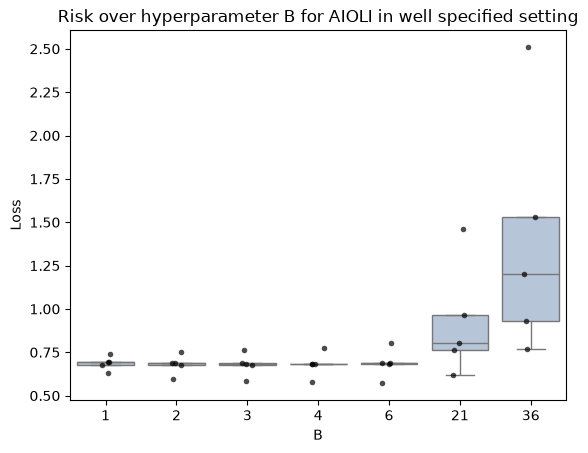

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005


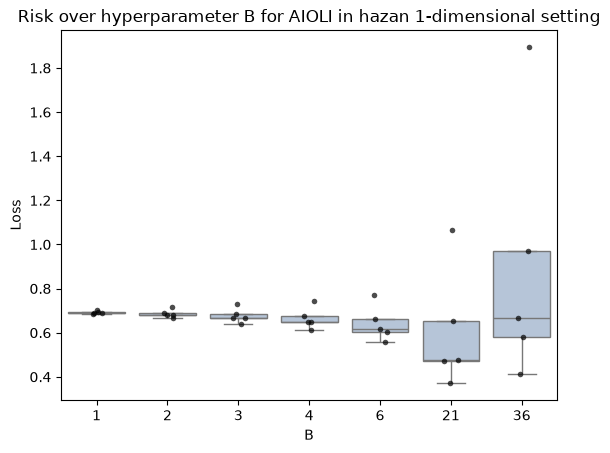

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.946
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.928
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.947
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.942
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.948


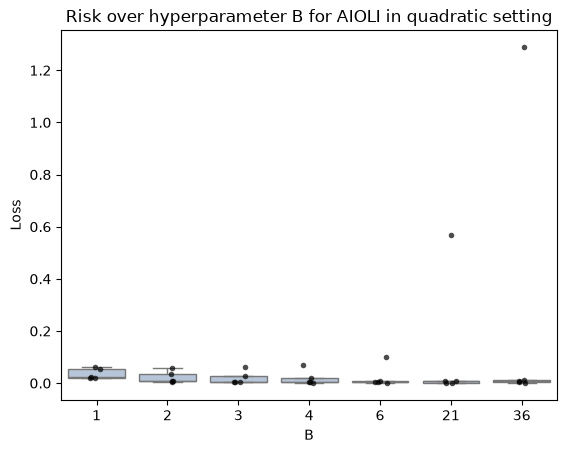

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516


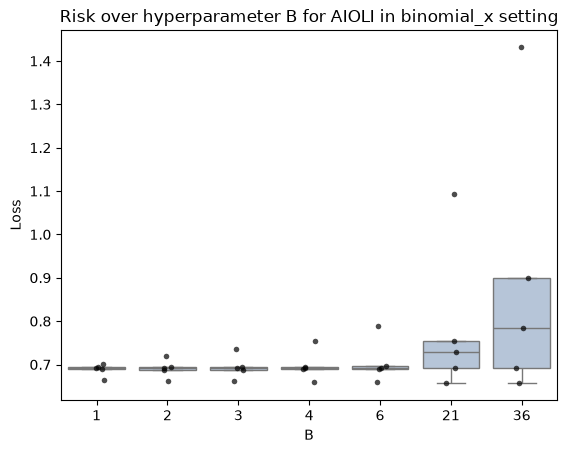

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.522
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.49
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.533


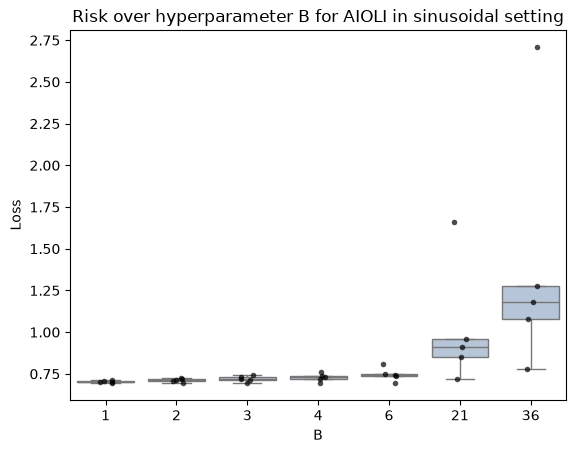

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.865
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.875
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.855
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.89
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.925


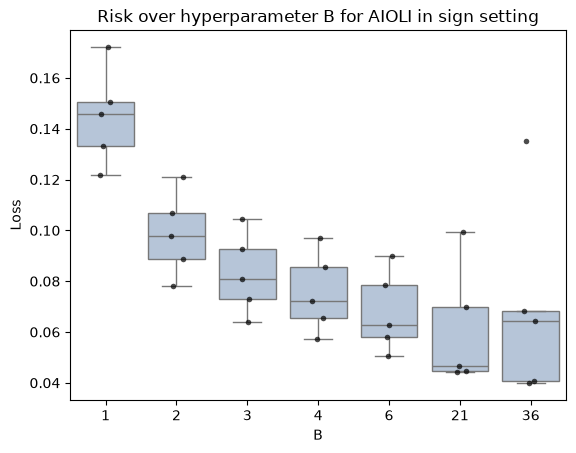

100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.496
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.472


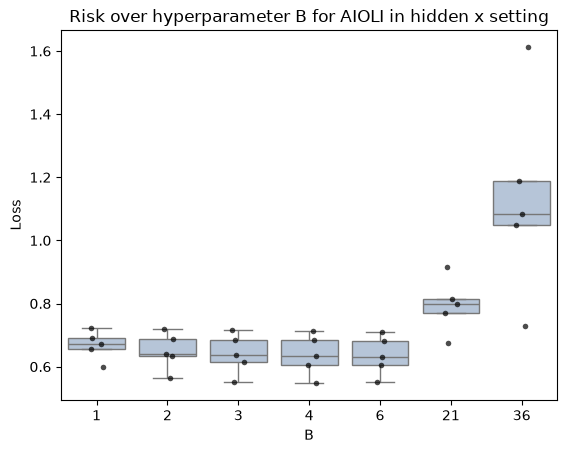

In [251]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = alt_xmeans_balanced_1)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.497
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509


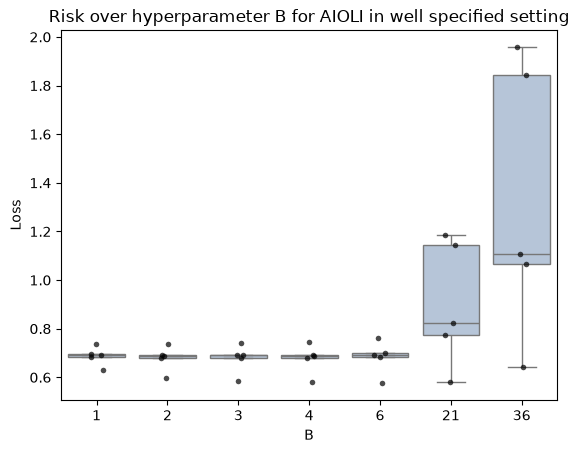

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005


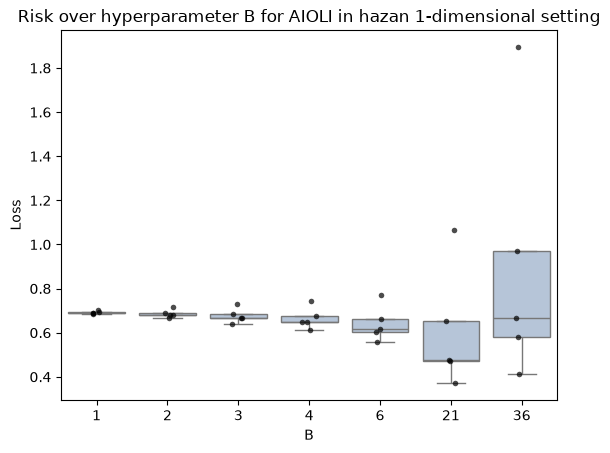

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


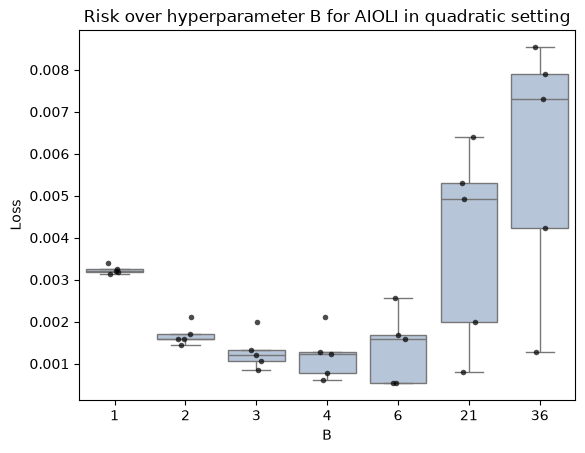

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516


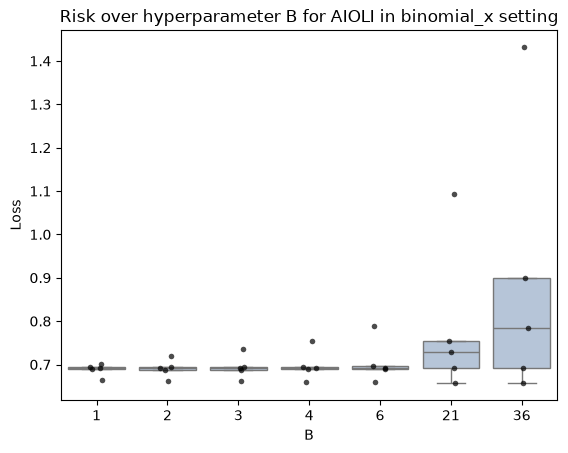

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.512
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.467
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.478
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531


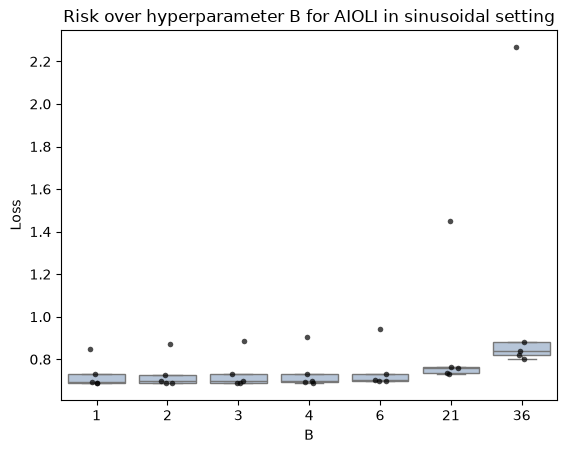

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


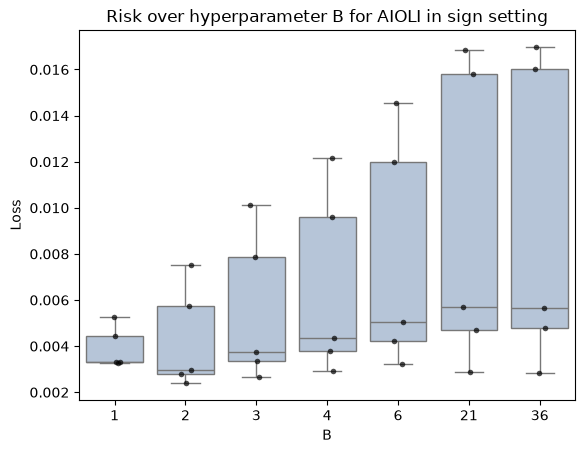

100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.496
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.472


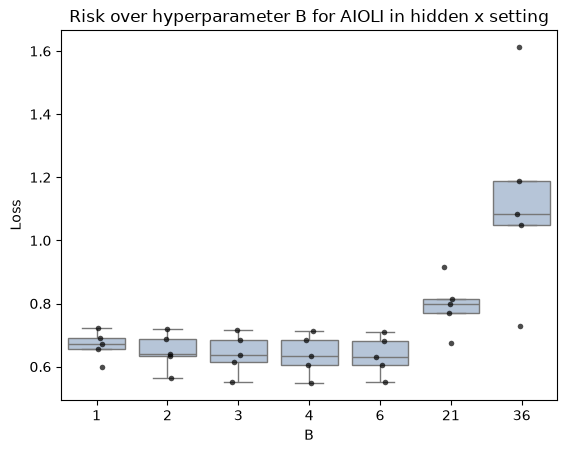

In [252]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = alt_xmeans_balanced_2)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.952
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.936
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.94
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.927
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.94


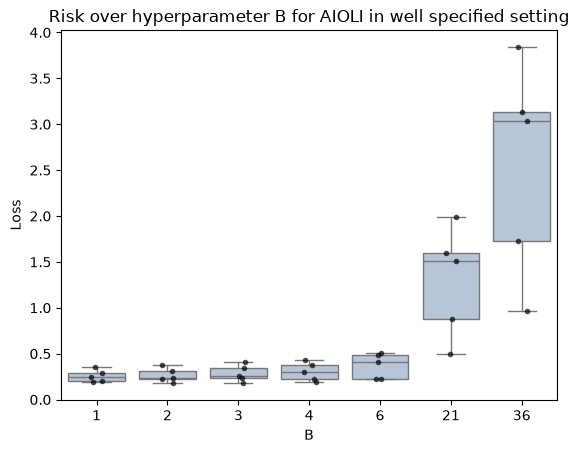

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04


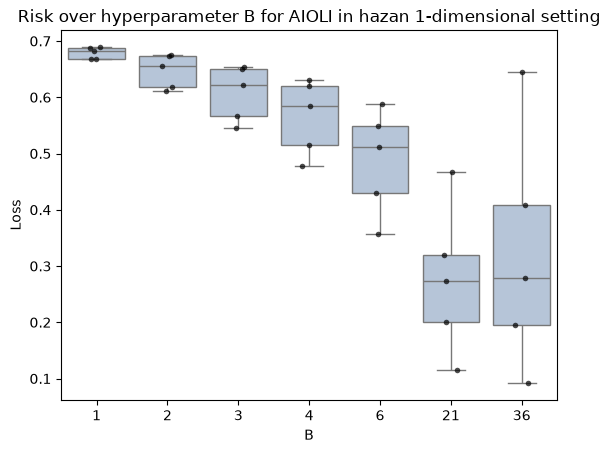

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


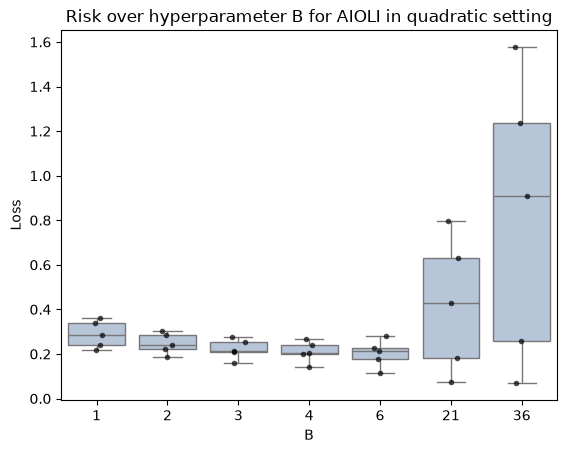

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.995
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.988
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.989


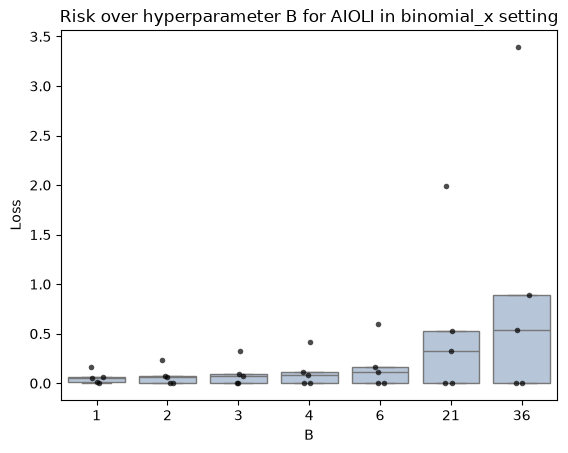

100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.208
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.424
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.333
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.327


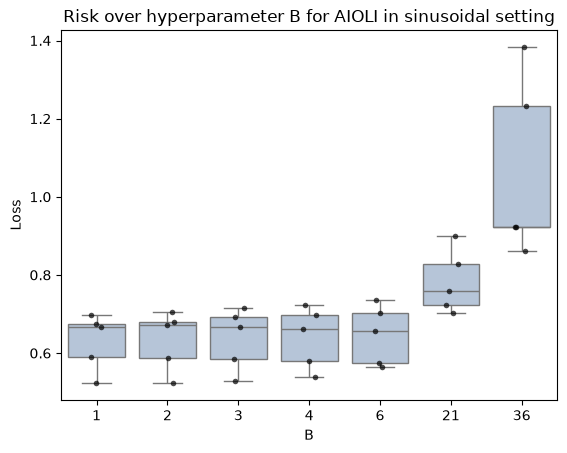

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


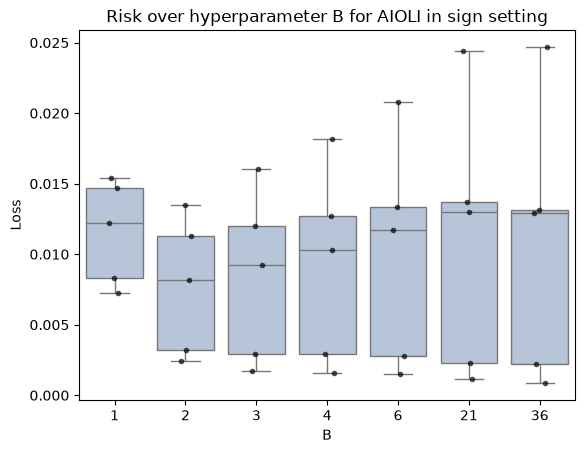

100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.944
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.879
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.936
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.923
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.904


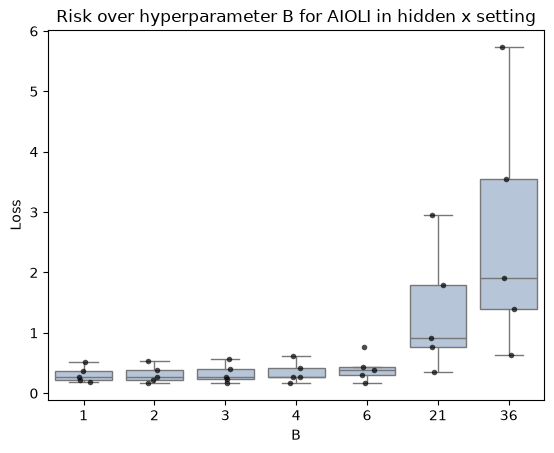

In [253]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = alt_xmeans_unbalanced_1, balanced = False, X_hazan = -1)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


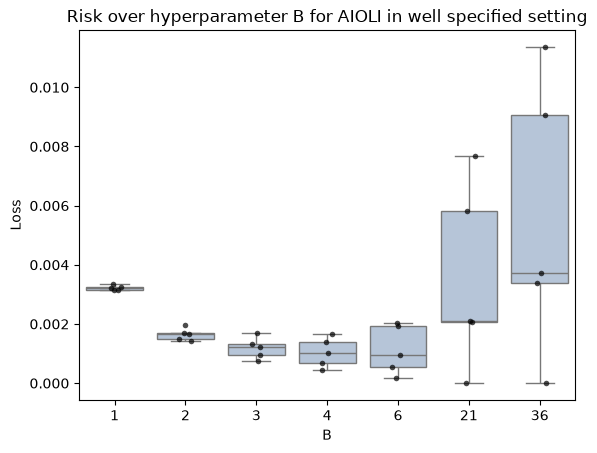

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04


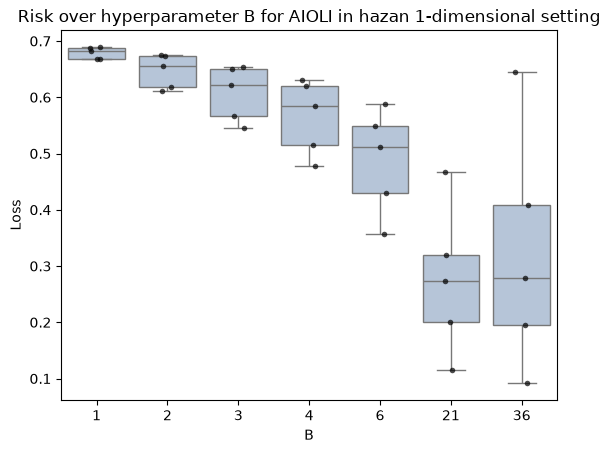

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.034
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.038
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.035
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.037
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.038


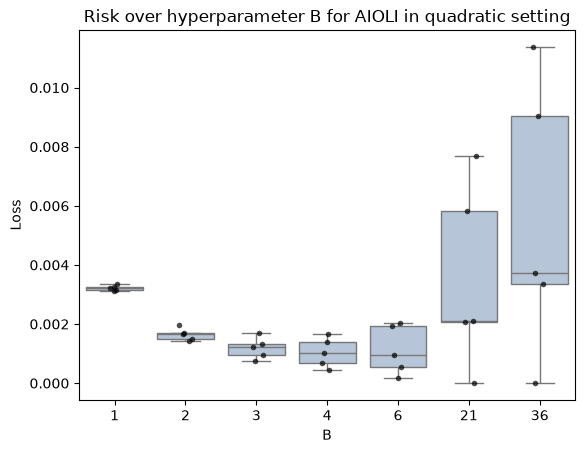

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.995
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.988
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.989


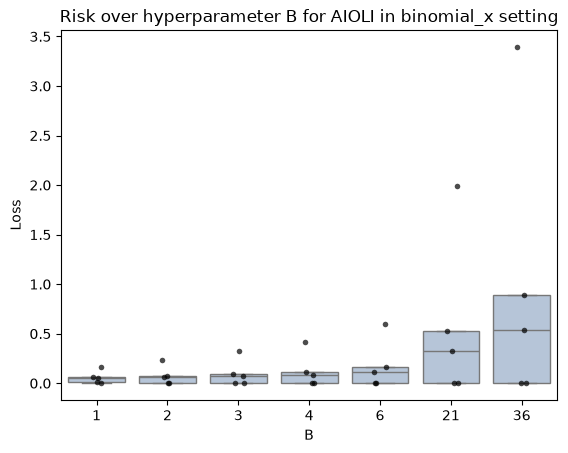

100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.684
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.582
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.592
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.607


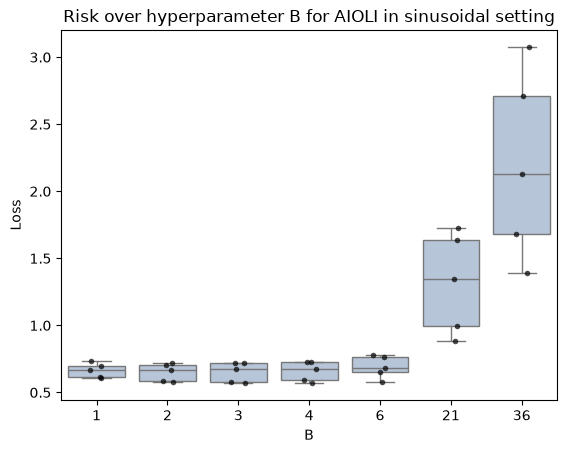

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


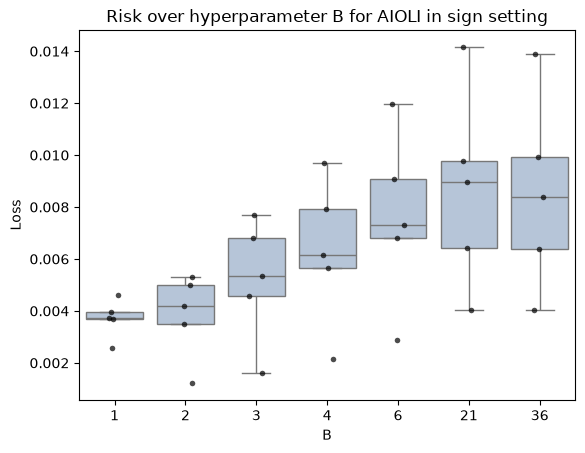

100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.944
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.879
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.936
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.923
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.904


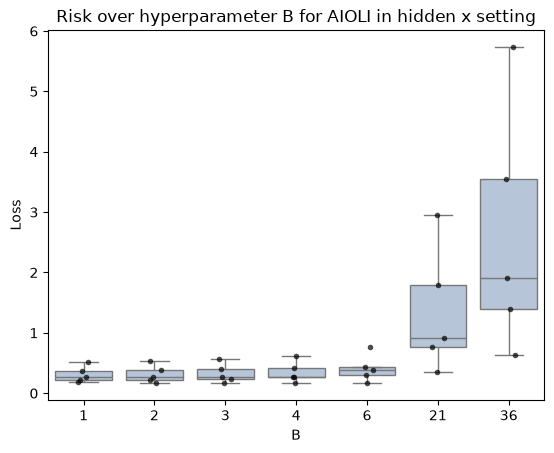

In [254]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "B", n = 100, x_means = alt_xmeans_unbalanced_2, balanced = False, X_hazan = -1)

### AIOLI "X"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.5
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.494
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.504
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.511


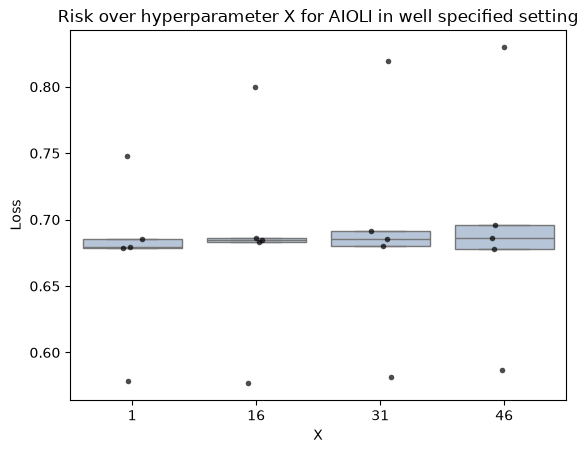

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005


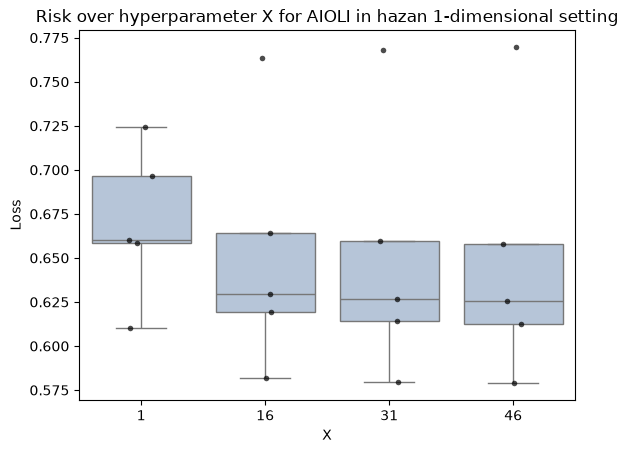

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.946
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.928
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.947
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.942
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.948


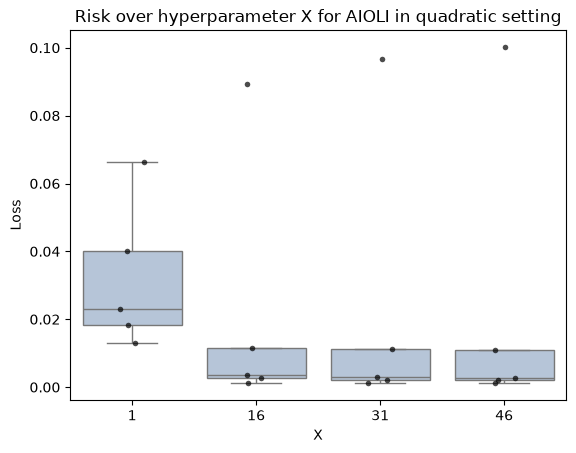

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516


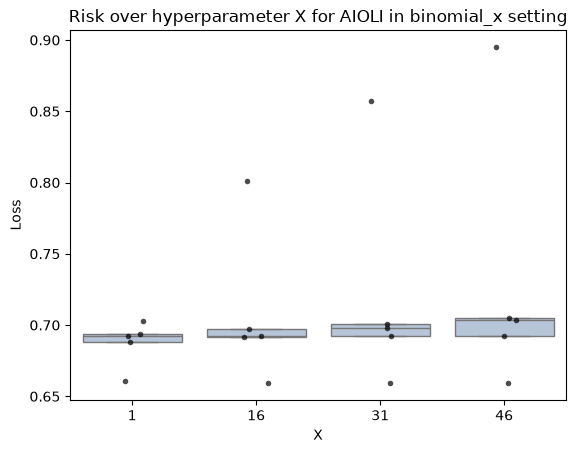

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.522
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.49
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.533


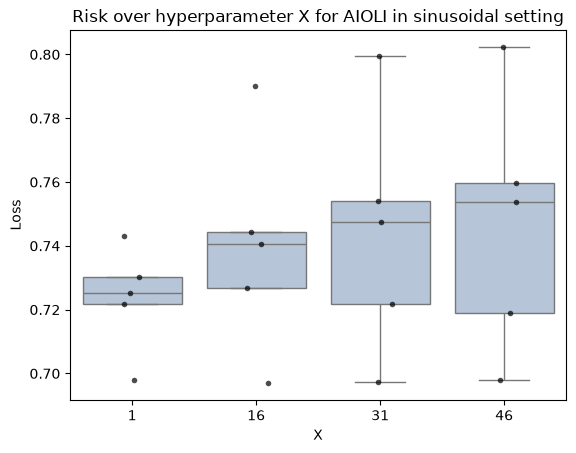

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.865
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.875
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.855
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.89
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.925


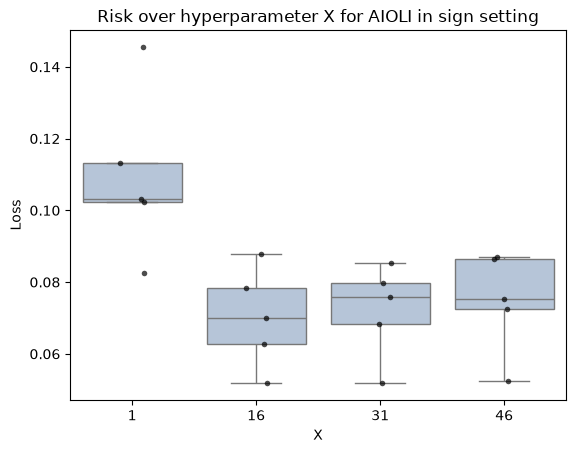

100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.496
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.472


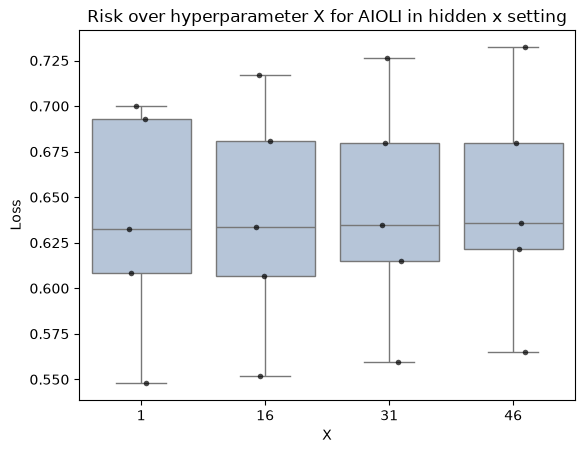

In [255]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, x_means = alt_xmeans_balanced_1)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.497
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509


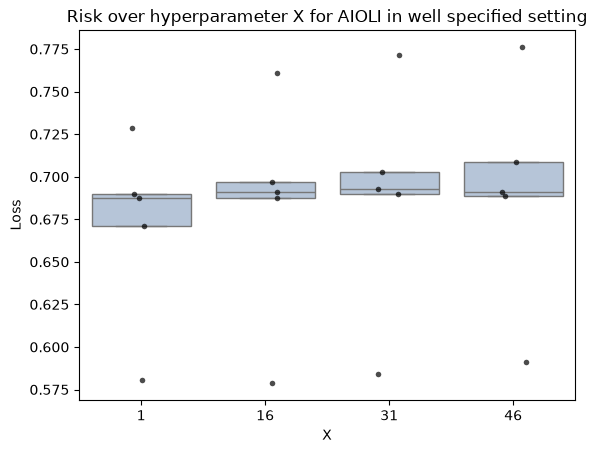

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005


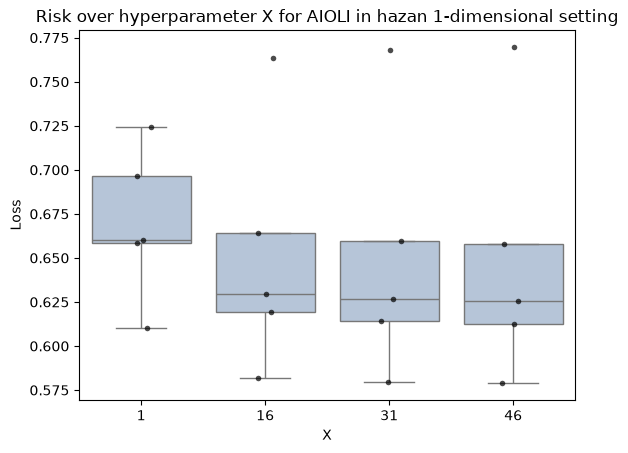

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


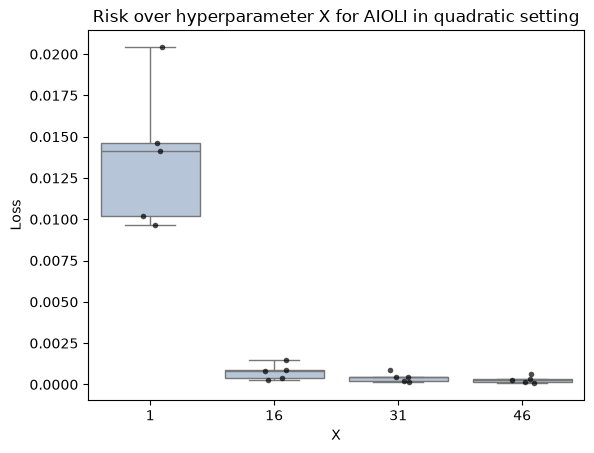

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516


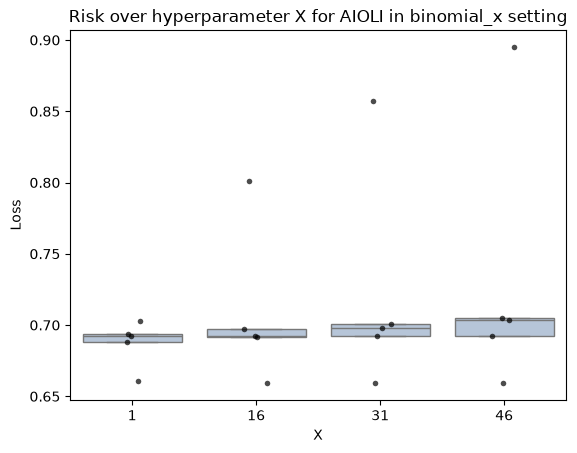

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.512
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.467
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.478
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531


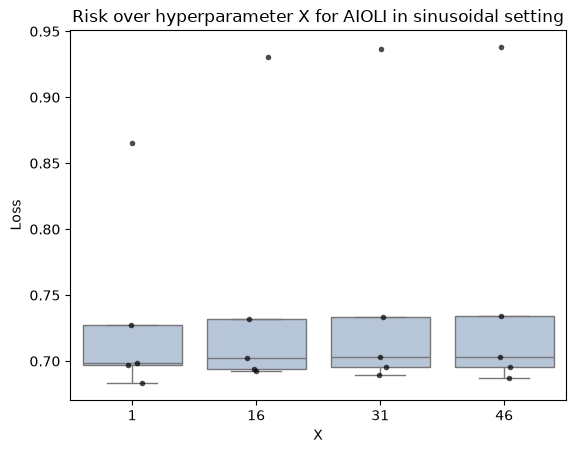

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


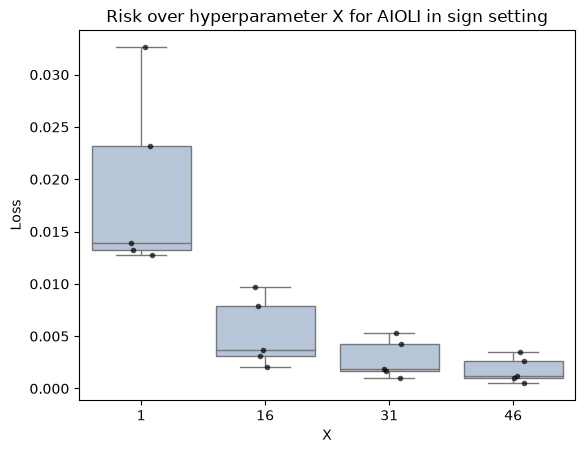

100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.496
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.472


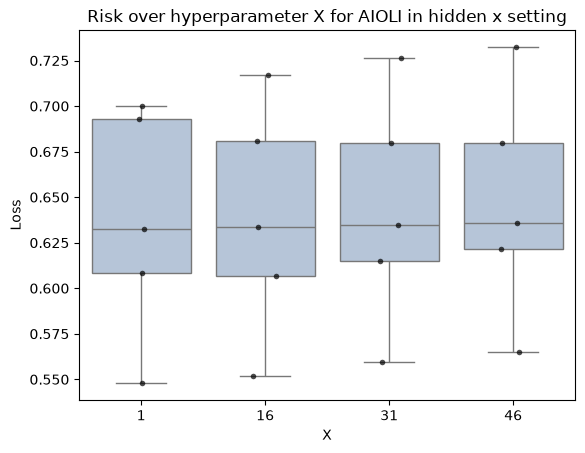

In [256]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, x_means = alt_xmeans_balanced_2)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.952
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.936
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.94
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.927
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.94


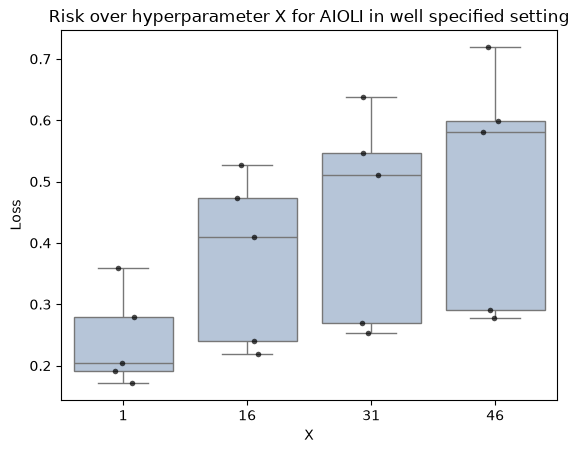

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04


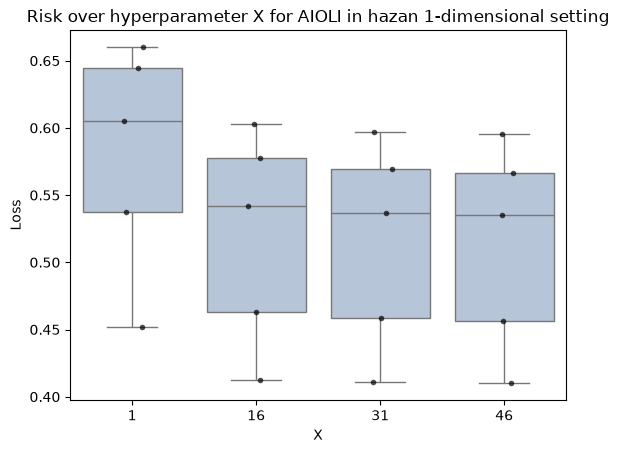

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


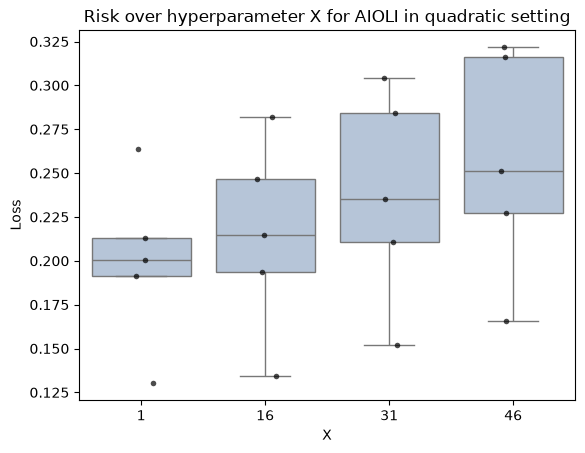

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.995
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.988
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.989


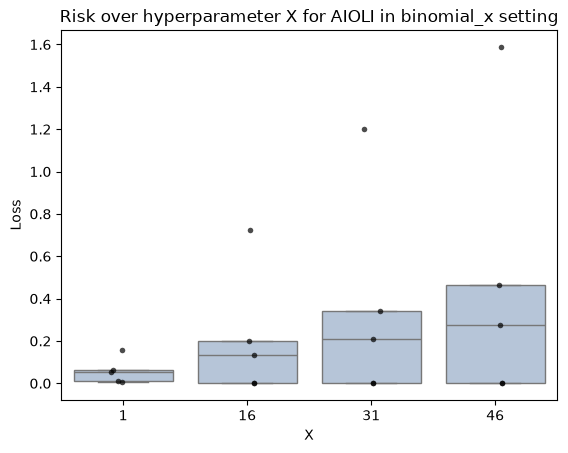

100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.208
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.424
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.333
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.327


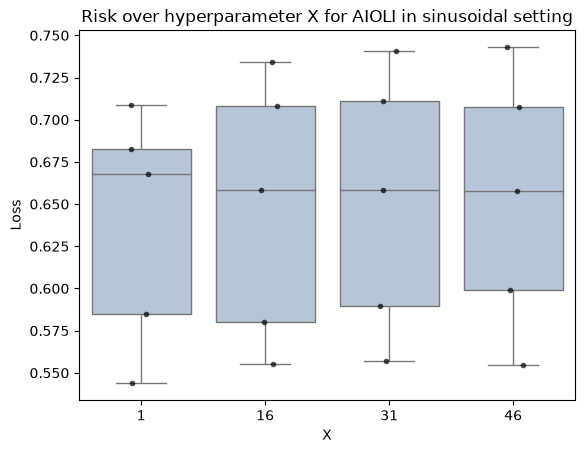

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


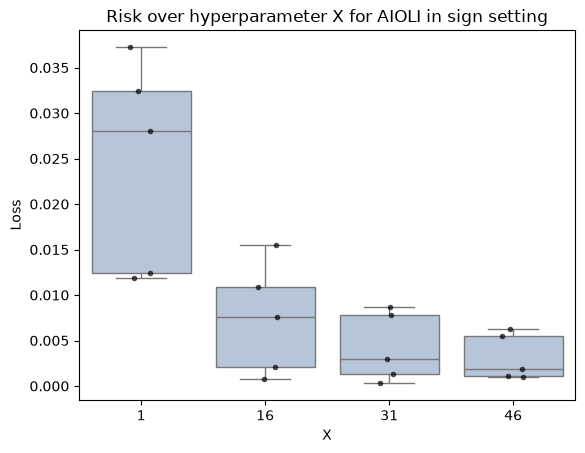

100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.944
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.879
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.936
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.923
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.904


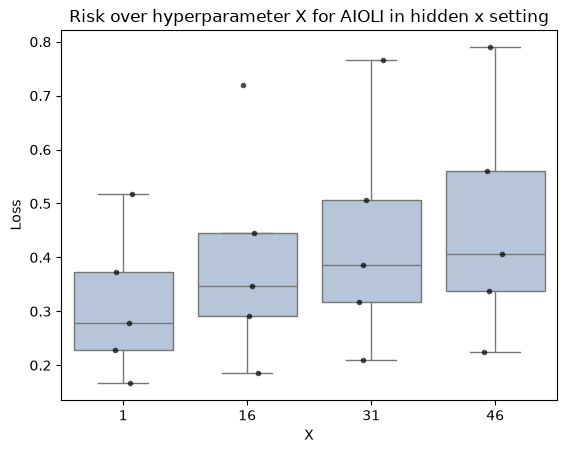

In [257]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, x_means = alt_xmeans_unbalanced_1, balanced = False, X_hazan = -1)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


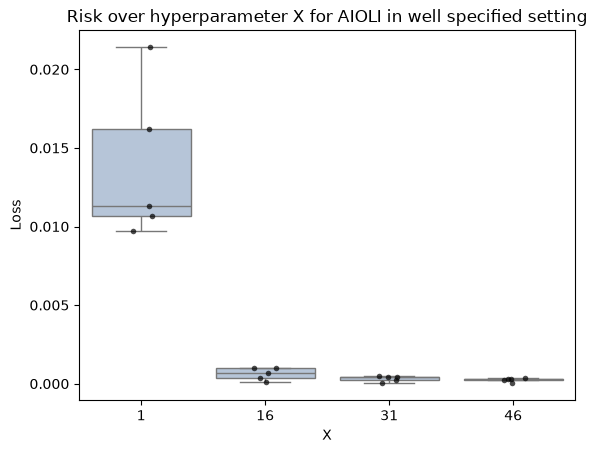

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04


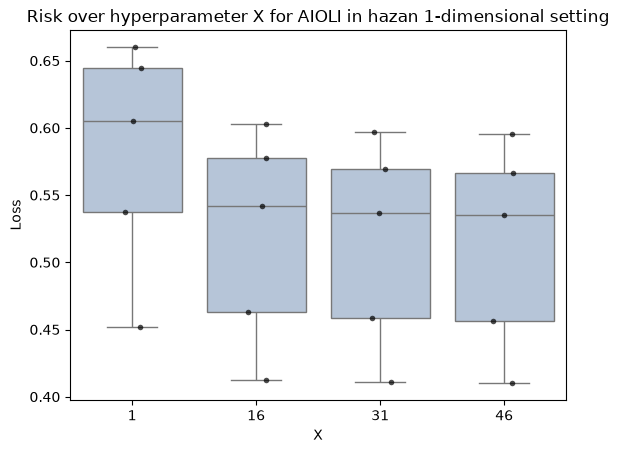

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.034
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.038
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.035
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.037
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.038


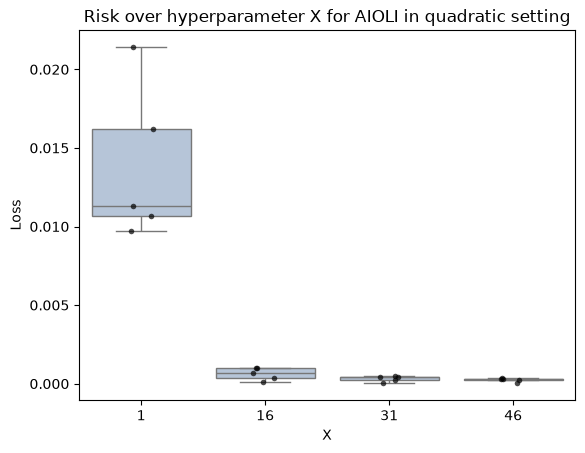

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.995
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.988
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.989


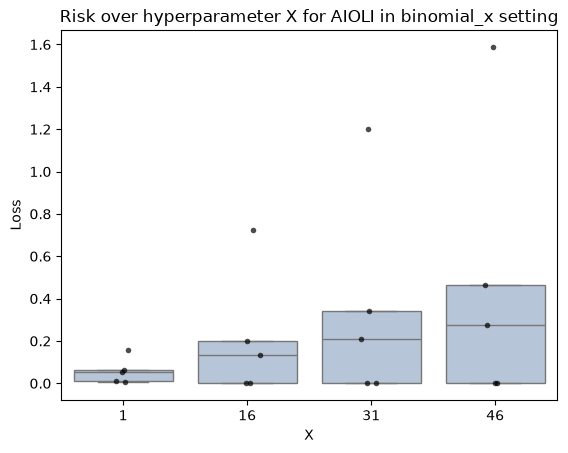

100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.684
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.582
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.592
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.607


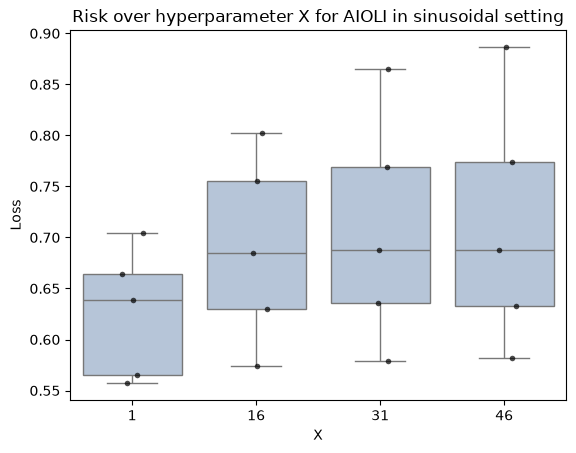

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0


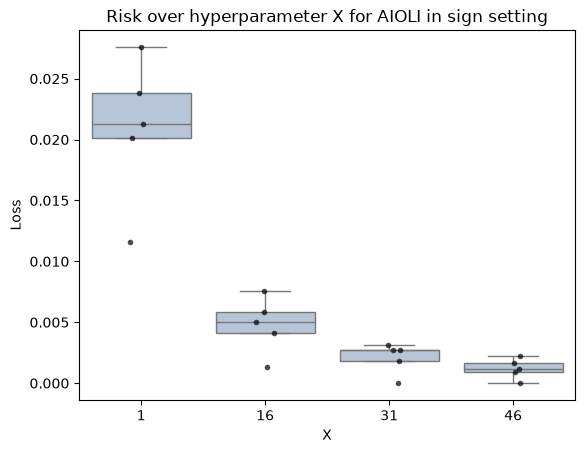

100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.944
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.879
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.936
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.923
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.904


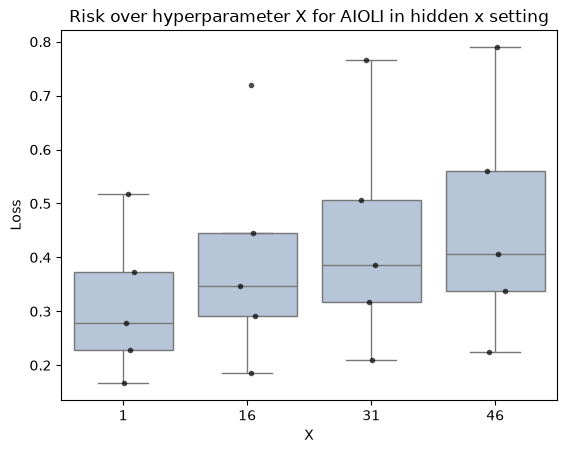

In [258]:
for setting in settings:
    hyperparameter_analysis(setting, "AIOLI", "X", n = 100, x_means = alt_xmeans_unbalanced_2, balanced = False, X_hazan = -1)

### Ada Grad "B"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.5
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.494
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.504
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.511
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.493
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.516
100 (training) samples were generated in the well specified balanced setting. Using 3

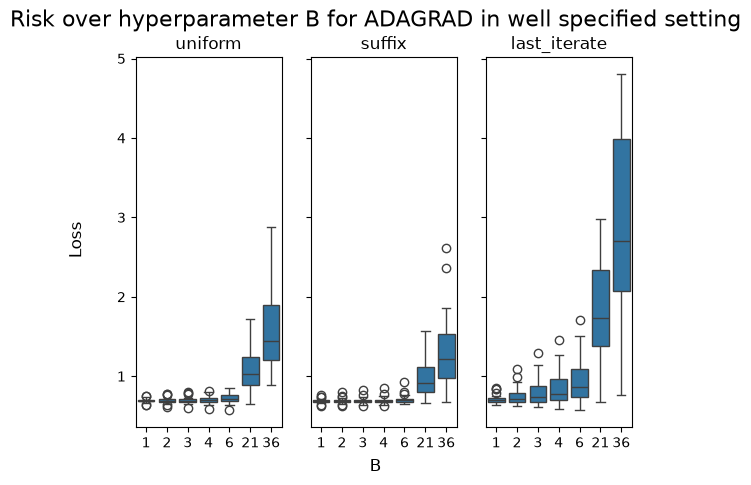

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al

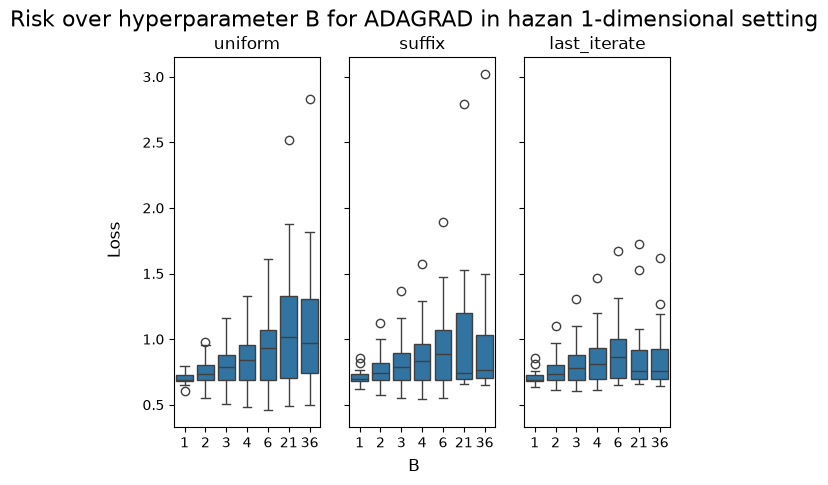

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.946
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.928
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.947
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.942
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.948
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.942
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.947
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) o

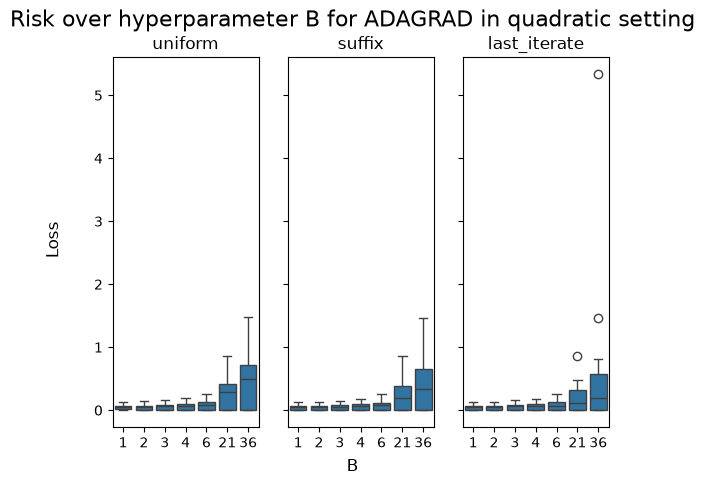

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.565
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average 

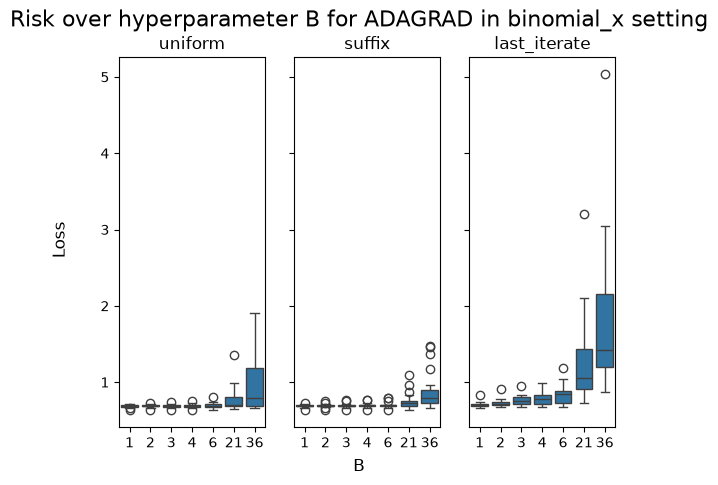

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.522
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.49
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.533
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.514
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.479
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P

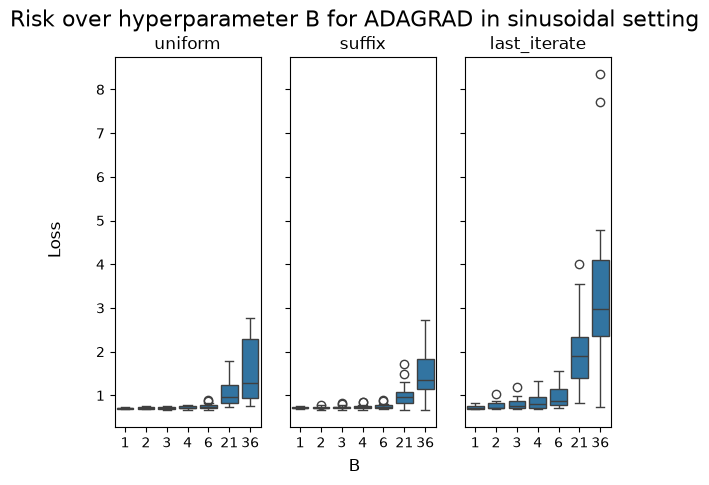

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.865
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.875
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.855
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.89
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.925
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.895
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.94
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.93
100 (training) samples were generat

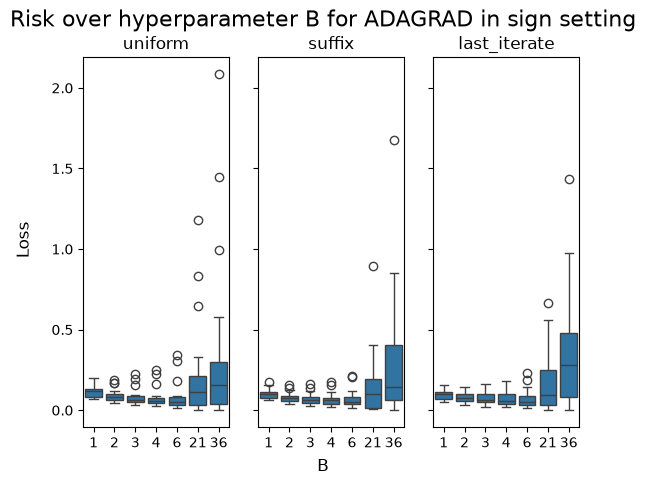

100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.496
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.472
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.459
1

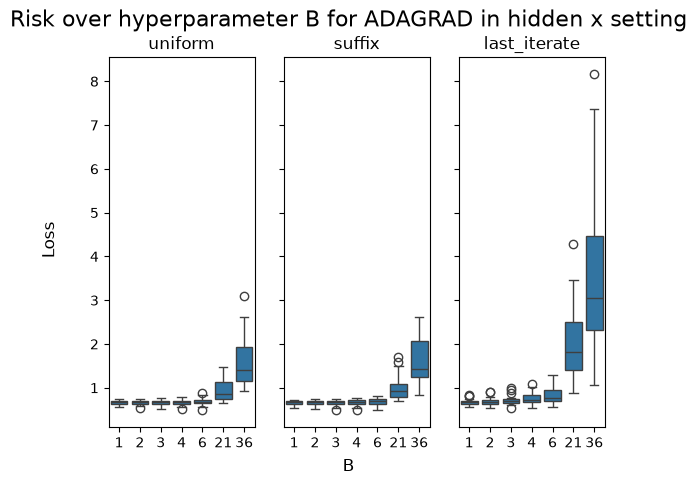

In [197]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100,x_means = alt_xmeans_balanced_1, n_runs=20)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.497
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.49
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.513
100 (training) samples were generated in the well specified balanced setting. Using 

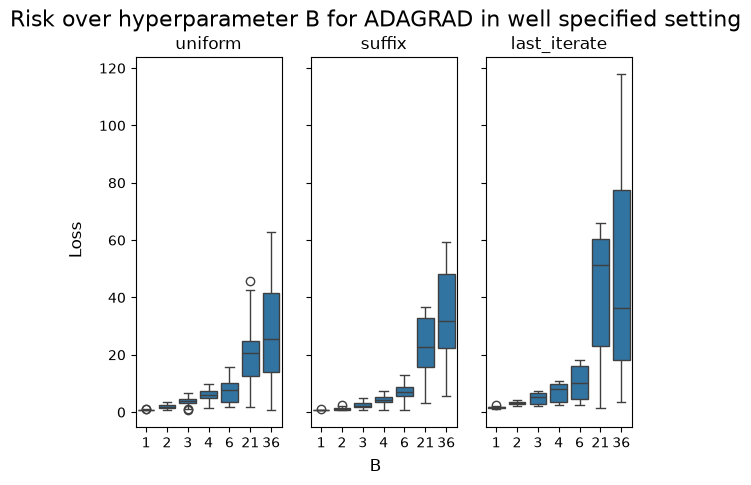

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al

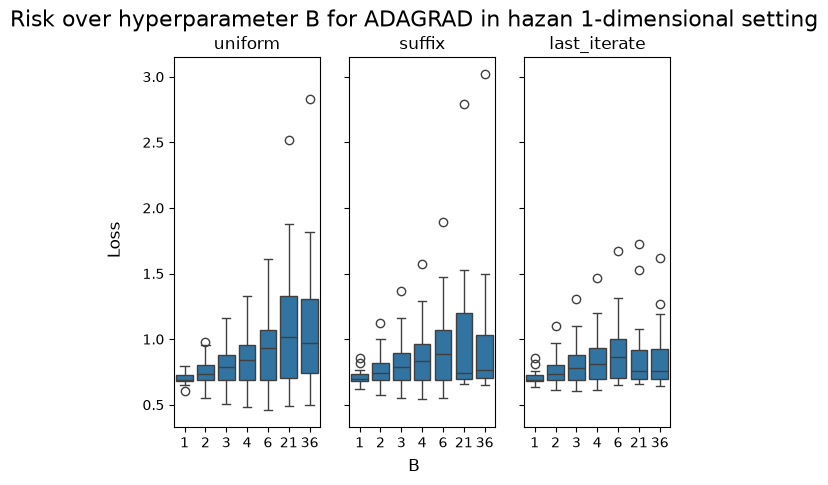

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (tra

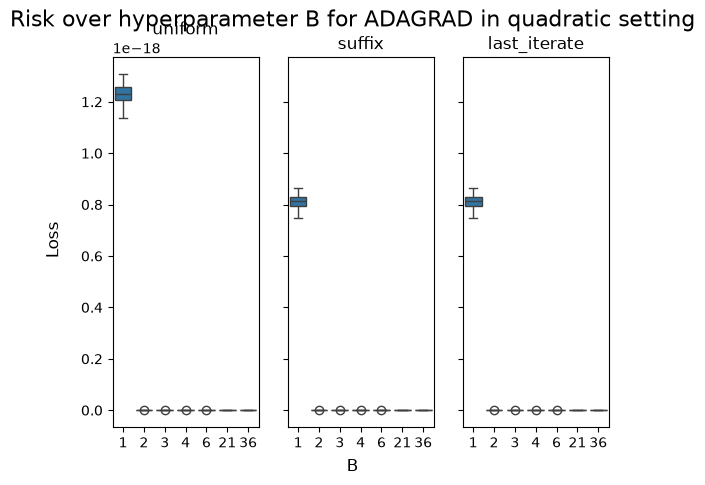

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.565
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average 

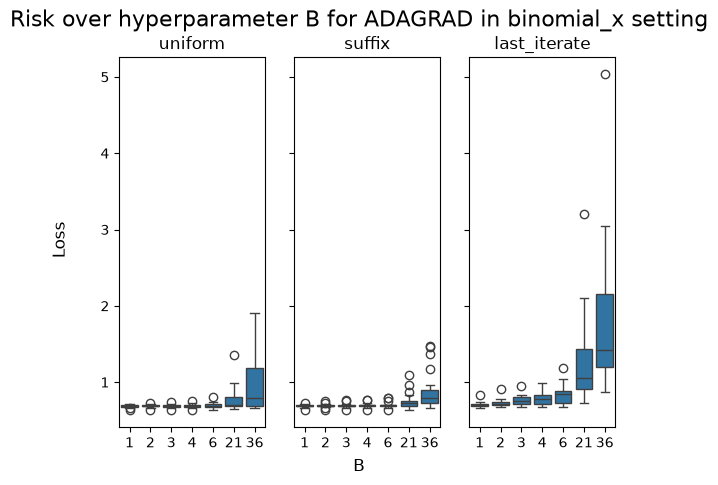

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.512
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.467
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.478
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.489
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.485
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average 

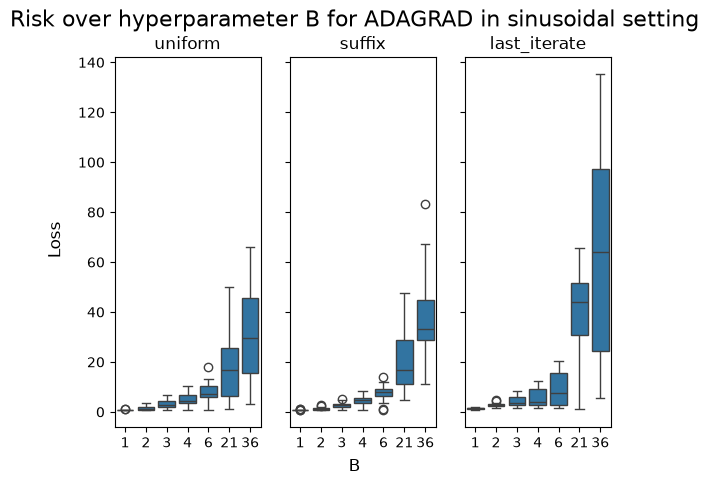

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sig

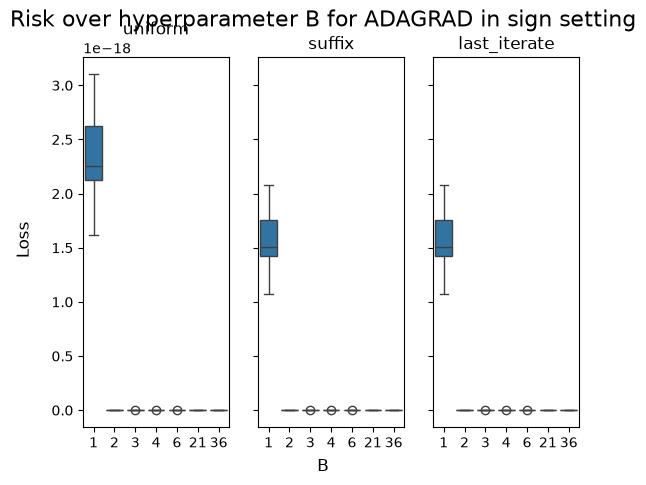

100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.496
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.472
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.459
1

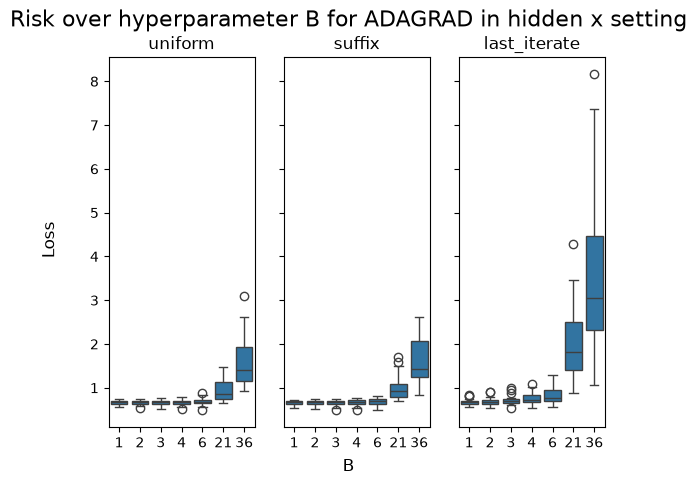

In [198]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100,x_means = alt_xmeans_balanced_2, n_runs=20)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.952
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.936
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.94
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.927
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.94
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.917
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.916
100 (training) samples were generated in the well specified unbalanced 

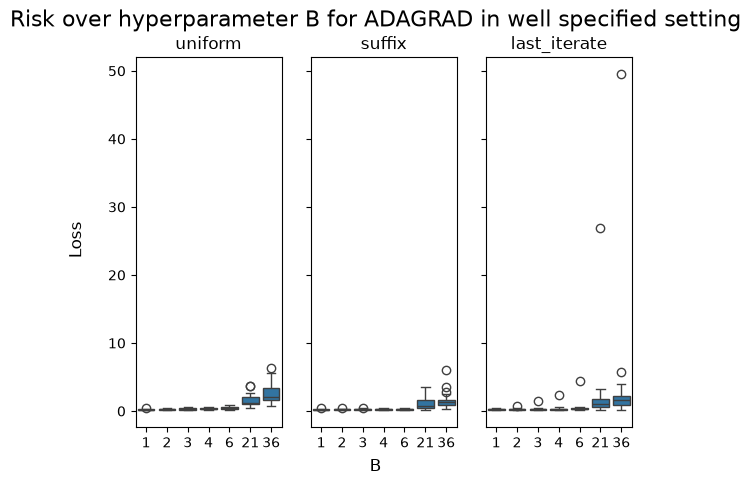

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimen

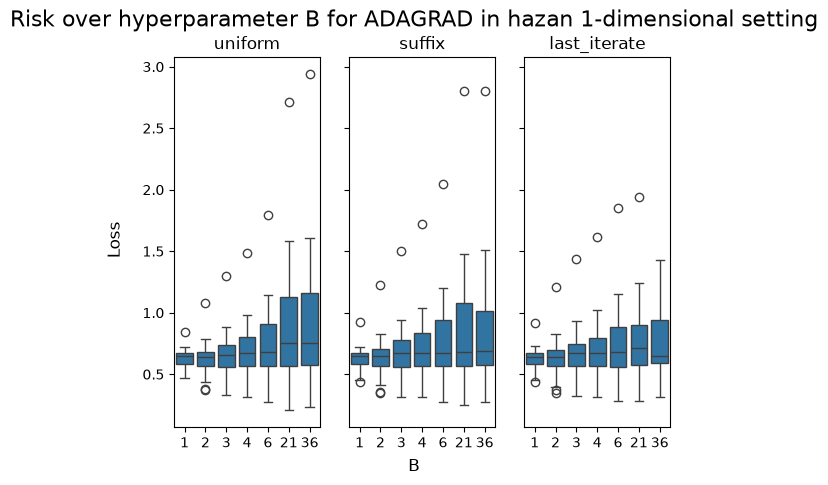

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1)

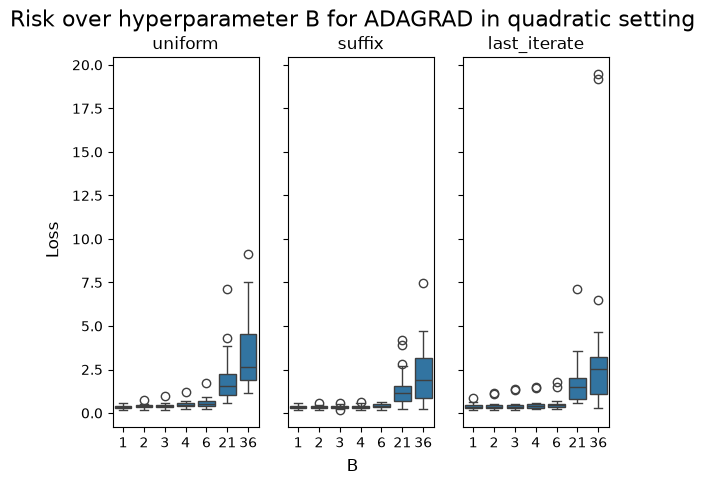

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.995
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.988
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.989
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.994
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.99
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), w

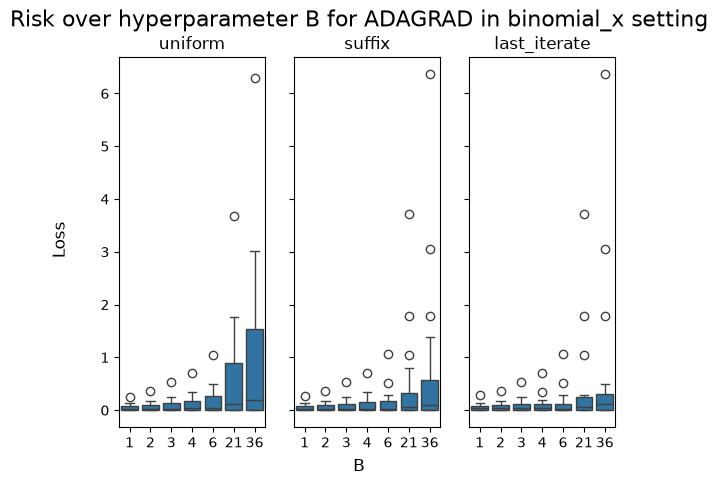

100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.51
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.47
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.476
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.49
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.483
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.51
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with

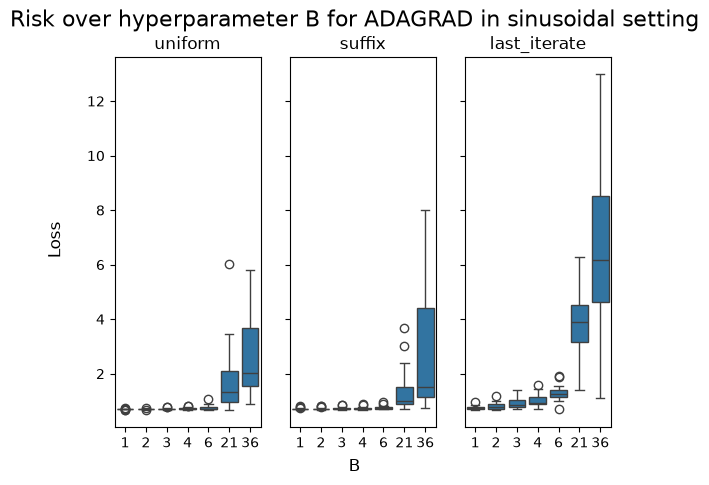

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were gene

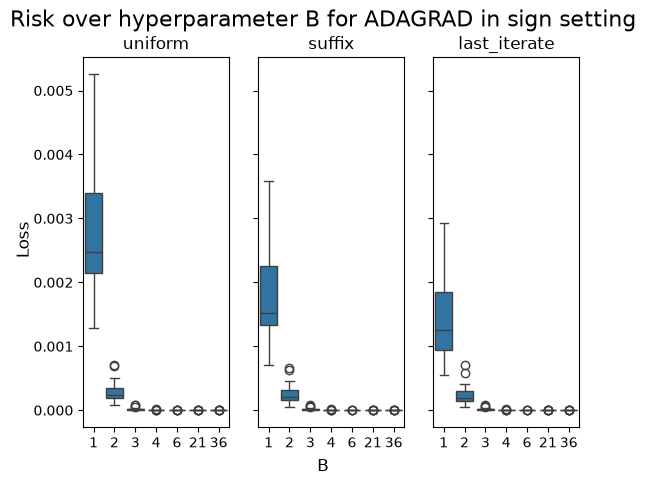

100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.944
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.879
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.936
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.923
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.904
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.874
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.896
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average 

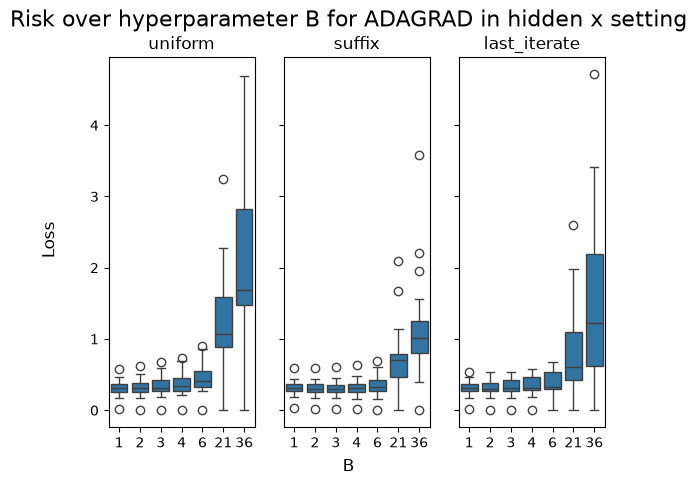

In [199]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100,x_means = alt_xmeans_unbalanced_1, balanced = False, X_hazan = -1, n_runs=20)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the well specified unbalanced setting. Usi

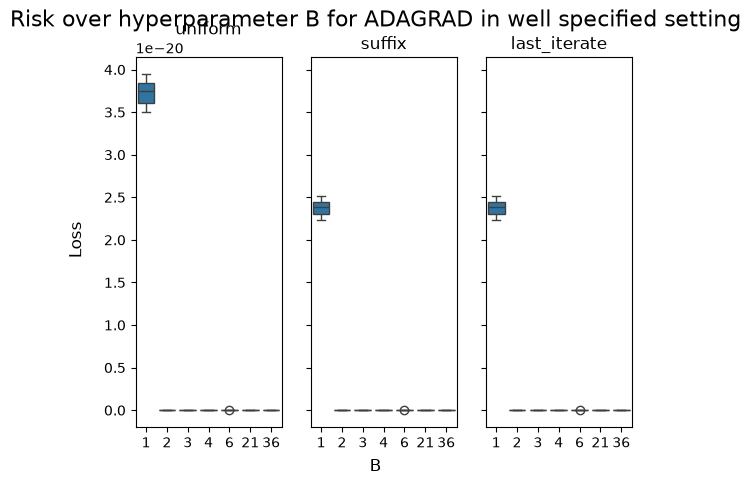

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.04
100 (training) samples were generated using the 1-dimen

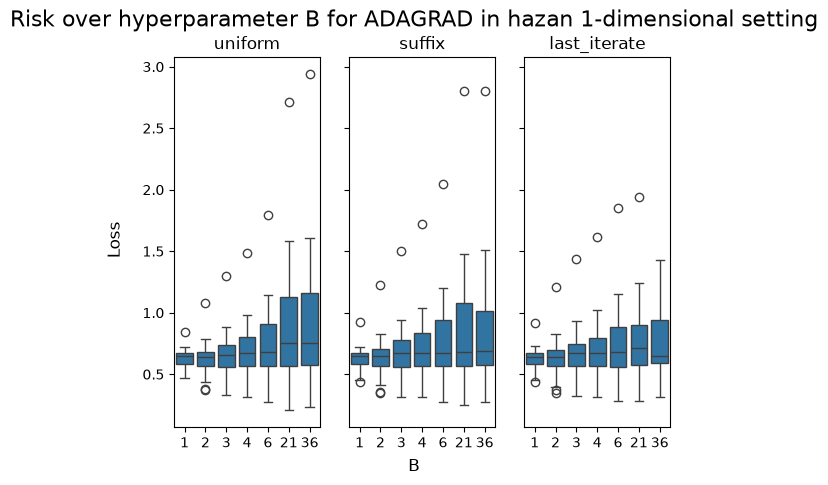

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.034
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.038
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.035
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.037
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.038
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.039
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.039
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an 

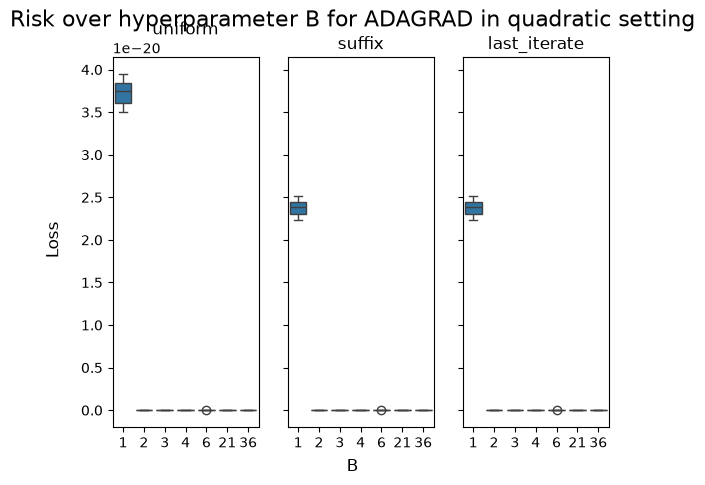

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.992
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.995
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.988
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.989
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.994
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.99
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), w

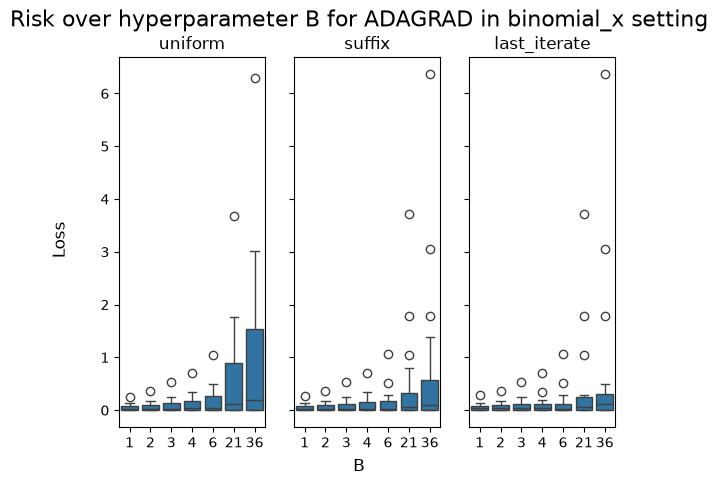

100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.533
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.524
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.508
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.517
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.493
100 (training) samples were generated in the sinusoidal unbalanced setting. Using 3 variable(s), 

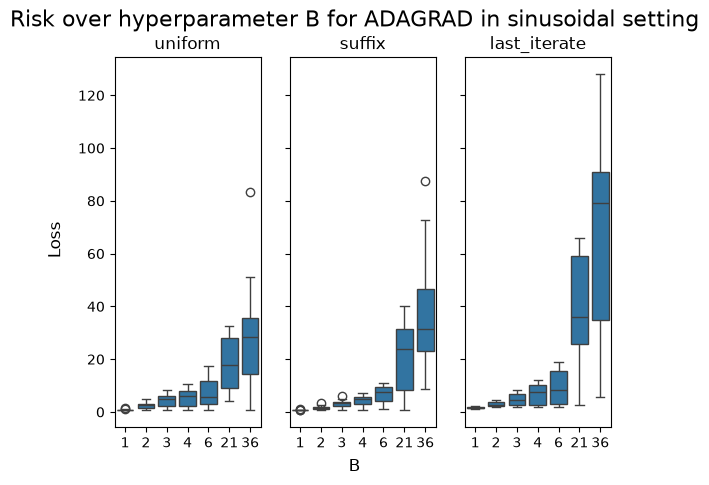

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
100 (training) samples were gene

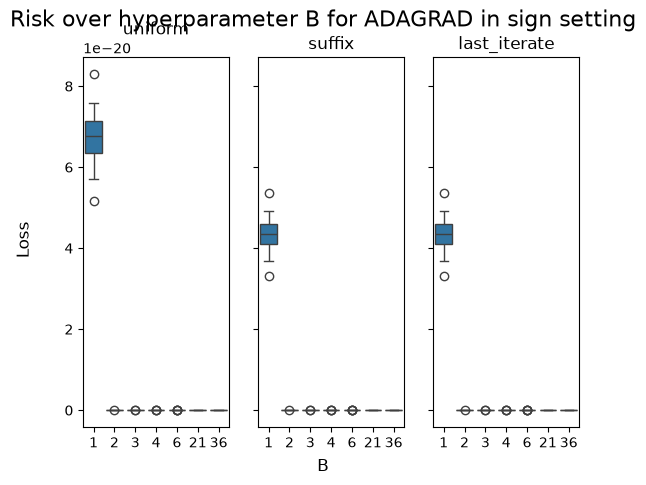

100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.944
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.879
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.936
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.923
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.904
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.874
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.896
100 (training) samples were generated in the hidden x unbalanced setting. Using 3 variable(s), with an average 

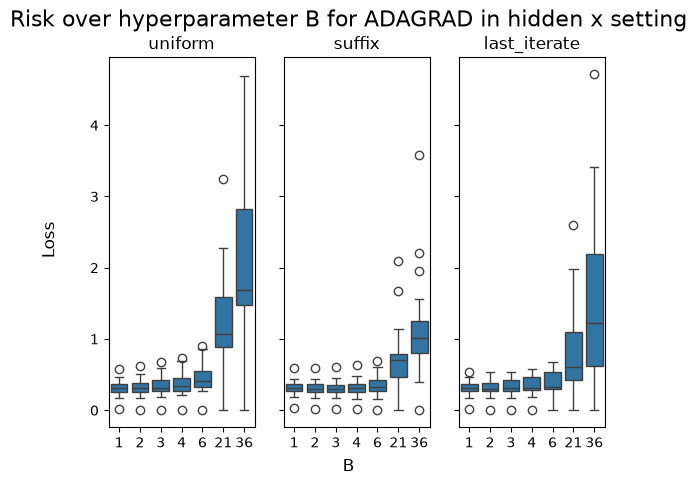

In [200]:
for setting in settings:
    hyperparameter_analysis(setting, "ADAGRAD", "B", n = 100,x_means = alt_xmeans_unbalanced_2, balanced = False, X_hazan = -1, n_runs=20)

### SMOTE "S"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.5
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.494
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.504
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.511
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.493
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.516
100 (training) samples we

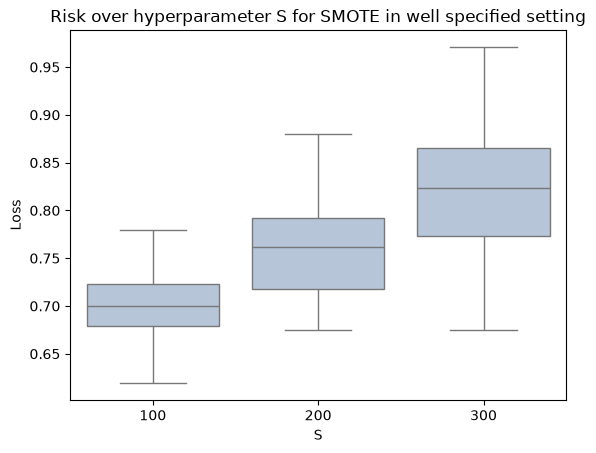

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al

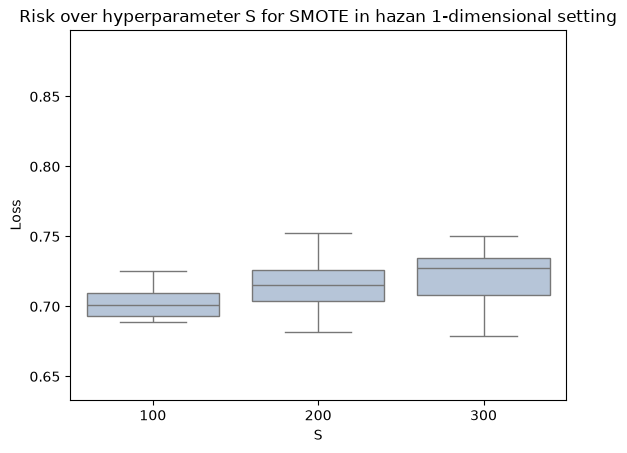

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.946
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.928
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.947
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.942
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression w

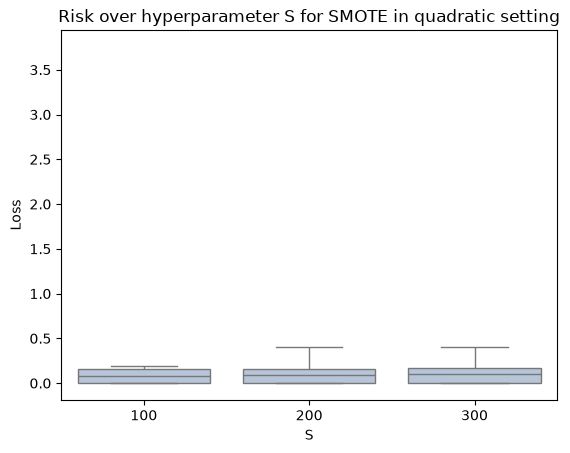

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.565
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average 

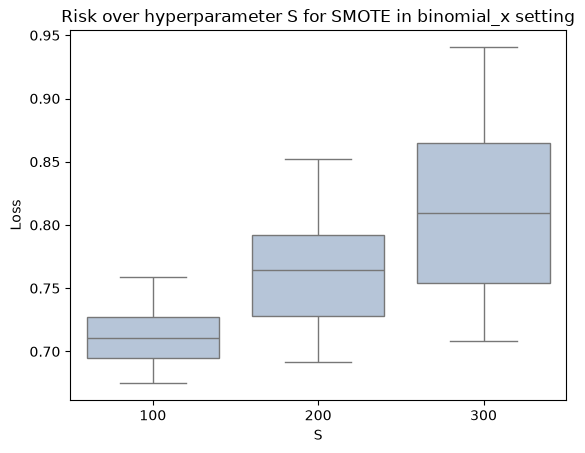

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.522
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.49
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.533
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.514
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.479
100 (training) samples were generated in the sinusoi

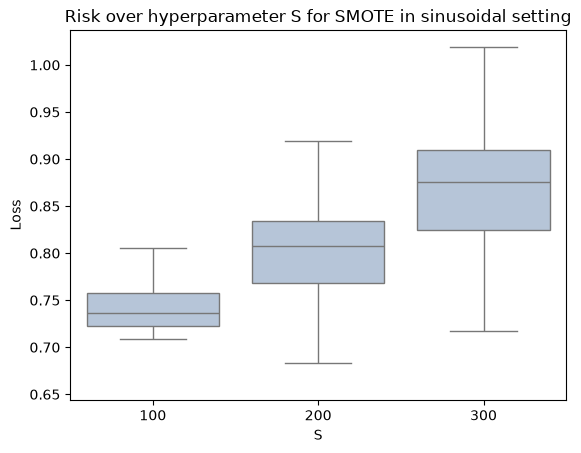

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.865
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.875
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.855
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.89
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.925
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.895
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.94
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.93
100 (training) samples were generat

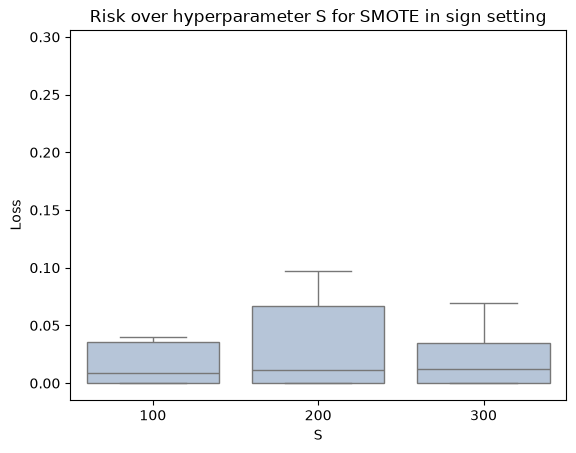

100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.496
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.472
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.459
1

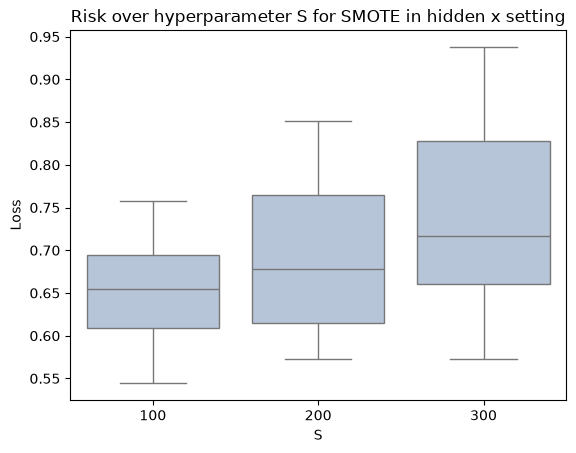

In [205]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "S", n = 100, x_means = alt_xmeans_balanced_1, n_runs=20)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.497
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.509
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.49
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(

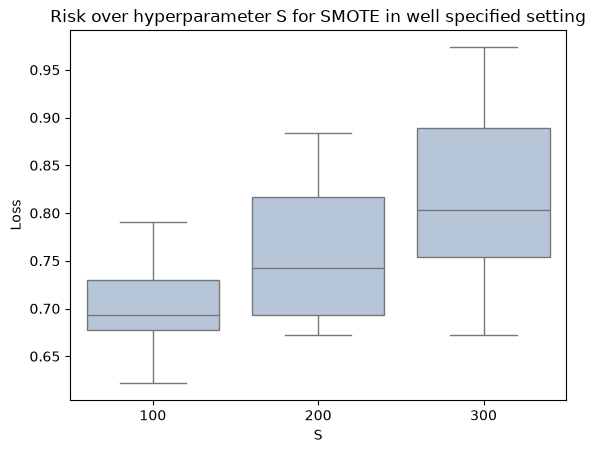

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al

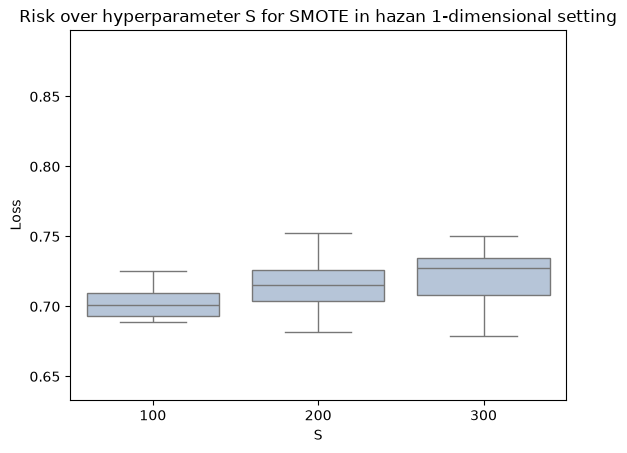

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadrat

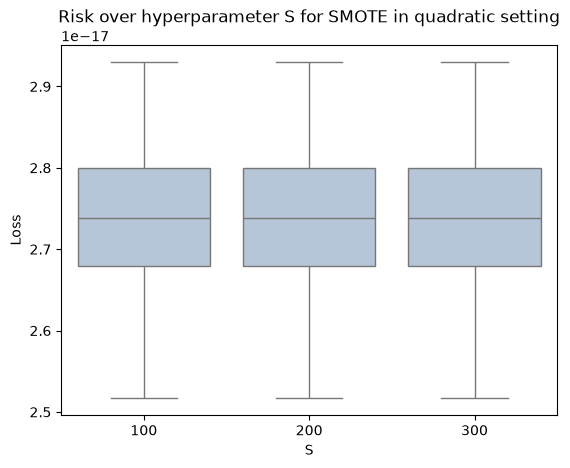

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.565
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average 

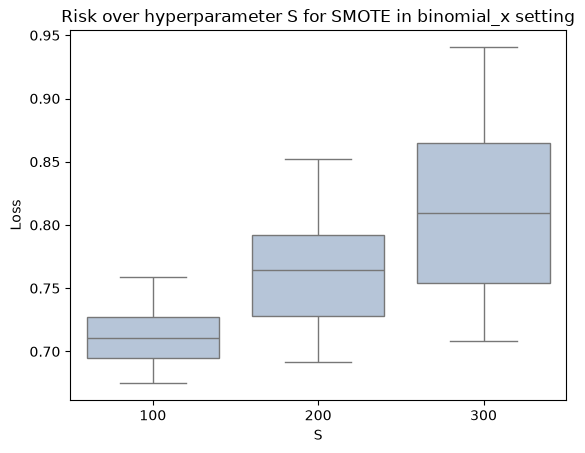

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.512
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.467
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.478
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.489
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.485
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average 

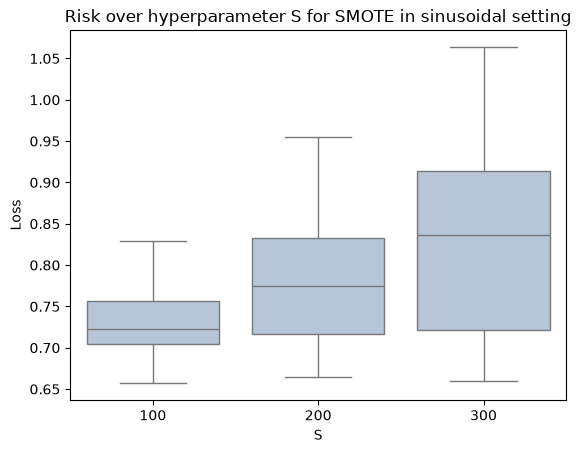

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the sign balanced setting.

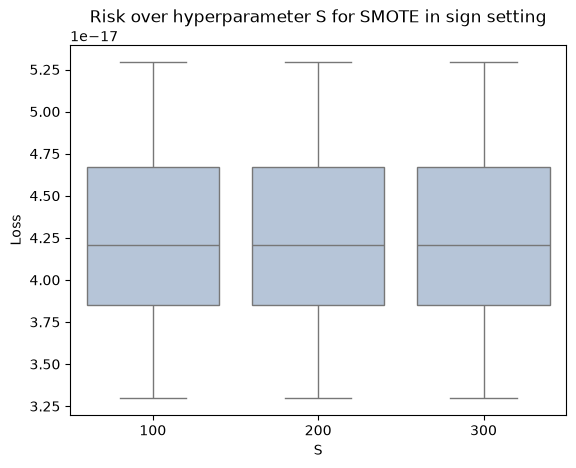

100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.496
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.472
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.459
1

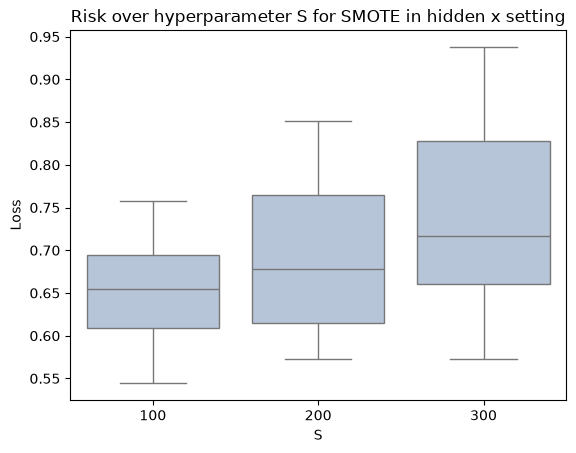

In [206]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "S", n = 100, x_means = alt_xmeans_balanced_2, n_runs=20)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.016
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.016
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.017
100 (training) samples were generated in the well specified balanced setting. Using 3 variab

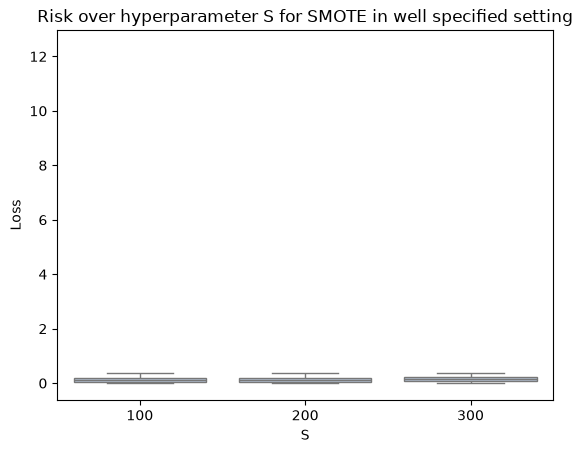

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al

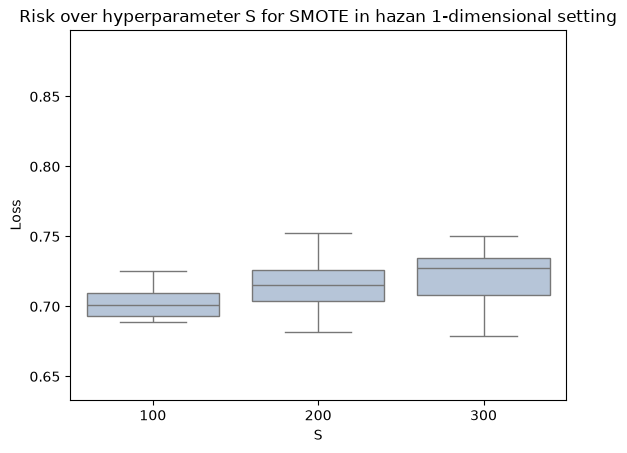

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.985
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.978
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.985
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the q

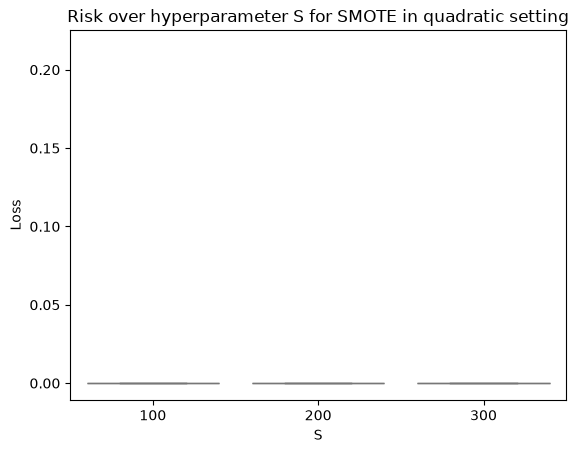

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.565
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average 

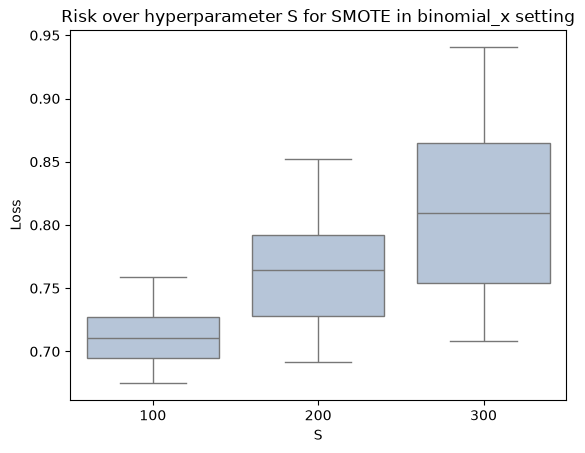

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.511
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.518
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.458
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.479
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.523
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.483
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average 

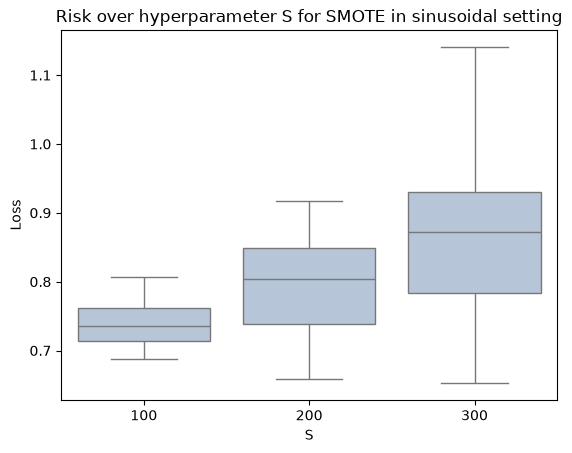

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.035
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.04
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.025
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.02
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.035
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.01
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.03
100 (training) samples were generate

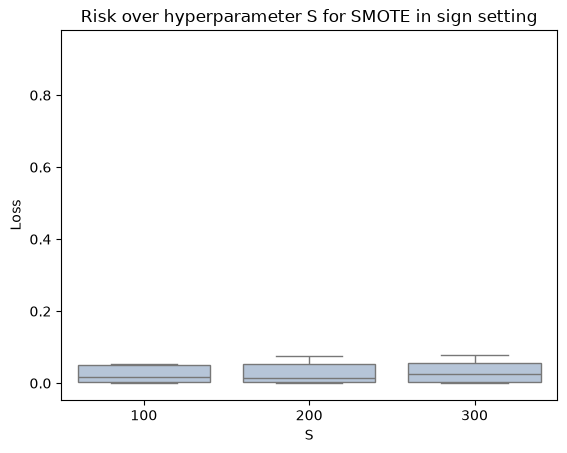

100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.496
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.472
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.459
1

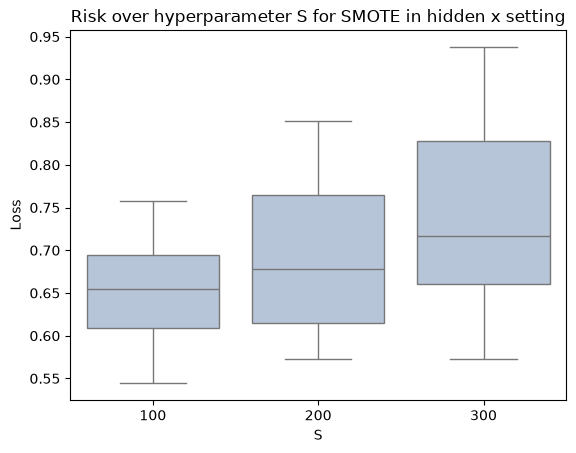

In [207]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "S", n = 100, x_means = alt_xmeans_unbalanced_1, n_runs=20)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.012
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.013
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.013
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.013
100 (training) samples were generated in the well specified balanced setting. Using 3 variab

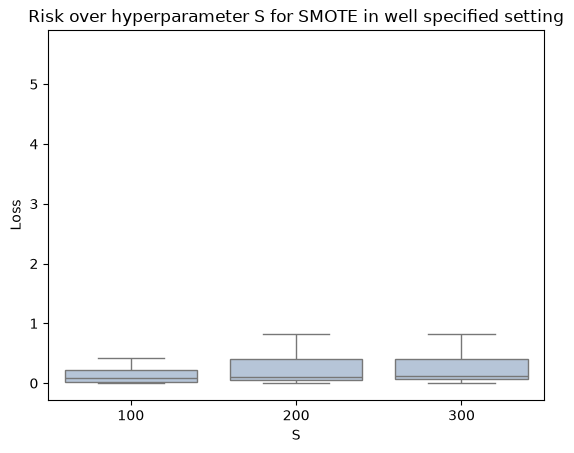

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al

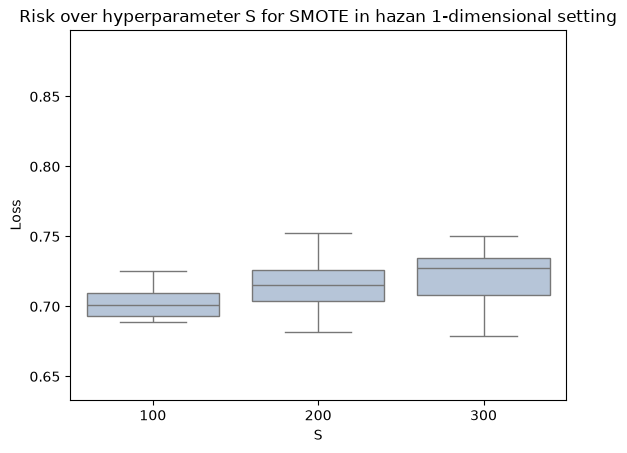

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadrat

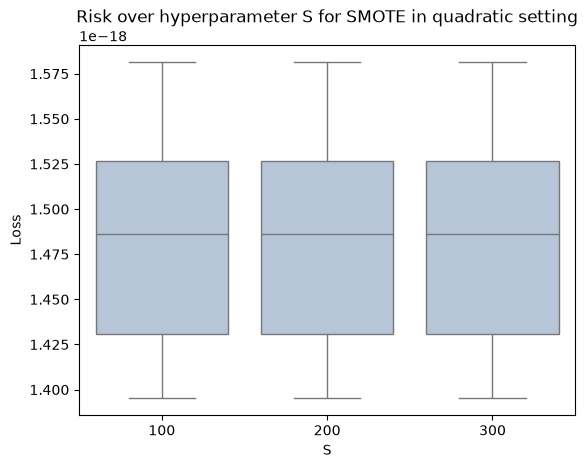

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.565
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average 

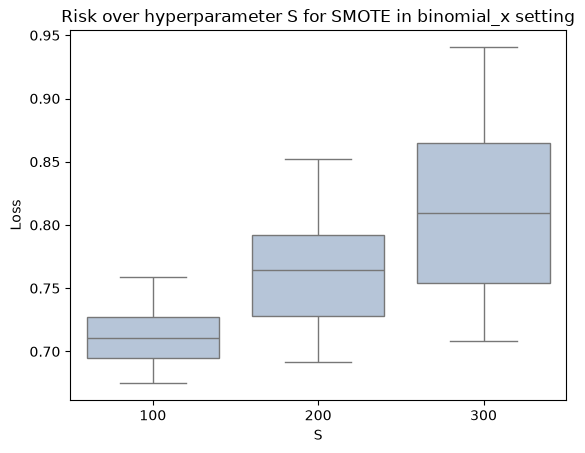

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.499
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.521
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.502
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.52
100 (training) samples were generated in the sinusoi

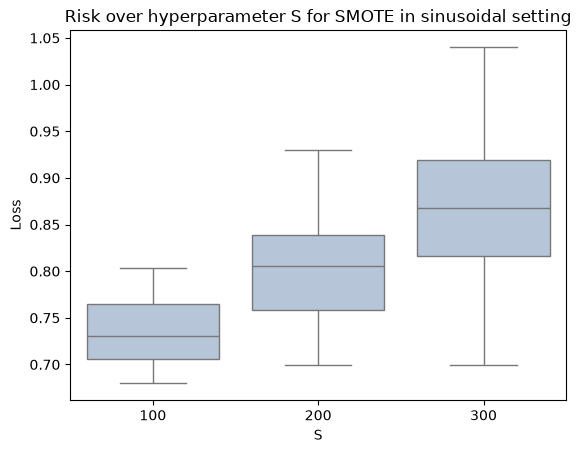

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the sign balanced setting.

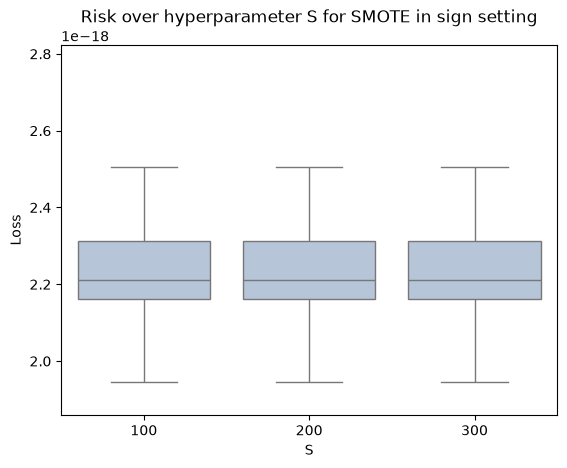

100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.496
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.472
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.459
1

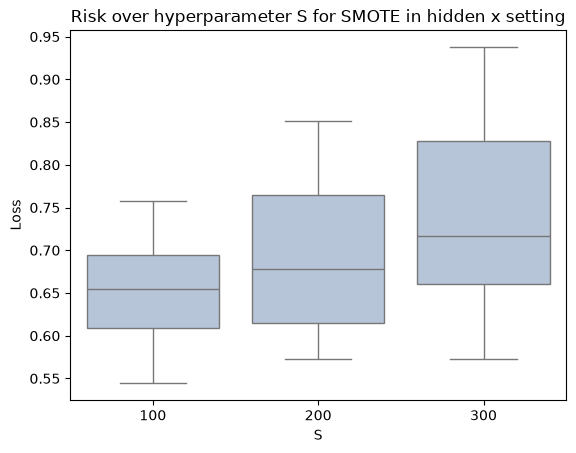

In [208]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "S", n = 100, x_means = alt_xmeans_unbalanced_2, n_runs=20)

### SMOTE "k"

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.5
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.494
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.504
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.511
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.493
100 (training) samples were generate

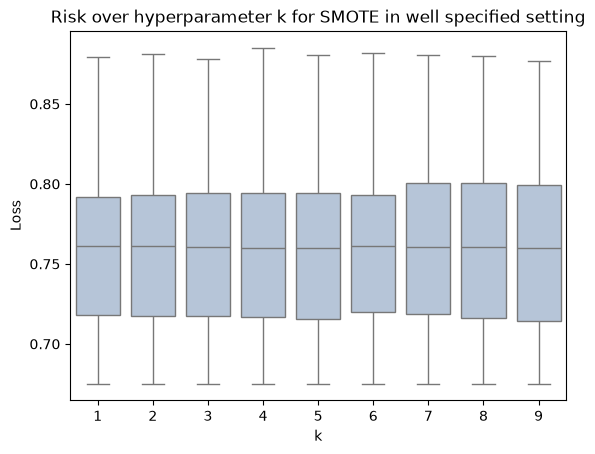

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of training samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated using the 1-dimensional setting de

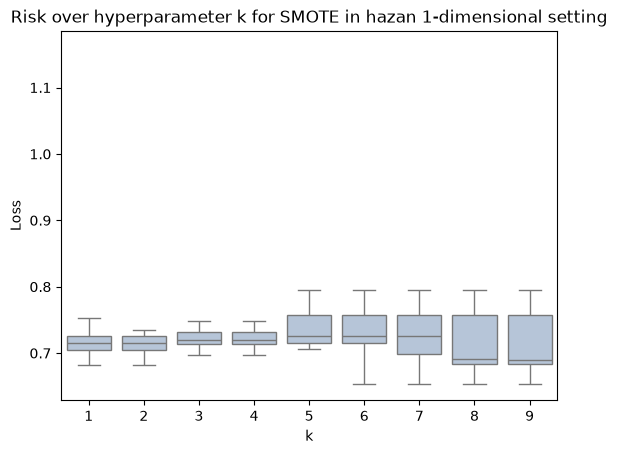

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.946
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.928
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (train

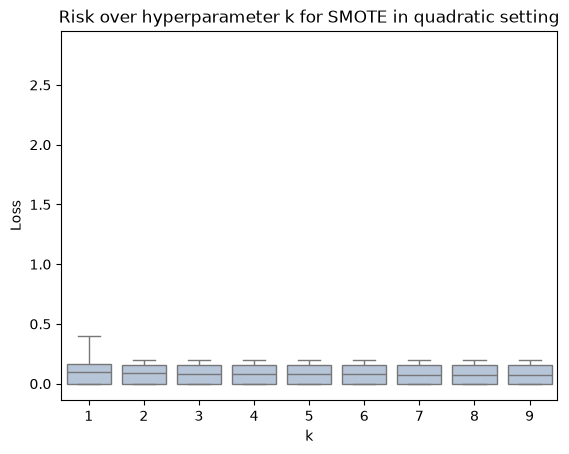

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.565
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average 

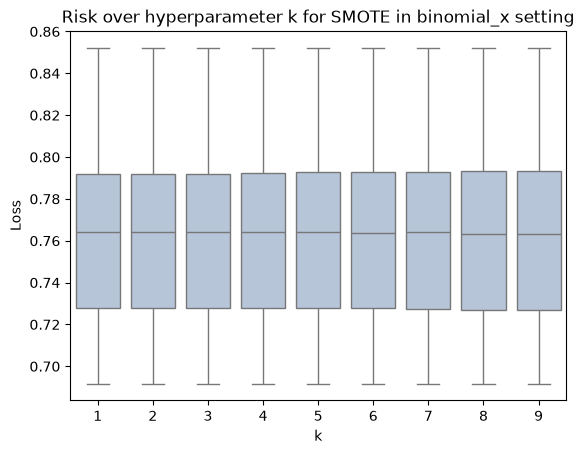

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.522
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.49
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.533
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.514
100 (training) samples were generated in the sinusoidal bal

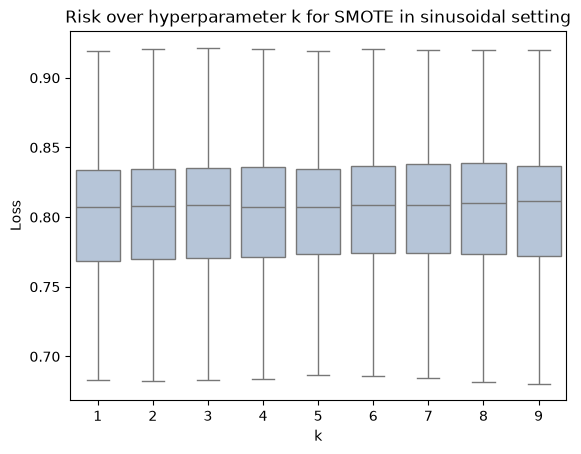

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.865
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.875
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.855
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.89
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.925
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.895
k must be smaller than the number of training samples
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) o

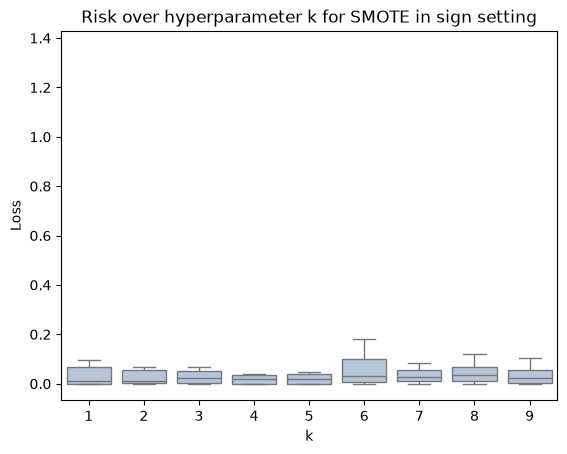

100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.496
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.472
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.459
1

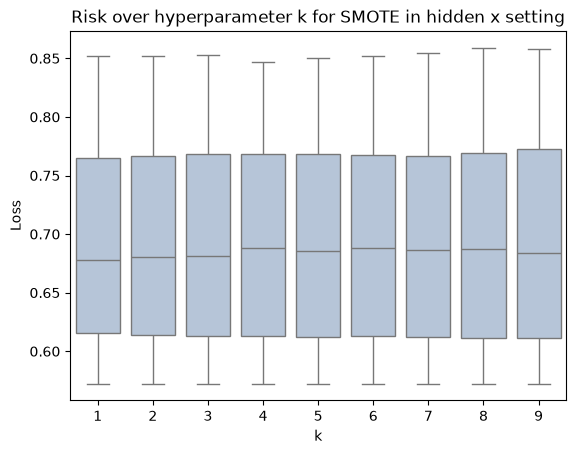

In [204]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "k", n = 100, x_means = alt_xmeans_balanced_1, n_runs=20)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.497
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.488
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P

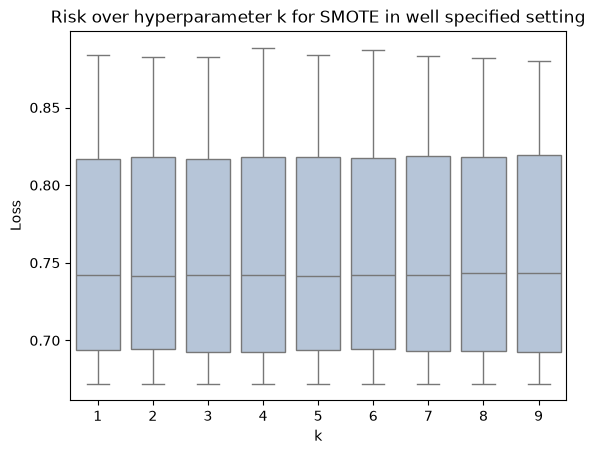

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of training samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated using the 1-dimensional setting de

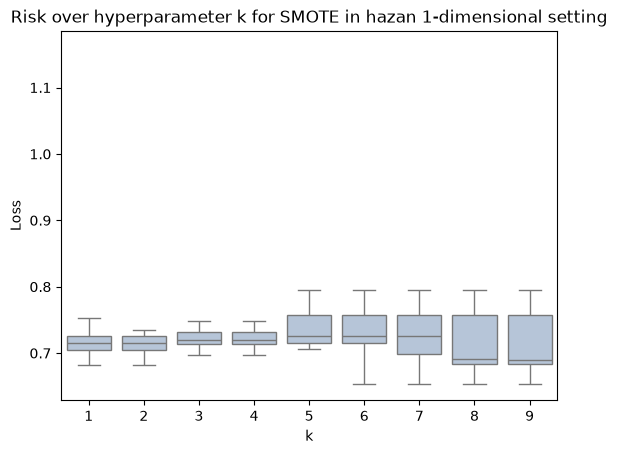

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression w

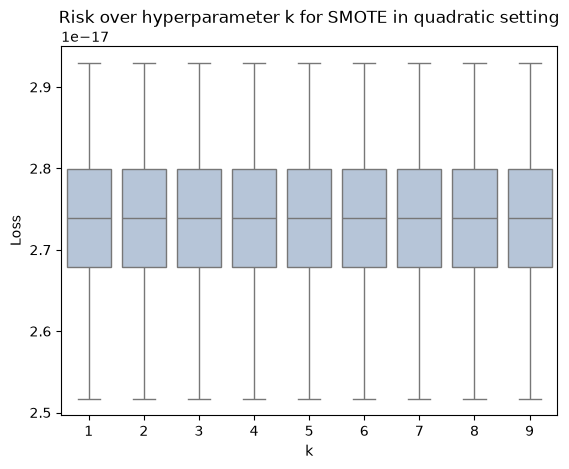

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.565
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average 

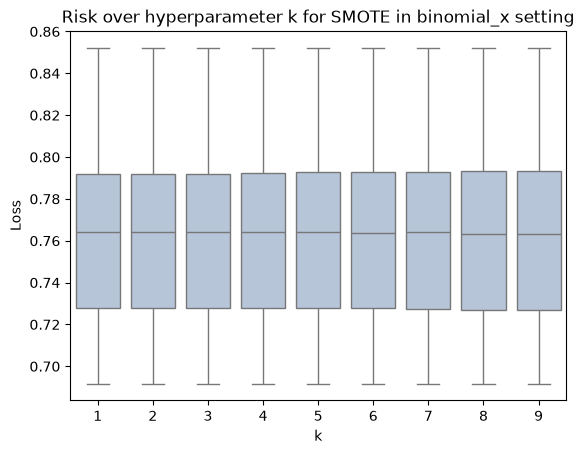

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.512
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.467
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.478
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.489
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.485
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average 

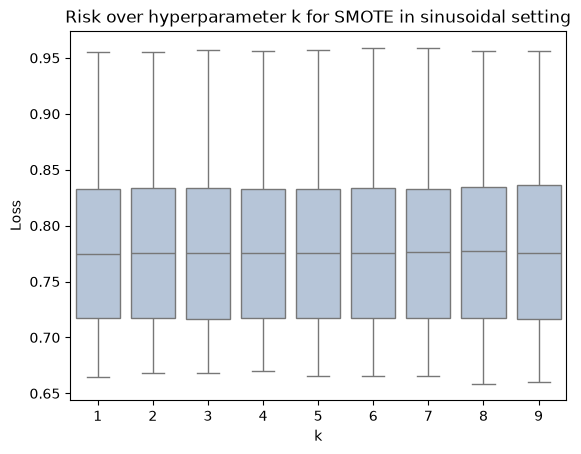

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit man

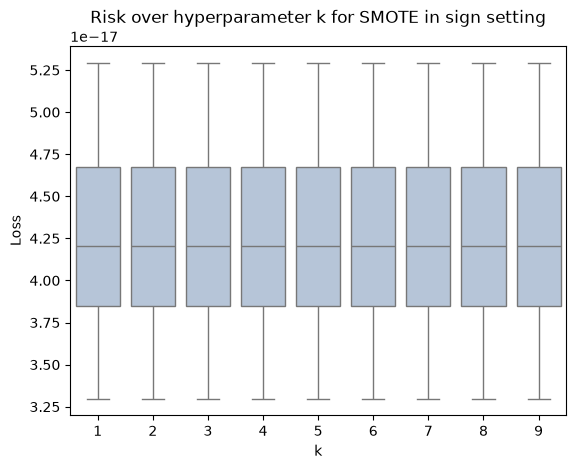

100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.496
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.472
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.459
1

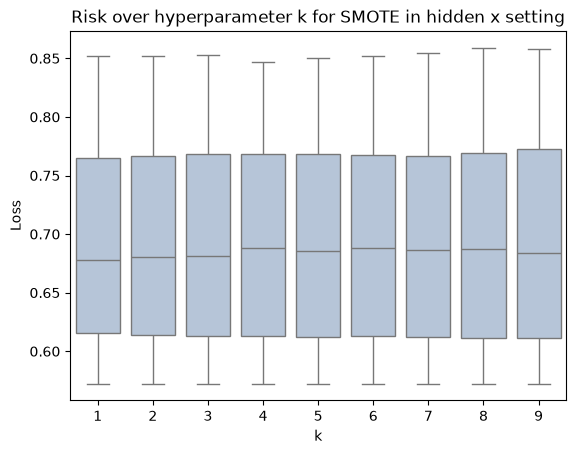

In [203]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "k", n = 100, x_means = alt_xmeans_balanced_2, n_runs=20)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.015
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.016
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples


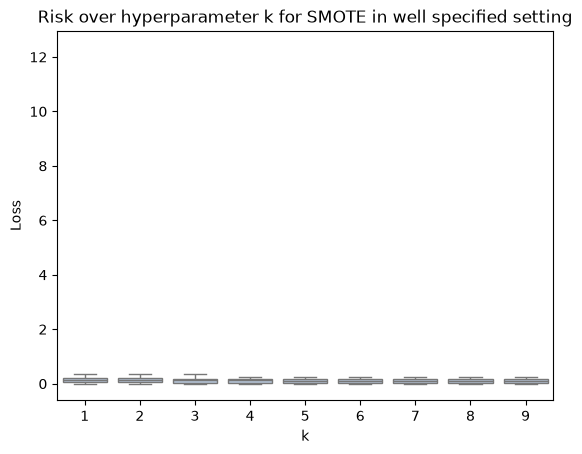

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of training samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated using the 1-dimensional setting de

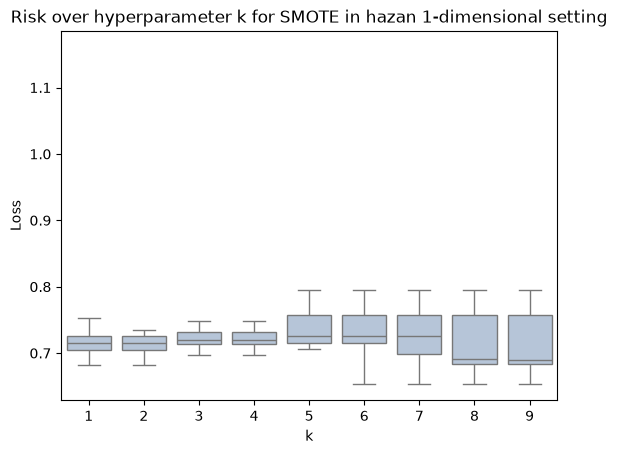

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.985
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.978
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regressi

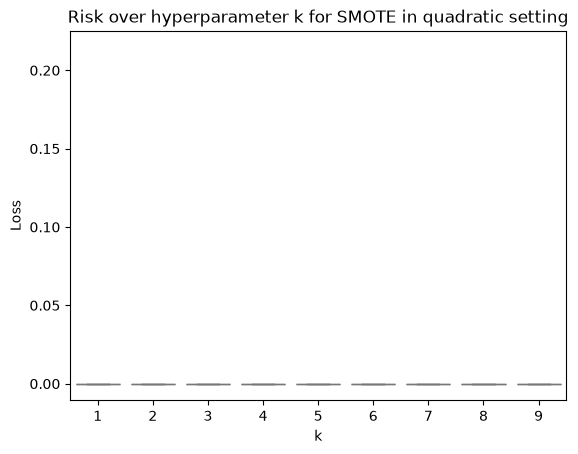

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.565
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average 

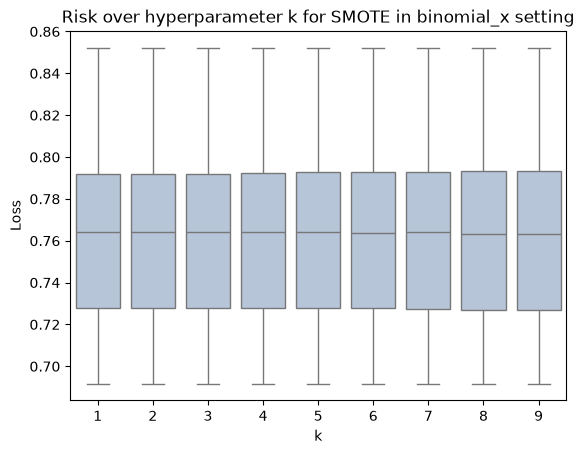

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.511
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.518
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.458
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.479
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.523
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.483
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.491
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average 

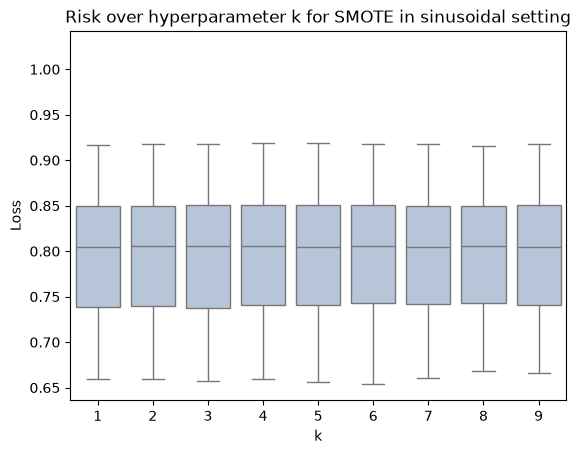

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.035
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.04
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.025
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of trainin

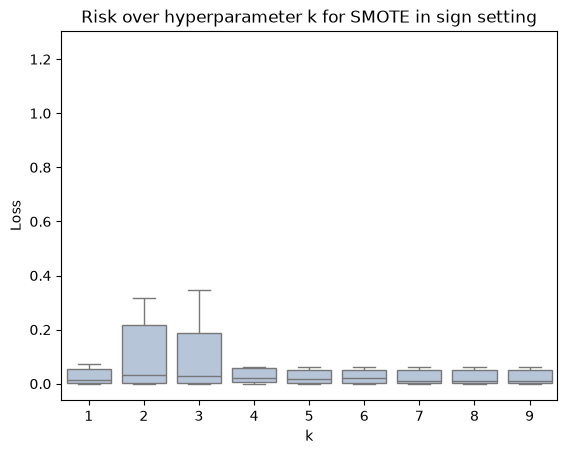

100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.496
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.472
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.459
1

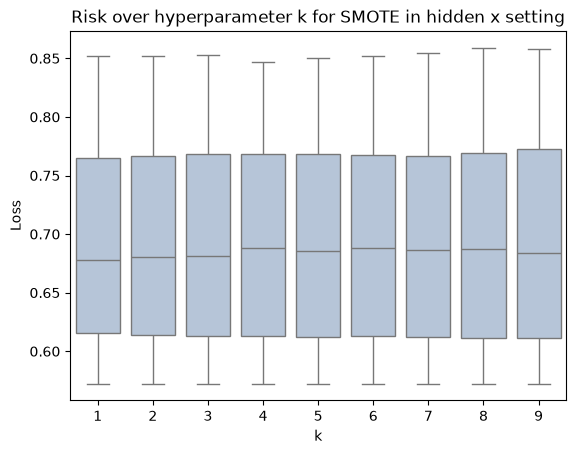

In [202]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "k", n = 100, x_means = alt_xmeans_unbalanced_1, n_runs=20)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.012
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.013
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples


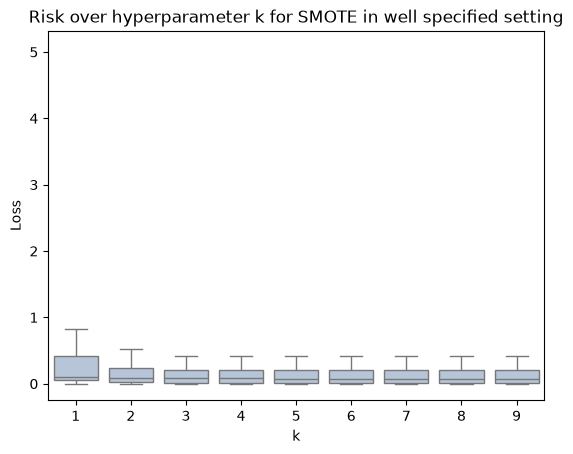

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of training samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of training samples
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.060000000000000005
k must be smaller than the number of training samples
k must be smaller than the number of training samples
100 (training) samples were generated using the 1-dimensional setting de

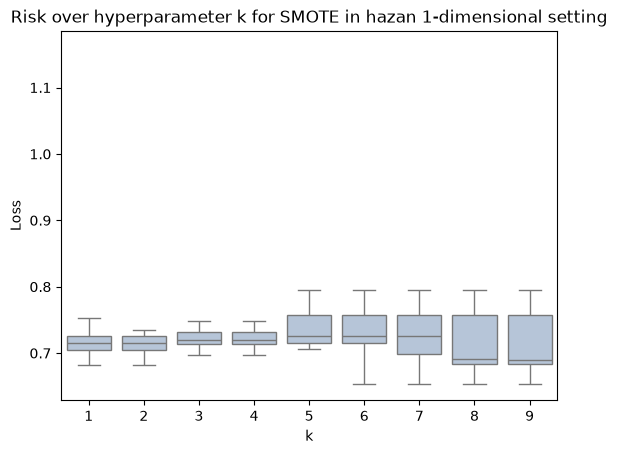

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression w

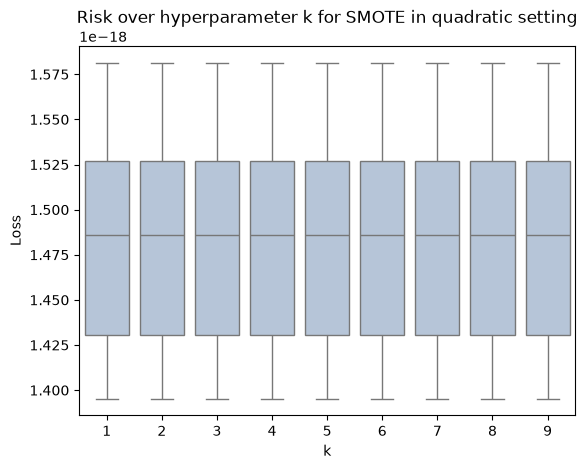

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.502
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.525
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.585
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.591
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.516
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.501
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.565
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average 

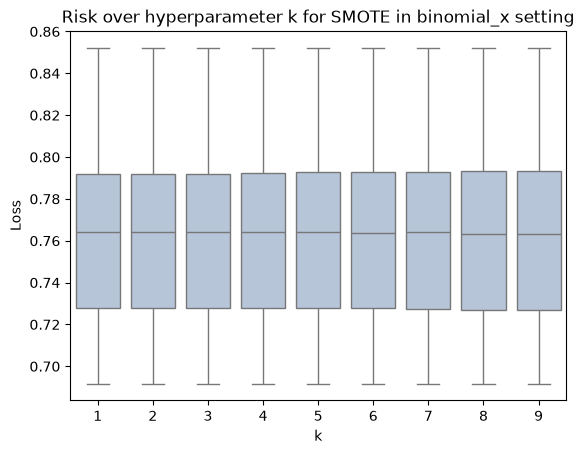

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.499
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.521
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.502
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
Dataset is balanced
100 (training) samples were generated in the sinusoidal ba

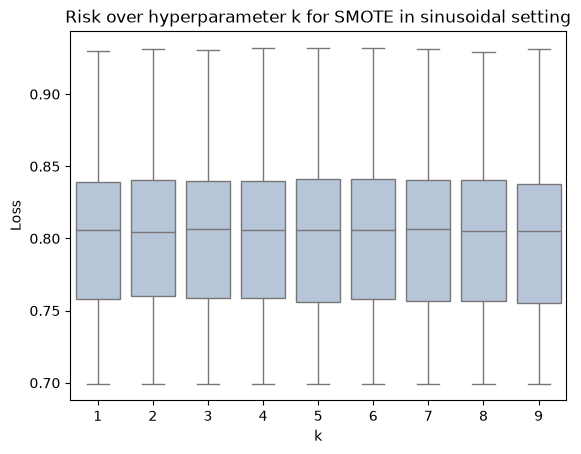

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.0
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit manually
Dataset only has one class
Logistic regression was fit man

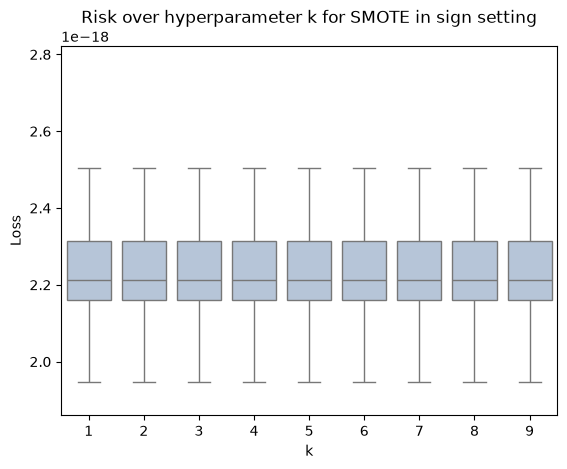

100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.54
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.496
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.531
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.472
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.462
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.482
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.459
1

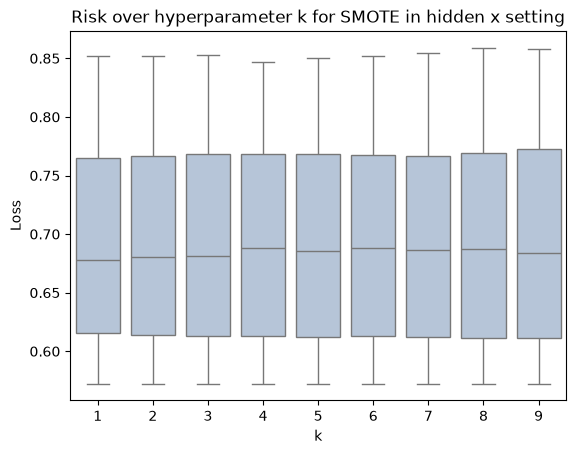

In [201]:
for setting in settings:
    hyperparameter_analysis(setting, "SMOTE", "k", n = 100, x_means = alt_xmeans_unbalanced_2, n_runs=20)

# Functions for simulations

## Data class for specifying simulation configuration

In [144]:
default_X = 1
default_B_Adagrad = 1.5
@dataclass
class SimulationConfig:
    sim_betas: list =  None,
    # Default is well specified
    sim_setting: str =  "well specified"
    sim_balanced: bool = True
    runs: int = default_runs
    n: int = default_n
    d: int = 3
    data_seed: int = 40
    # betas: list = field(default_factory=lambda: [2,0.1,-4.2]) # This is to create a new list every time.
    # x_means: list = field(default_factory=lambda: [2,2,1])
    # These values of betas and x_means guarantee a P(Y=1) = 0.5, hence balanced classes.
    test_ratio: float = default_test_size
    minimize_method: str = "l-bfgs-b"
    y_method: str = "sigmoid"
    X_hazan: int = 1

## Function to run simulations and get results

In [474]:
def run_simulation(cfg: SimulationConfig = None, B_hazan = None):
    runs = cfg.runs
    n = cfg.n
    d = cfg.d
    minimize_method = cfg.minimize_method
    data_seed = cfg.data_seed
    sim_setting = cfg.sim_setting
    sim_balanced = cfg.sim_balanced
    X_hazan = cfg.X_hazan
    sim_betas = cfg.sim_betas

    test_set_results = []
    time_results = []
    y_counts = []
    start_time = datetime.datetime.now()

    all_y_trains = {}
    all_y_tests = {}

    for i in range(runs):
        x_train, y_train, x_test, y_test = generate_data(setting = sim_setting,
                                                             balanced = sim_balanced,
                                                             n = n,
                                                             seed = data_seed + i,
                                                             d = d,
                                                             X_hazan = X_hazan,
                                                             betas = sim_betas,
                                                            B_hazan = B_hazan)

        y_counts.append({
            "count_1": int(np.sum(y_train == 1)),
            "count_minus1": int(np.sum(y_train == -1))
        })

        all_y_trains[f"run_{i+1}"] = y_train.copy()
        all_y_tests[f"run_{i+1}"] = y_test.copy()

        sm = SMOTE(data_x = x_train, data_y = y_train, S = 100)
        smote_x, smote_y = sm.apply_smote()

        def time_it(fn):
            """Runs fn(), returns (result, elapsed_seconds)."""
            t0 = datetime.datetime.now()
            result = fn()
            return result, (datetime.datetime.now() - t0).total_seconds()

        # ﷿﷿﷿﷿﷿﷿ Fit ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
        ogd,           t_ogd_fit        = time_it(lambda: online_gd(data_y=y_train, data_x=x_train))
        adagrad,       t_adagrad_fit    = time_it(lambda: online_AdaGrad(data_y=y_train, data_x=x_train, B_vector=np.repeat(default_B_Adagrad, d)))
        aioli_model                     = AIOLI()
        ai,            t_aioli_fit      = time_it(lambda: aioli_model.fit(data_y=y_train, data_x=x_train, X=default_X, B=np.log(n), minimize_method=minimize_method))
        classic_LR,    t_clr_fit        = time_it(lambda: classic_logistic_regression(data_x=x_train, data_y=y_train))
        ridge_LR,      t_ridge_fit      = time_it(lambda: ridge_logistic_regression(data_x=x_train, data_y=y_train))
        lasso_LR,      t_lasso_fit      = time_it(lambda: lasso_logistic_regression(data_x=x_train, data_y=y_train))
        smp,           t_smp_fit        = time_it(lambda: sample_minmax_predictor(x_train, y_train))
        ridge_smp,     t_ridge_smp_fit  = time_it(lambda: ridge_sample_minmax_predictor(x_train, y_train))
        classic_LR_smote, t_smote_fit   = time_it(lambda: classic_logistic_regression(data_x=smote_x, data_y=smote_y))

        # ﷿﷿﷿﷿﷿﷿ OTB averaging (counts toward OGD / AdaGrad time) ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
        OGD_OTB_uniform, t_ogd_u   = time_it(lambda: calculate_OTB(ogd["All_Betas"], "uniform"))
        OGD_OTB_Suffix,  t_ogd_s   = time_it(lambda: calculate_OTB(ogd["All_Betas"], "suffix_averaging"))
        OGD_OTB_lastit,  t_ogd_l   = time_it(lambda: calculate_OTB(ogd["All_Betas"], "last_iterate"))

        adagrad_OTB_uniform, t_ada_u = time_it(lambda: calculate_OTB(adagrad["All_Betas"], "uniform"))
        adagrad_OTB_Suffix,  t_ada_s = time_it(lambda: calculate_OTB(adagrad["All_Betas"], "suffix_averaging"))
        adagrad_OTB_lastit,  t_ada_l = time_it(lambda: calculate_OTB(adagrad["All_Betas"], "last_iterate"))

        # ﷿﷿﷿﷿﷿﷿ Loss on test set ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
        loss_OGD_uniform_test,  t_ogd_u_loss  = time_it(lambda: log_loss(OGD_OTB_uniform, x_test, y_test))
        loss_OGD_Suffix_test,   t_ogd_s_loss  = time_it(lambda: log_loss(OGD_OTB_Suffix,  x_test, y_test))
        loss_OGD_lastit_test,   t_ogd_l_loss  = time_it(lambda: log_loss(OGD_OTB_lastit,  x_test, y_test))

        loss_adagrad_uniform_test, t_ada_u_loss = time_it(lambda: log_loss(adagrad_OTB_uniform, x_test, y_test))
        loss_adagrad_Suffix_test,  t_ada_s_loss = time_it(lambda: log_loss(adagrad_OTB_Suffix,  x_test, y_test))
        loss_adagrad_lastit_test,  t_ada_l_loss = time_it(lambda: log_loss(adagrad_OTB_lastit,  x_test, y_test))

        loss_AIOLI_uniform_test, t_aioli_u_loss = time_it(lambda: aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"])
        loss_AIOLI_Suffix_test,  t_aioli_s_loss = time_it(lambda: aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="suffix_averaging")["loss"])
        loss_AIOLI_lastit_test,  t_aioli_l_loss = time_it(lambda: aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="last_iterate")["loss"])

        loss_LR_test,       t_clr_loss       = time_it(lambda: log_loss(classic_LR["Batch_estimate"],       x_test, y_test))
        loss_LR_smote_test, t_smote_loss     = time_it(lambda: log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test))
        loss_LR_Ridge_test, t_ridge_loss     = time_it(lambda: log_loss(ridge_LR["Batch_estimate"],         x_test, y_test))
        loss_LR_Lasso_test, t_lasso_loss     = time_it(lambda: log_loss(lasso_LR["Batch_estimate"],         x_test, y_test))

        smp_result,       t_smp_loss      = time_it(lambda: smp.get_new_loss(x_test, y_test))
        ridge_smp_result, t_ridge_smp_loss = time_it(lambda: ridge_smp.get_new_loss(x_test, y_test))

        # ﷿﷿﷿﷿﷿﷿ Collate results ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
        algorithms_test = {
            "Classical_LR":         {"loss": loss_LR_test,              "time_fit": t_clr_fit,       "time_loss": t_clr_loss},
            "Classical_LR_SMOTE":   {"loss": loss_LR_smote_test,        "time_fit": t_smote_fit,     "time_loss": t_smote_loss},
            "Ridge_LR":             {"loss": loss_LR_Ridge_test,         "time_fit": t_ridge_fit,     "time_loss": t_ridge_loss},
            "Lasso_LR":             {"loss": loss_LR_Lasso_test,         "time_fit": t_lasso_fit,     "time_loss": t_lasso_loss},
            "OGD_uniform":          {"loss": loss_OGD_uniform_test,      "time_fit": t_ogd_fit,       "time_loss": t_ogd_u + t_ogd_u_loss},
            "OGD_Suffix":           {"loss": loss_OGD_Suffix_test,       "time_fit": t_ogd_fit,       "time_loss": t_ogd_s + t_ogd_s_loss},
            "OGD_Last_iterate":     {"loss": loss_OGD_lastit_test,       "time_fit": t_ogd_fit,       "time_loss": t_ogd_l + t_ogd_l_loss},
            "AdaGrad_uniform":      {"loss": loss_adagrad_uniform_test,  "time_fit": t_adagrad_fit,   "time_loss": t_ada_u + t_ada_u_loss},
            "AdaGrad_Suffix":       {"loss": loss_adagrad_Suffix_test,   "time_fit": t_adagrad_fit,   "time_loss": t_ada_s + t_ada_s_loss},
            "AdaGrad_Last_iterate": {"loss": loss_adagrad_lastit_test,   "time_fit": t_adagrad_fit,   "time_loss": t_ada_l + t_ada_l_loss},
            "AIOLI_uniform":        {"loss": loss_AIOLI_uniform_test,    "time_fit": t_aioli_fit,     "time_loss": t_aioli_u_loss},
            "AIOLI_Suffix":         {"loss": loss_AIOLI_Suffix_test,     "time_fit": t_aioli_fit,     "time_loss": t_aioli_s_loss},
            "AIOLI_lastit":         {"loss": loss_AIOLI_lastit_test,     "time_fit": t_aioli_fit,     "time_loss": t_aioli_l_loss},
            "SMP":                  {"loss": smp_result["loss"],         "time_fit": t_smp_fit,       "time_loss": t_smp_loss},
            "Ridge_SMP":            {"loss": ridge_smp_result["loss"],   "time_fit": t_ridge_smp_fit, "time_loss": t_ridge_smp_loss},
        }

        for name, metrics in algorithms_test.items():
            row = {"run": i + 1, "algorithm": name, **metrics}
            row["time_total"] = row["time_fit"] + row["time_loss"]
            test_set_results.append(row)

        print(f"Run {i+1} finished")

    endtime = datetime.datetime.now()
    total_time = (endtime - start_time).total_seconds()

    results_df = pd.DataFrame(test_set_results)

    return {
        "test_results":    results_df[["run", "algorithm", "loss"]],
        "time_results":    results_df[["run", "algorithm", "time_fit", "time_loss", "time_total"]],
        "y_counts_train":  pd.DataFrame(y_counts),
        "y_train_df":      pd.DataFrame(all_y_trains),
        "y_test_df":       pd.DataFrame(all_y_tests),
        "total_time":      total_time,
    }

## Simulations changing n

In [748]:
def simulations_changing_n(n_values: list, base_config: SimulationConfig, filename, B_hazan = None) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Run simulations for multiple sample sizes and aggregate results.

    Args:
        n_values: List of sample sizes to simulate
        base_config: Base SimulationConfig object (will copy and modify n for each run)

    Returns:
        summary_df: DataFrame with columns: n, algorithm, avg_loss, std_loss, num_runs
        raw_df: DataFrame with columns: n, algorithm, loss (one row per run)
    """
    all_summaries = []
    all_raw = []
    total_time = 0

    for n in n_values:
        print(f"="*50)
        print(f"Running simulations for n = {n}\n")
        print(f"="*50)
        # Create a copy of the config with the new n value
        config = base_config
        config.n = n  # Modify n in place

        # Run the simulation
        results_dict = run_simulation(config, B_hazan = B_hazan)

        # Extract test results
        test_results_df = results_dict["test_results"]
        total_time += results_dict["total_time"]

        # Add n column to raw data
        raw_with_n = test_results_df.copy()
        raw_with_n['n'] = n
        all_raw.append(raw_with_n)

        # Calculate average loss and standard deviation for each algorithm
        summary = test_results_df.groupby('algorithm').agg({
            'loss': ['mean', 'std', 'count']
        }).reset_index()


        # Flatten column names
        summary.columns = ['algorithm', 'avg_loss', 'std_loss', 'num_runs']

        summary['se_loss'] = summary['std_loss'] / np.sqrt(summary['num_runs'])
        summary = summary.drop(columns=["std_loss"])

        # Add n value
        summary['n'] = n

        # Reorder columns
        summary = summary[['n', 'algorithm', 'avg_loss', 'se_loss', 'num_runs']]

        all_summaries.append(summary)

        print(f"Completed simulations for n = {n}")

        # Save to csv
        temp_summary_df = pd.concat(all_summaries, ignore_index=True)
        temp_summary_df.to_csv(f"{filename}.csv")

    # Combine all results
    summary_df = pd.concat(all_summaries, ignore_index=True)
    raw_df = pd.concat(all_raw, ignore_index=True)
    print(f"Total time: {total_time} seconds")
    return summary_df, raw_df

In [335]:
def plot_simulation_results(
    raw_data: pd.DataFrame,
    algorithms: list = None,
    figsize: tuple = (12, 8),
    title: str = 'Algorithm Performance vs Sample Size',
    xlabel: str = 'Sample Size (n)',
    ylabel: str = 'Expected Risk',
    box_alpha: float = 0.6,
    show_plot: bool = True
) -> plt.Figure:
    """
    Plot box plots of loss distributions per algorithm across different sample sizes.

    Args:
        raw_data: DataFrame with columns: algorithm, n, loss (one row per run)
        algorithms: List of algorithm names to plot (None = all)
        figsize: Figure size (width, height)
        title: Plot title
        xlabel: X-axis label
        ylabel: Y-axis label
        box_alpha: Transparency of box fill (0 = transparent, 1 = opaque)
        show_plot: Whether to display the plot

    Returns:
        None
    """
    # Filter algorithms if specified
    raw_plot = raw_data.copy()
    if algorithms is not None:
        raw_plot = raw_plot[raw_plot['algorithm'].isin(algorithms)]

    if raw_plot.empty:
        print("No data to plot.")
        return None

    # Ensure n is treated as a categorical axis so boxes are evenly spaced
    raw_plot["n"] = raw_plot["n"].astype(str)

    fig, ax = plt.subplots(figsize=figsize)
    sns.set_style("whitegrid")

    sns.boxplot(
        data=raw_plot,
        x="n",
        y="loss",
        hue="algorithm",
        palette="bright",
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=4, alpha=0.5, linestyle='none'),
        ax=ax
    )

    # Apply alpha to box fills post-hoc
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, box_alpha))

    # Formatting
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.legend(title="Algorithm", loc='best', prop={'size': 10})
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if show_plot:
        plt.show()

    return None

In [111]:
def get_variable_name(var, namespace=None):
    if namespace is None:
        namespace = globals()
    for name, value in namespace.items():
        if value is var:
            return name
    return None

In [291]:
default_runs

10

## Function for printing results

In [385]:
def print_results(results, n=default_n, plot=False, selected_algorithms=None, runs=default_runs, box_alpha=0.6):
    # Save to csv
    df_name = get_variable_name(results)
    results["test_results"].to_csv(f"{df_name}.csv")

    # ﷿﷿﷿﷿﷿﷿ Loss summary ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
    summary_test_average = results["test_results"].groupby("algorithm")[["loss"]].mean()
    summary_test_se      = results["test_results"].groupby("algorithm")[["loss"]].std() / np.sqrt(runs)

    summary = pd.concat([summary_test_average, summary_test_se], axis=1)
    summary.columns = ["Average_Loss", "SE_Loss"]

    # ﷿﷿﷿﷿﷿﷿ Time summary ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
    time_avg = results["time_results"].groupby("algorithm")[["time_fit", "time_loss", "time_total"]].mean()
    time_se  = results["time_results"].groupby("algorithm")[["time_total"]].std() / np.sqrt(runs)

    time_summary = pd.concat([time_avg, time_se], axis=1)
    time_summary.columns = [
        "Avg_Time_Fit", "Avg_Time_Loss", "Avg_Time_Total", "SE_Time_Total"
    ]

    # ﷿﷿﷿﷿﷿﷿ Print ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
    print(f"Total time: {str(datetime.timedelta(seconds=results['total_time']))}")

    print("\n﷿﷿﷿﷿﷿﷿ Loss Results ﷿﷿﷿﷿﷿﷿")
    display(summary)

    print("\n﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿")
    display(time_summary)

    # ﷿﷿﷿﷿﷿﷿ Boxplot ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿
    if not plot:
        return

    raw_data = results["test_results"].copy()
    if selected_algorithms is not None:
        raw_data = raw_data[raw_data["algorithm"].isin(selected_algorithms)]

    if raw_data.empty:
        print("No data to plot.")
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.set_style("whitegrid")

    sns.boxplot(
        data=raw_data,
        x="algorithm",
        y="loss",
        palette="bright",
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=4, alpha=0.5, linestyle='none'),
        ax=ax
    )

    # Apply alpha to box fills post-hoc
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, box_alpha))

    # Aesthetics
    ax.set_xlabel("Algorithm", fontsize=12, fontweight="bold")
    ax.set_ylabel("Risk", fontsize=12, fontweight="bold")
    ax.set_title("Expected Risk distribution across runs", fontsize=14, fontweight="bold")
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Function for graphing loss and Y=1 counts over runs

In [726]:
def plot_results(results, n = default_n, plot = False):
    test_results = results["test_results"]

    # Boxplots of y counts
    if plot:
        sns.boxplot(data=results["y_counts_train"][["count_1", "count_minus1"]])
        plt.title("Distribution of Y counts across runs")
        plt.ylim(-10, n)
        plt.show()
    else:
        pass

    # Distribution of y values
    print("Train set")
    print(results["y_train_df"].apply(pd.Series.value_counts))
    print("Test set")
    print(results["y_test_df"].apply(pd.Series.value_counts))

    # Line plot of Loss over rounds
    sns.lineplot(x = test_results["run"], y = test_results["loss"], hue = test_results["algorithm"]).set_title("Loss over rounds")
    plt.show()


## Compare settings

In [114]:
def compare_settings(
    settings_dict: dict,
    selected_algorithms: list = None,
    figsize: tuple = (12, 6),
    title: str = 'Algorithm Performance Across Balanced Settings',
    xlabel: str = 'Setting',
    ylabel: str = 'Expected Risk',
    marker_alpha: float = 0.6,
    marker_size: int = 18,
    show_plot: bool = True,
    return_data: bool = False
):
    """
    Combine results from multiple settings and create a point plot of average loss
    per algorithm (no error bars, no connecting lines) with custom square markers.

    Parameters:
        settings_dict : dict
            Keys are setting names (str), values are results dictionaries from run_simulation.
        selected_algorithms : list, optional
            List of algorithm names to include. If None, all are plotted.
        figsize : tuple
            Figure size.
        title, xlabel, ylabel : str
            Plot labels.
        marker_alpha : float
            Transparency of the marker fill (0 = transparent, 1 = opaque).
        marker_size : int
            Size of the marker (area in points^2).
        show_plot : bool
            Whether to display the plot.
        return_data : bool
            If True, return the combined raw DataFrame.

    Returns:
        raw_df : pd.DataFrame (optional)
            Combined raw data with columns: setting, algorithm, loss.
    """
    # Collect raw data from all settings
    all_raw = []
    for setting, res in settings_dict.items():
        df = res["test_results"].copy()
        df["setting"] = setting
        all_raw.append(df)
    combined_raw = pd.concat(all_raw, ignore_index=True)

    # Filter algorithms if needed
    if selected_algorithms is not None:
        combined_raw = combined_raw[combined_raw["algorithm"].isin(selected_algorithms)]

    if combined_raw.empty:
        print("No data to plot.")
        return

    # Create pointplot this handles dodging automatically
    plt.figure(figsize=figsize)
    sns.set_style("whitegrid")

    ax = sns.pointplot(
        data=combined_raw,
        x="setting",
        y="loss",
        hue="algorithm",
        estimator=np.mean,
        errorbar=None,
        dodge=0.05,
        palette="bright",
        marker="s",          # square markers
        markersize=marker_size,
        linestyle="none",    # remove connecting lines if not needed
    )

    # Apply alpha and edgecolor post-hoc (pointplot doesn't forward these)
    for line in ax.get_lines():
        line.set_alpha(marker_alpha)
        line.set_markeredgecolor("black")
        line.set_markeredgewidth(0.8)  # adjust edge thickness as needed

    # Remove the connecting lines that pointplot draws by default
    for line in ax.lines:
        line.set_linewidth(0)

    # Customise the markers: transparent squares with black border
    for collection in ax.collections:
        collection.set_marker('s')          # square marker
        collection.set_sizes([marker_size]) # size in points^2
        collection.set_alpha(marker_alpha)  # fill transparency
        collection.set_edgecolor('black')   # border colour
        collection.set_linewidth(1)         # border thickness

    # Formatting
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=14, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.legend(title="Algorithm", loc="best", markerscale=0.5, prop={'size': 10})

    # Keep x-axis labels horizontal
    plt.xticks(rotation=0)
    plt.tight_layout()

    if show_plot:
        plt.show()

    if return_data:
        return combined_raw
    else:
        return None

In [325]:
def compare_settings(
    settings_dict: dict,
    selected_algorithms: list = None,
    x_labels: dict = None,
    figsize: tuple = (12, 6),
    title: str = 'Algorithm Performance Across Balanced Settings',
    xlabel: str = 'Setting',
    ylabel: str = 'Expected Risk',
    box_alpha: float = 0.6,
    show_plot: bool = True,
    return_data: bool = False
):
    """
    Combine results from multiple settings and create a box plot of loss
    per algorithm across runs.

    Parameters:
        settings_dict : dict
            Keys are setting names (str), values are results dictionaries from run_simulation.
        selected_algorithms : list, optional
            List of algorithm names to include. If None, all are plotted.
        x_labels : dict, optional
            Mapping from setting key to display label on the x-axis.
            e.g. {"s1": "Well Specified", "s2": "High Dimensional"}
            If None, the setting keys are used as-is.
        figsize : tuple
            Figure size.
        title, xlabel, ylabel : str
            Plot labels.
        box_alpha : float
            Transparency of the box fill (0 = transparent, 1 = opaque).
        show_plot : bool
            Whether to display the plot.
        return_data : bool
            If True, return the combined raw DataFrame.

    Returns:
        raw_df : pd.DataFrame (optional)
            Combined raw data with columns: setting, algorithm, loss.
    """
    # Collect raw data from all settings
    all_raw = []
    for setting, res in settings_dict.items():
        df = res["test_results"].copy()
        df["setting"] = setting
        all_raw.append(df)
    combined_raw = pd.concat(all_raw, ignore_index=True)

    # Remap setting keys to display labels if provided
    if x_labels is not None:
        combined_raw["setting"] = combined_raw["setting"].map(x_labels).fillna(combined_raw["setting"])

    # Filter algorithms if needed
    if selected_algorithms is not None:
        combined_raw = combined_raw[combined_raw["algorithm"].isin(selected_algorithms)]

    if combined_raw.empty:
        print("No data to plot.")
        return

    plt.figure(figsize=figsize)
    sns.set_style("whitegrid")

    ax = sns.boxplot(
        data=combined_raw,
        x="setting",
        y="loss",
        hue="algorithm",
        palette="bright",
        linewidth=1.2,
        flierprops=dict(marker='o', markersize=4, alpha=0.5, linestyle='none'),
    )

    # Apply alpha to box fills post-hoc
    for patch in ax.patches:
        r, g, b, _ = patch.get_facecolor()
        patch.set_facecolor((r, g, b, box_alpha))

    # Formatting
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=14, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.legend(title="Algorithm", loc="best", prop={'size': 10})

    plt.xticks(rotation=0)
    plt.tight_layout()

    if show_plot:
        plt.show()

    if return_data:
        return combined_raw
    else:
        return None

# Experiments

## Hazan setting

In [518]:
hazan = SimulationConfig(
    sim_setting = "hazan 1-dimensional",
    n = 100,
    runs = 10
)

hazan_result = run_simulation(hazan)
print_results(hazan_result)

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011324349949065293
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011324349949065293
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.011324349949065293
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 3 finished
100 (training) samples were generated using

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.662622,0.009596
AIOLI_lastit,0.657646,0.011938
AIOLI_uniform,0.669410,0.005825
AdaGrad_Last_iterate,0.632902,0.028442
AdaGrad_Suffix,0.636797,0.026572
AdaGrad_uniform,0.646343,0.021288
Classical_LR,1.752934,0.832658
Classical_LR_SMOTE,1.761811,0.831387
Lasso_LR,0.693147,0.000000



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.026667,2.369058,2.395725,0.011090
AIOLI_lastit,0.026667,2.643806,2.670473,0.260402
AIOLI_uniform,0.026667,2.409929,2.436596,0.011609
AdaGrad_Last_iterate,0.000661,0.000006,0.000668,0.000010
AdaGrad_Suffix,0.000661,0.000010,0.000671,0.000010
AdaGrad_uniform,0.000661,0.000010,0.000671,0.000010
Classical_LR,0.001893,0.000014,0.001908,0.000389
Classical_LR_SMOTE,0.001629,0.000008,0.001636,0.000387
Lasso_LR,0.008808,0.000006,0.008813,0.000585


In [486]:
hazan_result["test_results"]

,run,algorithm,loss
0,1,Classical_LR,0.000003
1,1,Classical_LR_SMOTE,0.000003
2,1,Ridge_LR,0.688724
3,1,Lasso_LR,0.693147
4,1,OGD_uniform,0.692091
...,...,...,...
145,10,AIOLI_uniform,0.688674
146,10,AIOLI_Suffix,0.686040
147,10,AIOLI_lastit,0.670571
148,10,SMP,0.670016


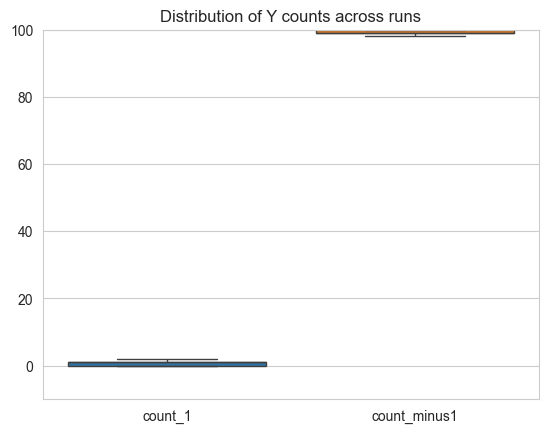

Train set
      run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1.0  100.0  100.0  100.0     98     99     99  100.0     99     98      99
 1.0    NaN    NaN    NaN      2      1      1    NaN      1      2       1
Test set
      run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1.0  100.0  100.0     99     98  100.0     99     99  100.0  100.0   100.0
 1.0    NaN    NaN      1      2    NaN      1      1    NaN    NaN     NaN


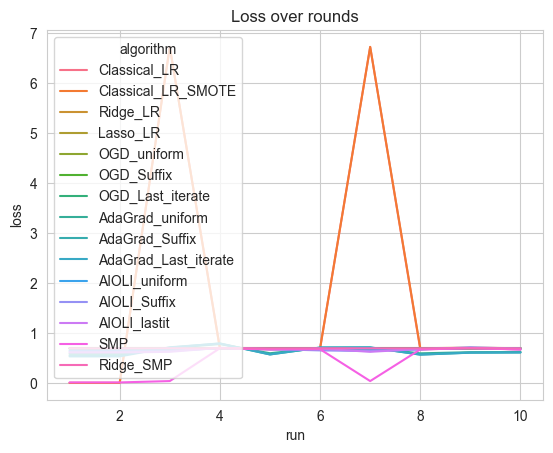

In [488]:
plot_results(hazan_result)

In [489]:
hazan_result["test_results"]

,run,algorithm,loss
0,1,Classical_LR,0.000003
1,1,Classical_LR_SMOTE,0.000003
2,1,Ridge_LR,0.688724
3,1,Lasso_LR,0.693147
4,1,OGD_uniform,0.692091
...,...,...,...
145,10,AIOLI_uniform,0.688674
146,10,AIOLI_Suffix,0.686040
147,10,AIOLI_lastit,0.670571
148,10,SMP,0.670016


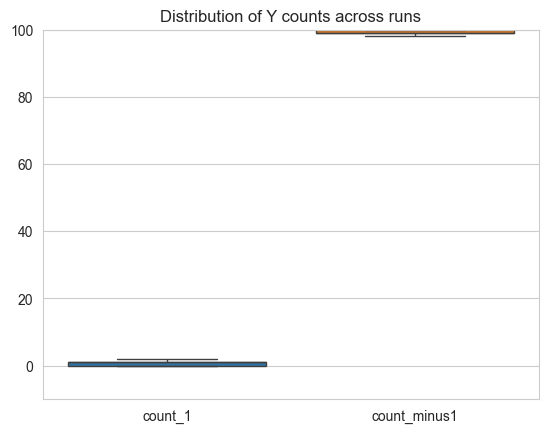

Train set
      run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1.0  100.0  100.0  100.0     98     99     99  100.0     99     98      99
 1.0    NaN    NaN    NaN      2      1      1    NaN      1      2       1
Test set
      run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1.0  100.0  100.0     99     98  100.0     99     99  100.0  100.0   100.0
 1.0    NaN    NaN      1      2    NaN      1      1    NaN    NaN     NaN


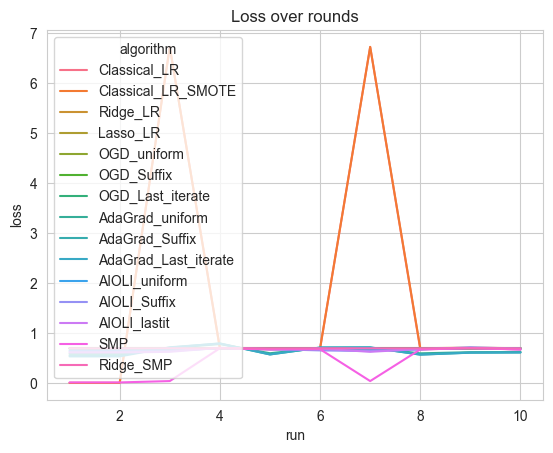

In [490]:
plot_results(hazan_result, n = 100)

In [491]:
hazan_Xminus1 = SimulationConfig(
    sim_setting = "hazan 1-dimensional",
    n = 100,
    runs = 10,
    X_hazan = -1
)

hazan_Xminus1_result = run_simulation(hazan_Xminus1)
print_results(hazan_Xminus1_result)

100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007549566632710195
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007549566632710195
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
100 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.007549566632710195
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 3 finished
100 (training) samples were generated using

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.653238,0.009347
AIOLI_lastit,0.642665,0.011439
AIOLI_uniform,0.664120,0.005641
AdaGrad_Last_iterate,0.637665,0.034849
AdaGrad_Suffix,0.641873,0.031625
AdaGrad_uniform,0.649103,0.024058
Classical_LR,2.290496,0.971419
Classical_LR_SMOTE,2.294860,0.970614
Lasso_LR,0.693147,0.000000



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.038667,3.611278,3.649944,0.262389
AIOLI_lastit,0.038667,3.364747,3.403414,0.027526
AIOLI_uniform,0.038667,3.449401,3.488068,0.028500
AdaGrad_Last_iterate,0.001265,0.000011,0.001276,0.000268
AdaGrad_Suffix,0.001265,0.000015,0.001281,0.000269
AdaGrad_uniform,0.001265,0.000016,0.001282,0.000269
Classical_LR,0.003040,0.000020,0.003060,0.000717
Classical_LR_SMOTE,0.002561,0.000012,0.002573,0.000494
Lasso_LR,0.012242,0.000009,0.012251,0.001167


Total time: 0:01:49.648430

﷿﷿﷿﷿﷿﷿ Loss Results ﷿﷿﷿﷿﷿﷿


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.653238,0.009347
AIOLI_lastit,0.642665,0.011439
AIOLI_uniform,0.664120,0.005641
AdaGrad_Last_iterate,0.637665,0.034849
AdaGrad_Suffix,0.641873,0.031625
AdaGrad_uniform,0.649103,0.024058
Classical_LR,2.290496,0.971419
Classical_LR_SMOTE,2.294860,0.970614
Lasso_LR,0.693147,0.000000



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.038667,3.611278,3.649944,0.262389
AIOLI_lastit,0.038667,3.364747,3.403414,0.027526
AIOLI_uniform,0.038667,3.449401,3.488068,0.028500
AdaGrad_Last_iterate,0.001265,0.000011,0.001276,0.000268
AdaGrad_Suffix,0.001265,0.000015,0.001281,0.000269
AdaGrad_uniform,0.001265,0.000016,0.001282,0.000269
Classical_LR,0.003040,0.000020,0.003060,0.000717
Classical_LR_SMOTE,0.002561,0.000012,0.002573,0.000494
Lasso_LR,0.012242,0.000009,0.012251,0.001167


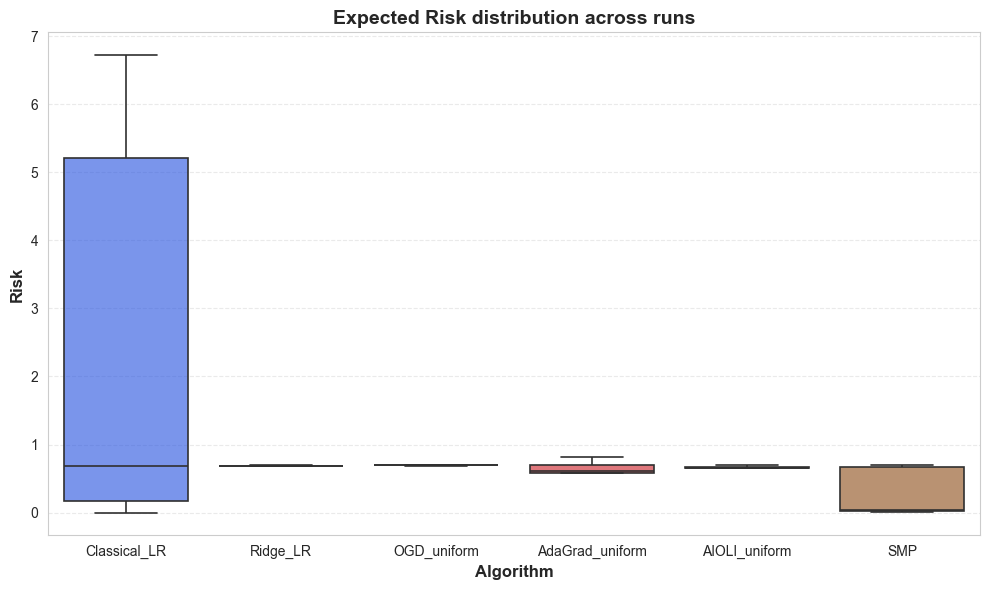

In [492]:
print_results(hazan_Xminus1_result, selected_algorithms = ["Classical_LR","SMP","AIOLI_uniform", "Ridge_LR","OGD_uniform","AdaGrad_uniform"], plot = True)

In [493]:
settings_results = {
    "Hazan": hazan_result,
    # "Hazan_Xminus1": hazan_Xminus1_result
}

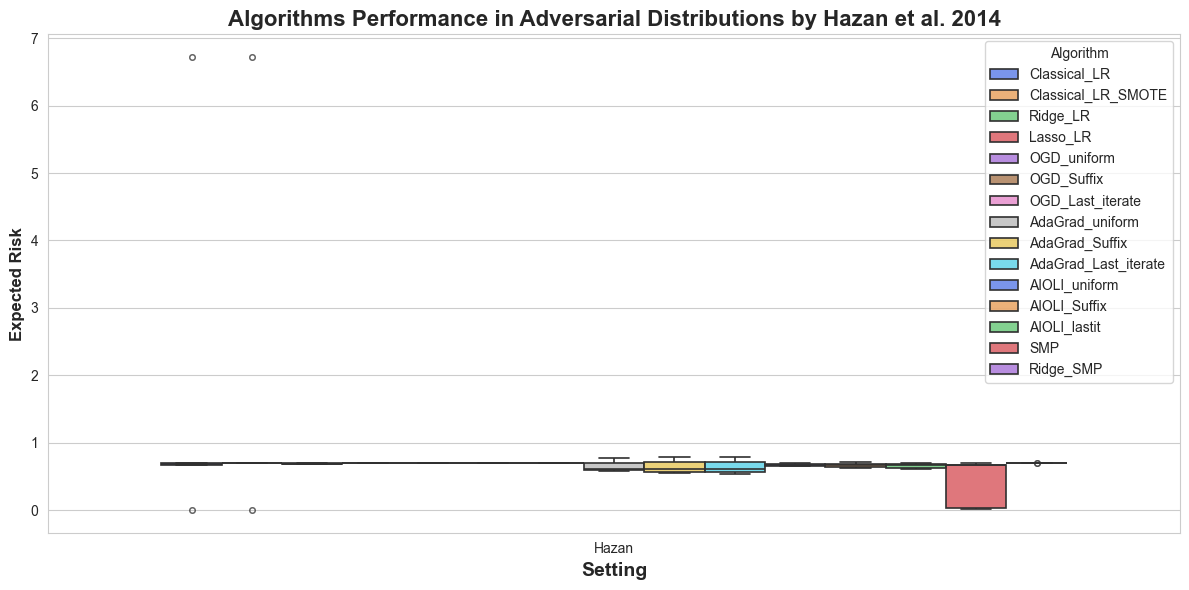

In [494]:
compare_settings(settings_results, title = "Algorithms Performance in Adversarial Distributions by Hazan et al. 2014")

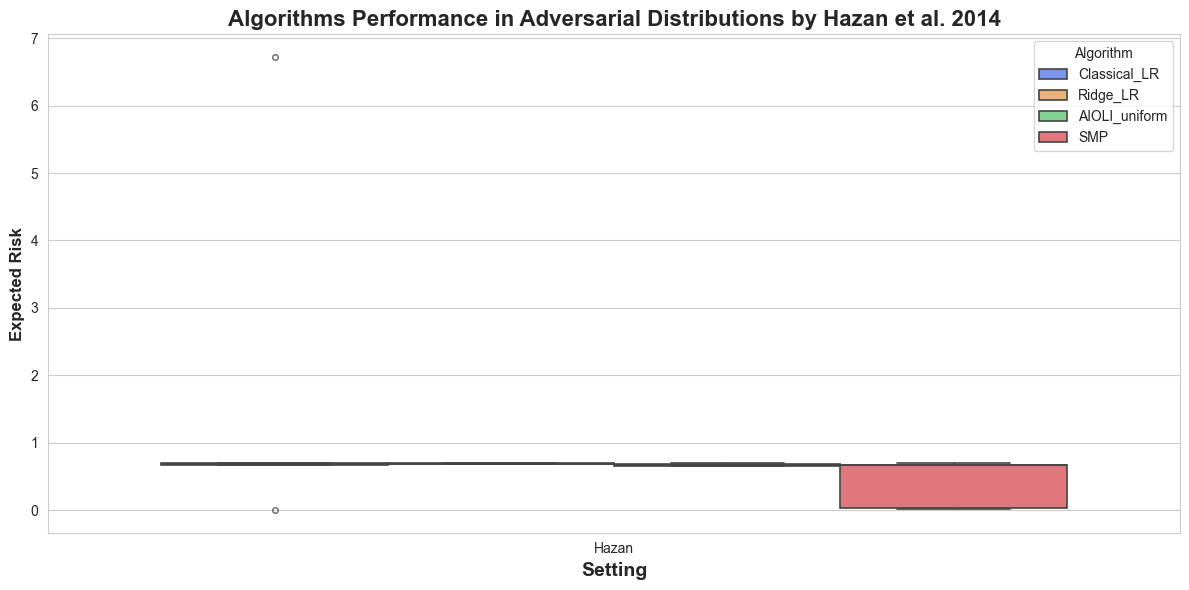

In [495]:

compare_settings(
    settings_results,
    selected_algorithms=["Classical_LR", "SMP", "AIOLI_uniform", "Ridge_LR"], title = "Algorithms Performance in Adversarial Distributions by Hazan et al. 2014"
)

## Balanced

In [521]:
binomial = SimulationConfig(
    sim_setting = "binomial_x",
    n = 100
)

binomial_result = run_simulation(binomial)
print_results(binomial_result)

100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.439
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.41
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.501
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.556
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.427
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the binomial_x balanced setting. Using 1 variable(s), with an average P(Y=1) of 0.47
Lasso LR was fit manually
Run 6 fin

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.686714,0.007740
AIOLI_lastit,0.697125,0.008293
AIOLI_uniform,0.679055,0.006766
AdaGrad_Last_iterate,0.698382,0.008228
AdaGrad_Suffix,0.686141,0.007588
AdaGrad_uniform,0.681030,0.007279
Classical_LR,0.682008,0.006561
Classical_LR_SMOTE,0.713028,0.007827
Lasso_LR,0.683066,0.005817



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.037315,4.116348,4.153663,0.585315
AIOLI_lastit,0.037315,3.663032,3.700347,0.260792
AIOLI_uniform,0.037315,3.935059,3.972374,0.324948
AdaGrad_Last_iterate,0.000828,0.000006,0.000834,0.000130
AdaGrad_Suffix,0.000828,0.000010,0.000837,0.000130
AdaGrad_uniform,0.000828,0.000010,0.000838,0.000130
Classical_LR,0.000831,0.000017,0.000848,0.000034
Classical_LR_SMOTE,0.000680,0.000009,0.000689,0.000065
Lasso_LR,0.001670,0.000008,0.001678,0.000718


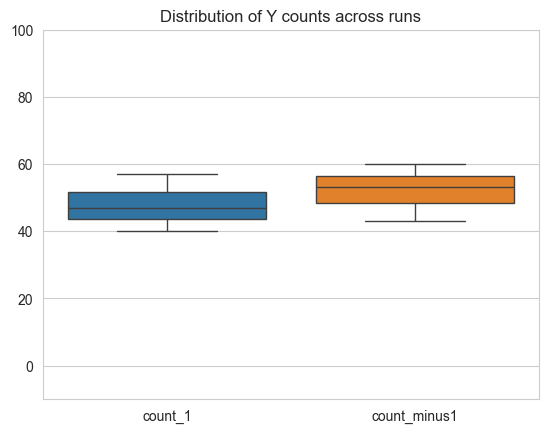

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     58     60     53     48     57     49     45     55     43      53
 1     42     40     47     52     43     51     55     45     57      47
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     56     66     48     35     43     55     49     60     41      58
 1     44     34     52     65     57     45     51     40     59      42


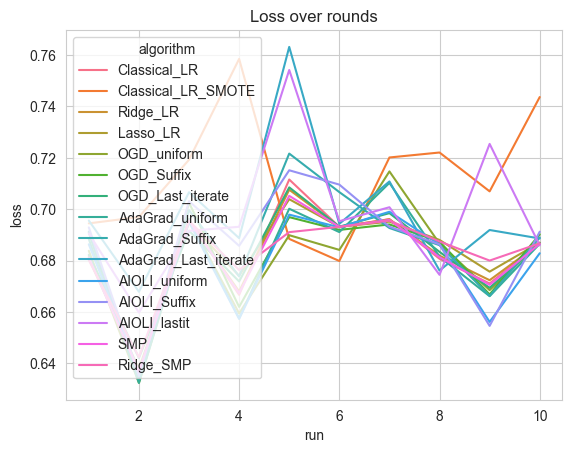

In [497]:
plot_results(binomial_result, n = 100)

In [585]:
sinusoidal = SimulationConfig(
    sim_setting = "sinusoidal",
    n = 100
)

sinusoidal_result = run_simulation(sinusoidal)
print_results(sinusoidal_result)

100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.525
Dataset is balanced
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.524
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.492
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.512
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.507
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the sinusoidal balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495
Lasso LR was 

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.712151,0.009956
AIOLI_lastit,0.741574,0.011642
AIOLI_uniform,0.705175,0.005887
AdaGrad_Last_iterate,0.786558,0.025126
AdaGrad_Suffix,0.706697,0.006465
AdaGrad_uniform,0.699708,0.003194
Classical_LR,0.714488,0.008683
Classical_LR_SMOTE,0.753413,0.011134
Lasso_LR,0.697284,0.003083



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.166764,16.595889,16.762653,0.494594
AIOLI_lastit,0.166764,16.435588,16.602352,0.372247
AIOLI_uniform,0.166764,16.646000,16.812765,0.391389
AdaGrad_Last_iterate,0.000940,0.000006,0.000946,0.000023
AdaGrad_Suffix,0.000940,0.000010,0.000950,0.000022
AdaGrad_uniform,0.000940,0.000011,0.000950,0.000023
Classical_LR,0.001614,0.000023,0.001637,0.000102
Classical_LR_SMOTE,0.001754,0.000015,0.001770,0.000215
Lasso_LR,0.014410,0.000013,0.014424,0.002294


In [498]:
# binomial_d3 = SimulationConfig(
#     sim_setting = "binomial_x",
#     n = 50,
#     runs = 10,
#     d = 3
# )
#
# binomial_d3_result = run_simulation(binomial_d3)
# print_results(binomial_d3_result)

In [499]:
well_specified = SimulationConfig(
    sim_setting = "well specified",
    d = 3
)

well_specified_result = run_simulation(well_specified)
print_results(well_specified_result)

100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.508
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.499
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.498
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.5
Dataset is balanced
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) 

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.696683,0.016159
AIOLI_lastit,0.716951,0.024052
AIOLI_uniform,0.689013,0.009357
AdaGrad_Last_iterate,0.759830,0.041622
AdaGrad_Suffix,0.696609,0.010688
AdaGrad_uniform,0.686510,0.004687
Classical_LR,0.689570,0.012481
Classical_LR_SMOTE,0.723243,0.012109
Lasso_LR,0.690058,0.006120



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.222777,23.117735,23.340512,1.120405
AIOLI_lastit,0.222777,22.051486,22.274263,0.574496
AIOLI_uniform,0.222777,22.849937,23.072714,0.732899
AdaGrad_Last_iterate,0.001302,0.000012,0.001314,0.000076
AdaGrad_Suffix,0.001302,0.000017,0.001320,0.000077
AdaGrad_uniform,0.001302,0.000018,0.001321,0.000077
Classical_LR,0.002302,0.000019,0.002322,0.000186
Classical_LR_SMOTE,0.002743,0.000011,0.002754,0.000254
Lasso_LR,0.015334,0.000010,0.015344,0.001998


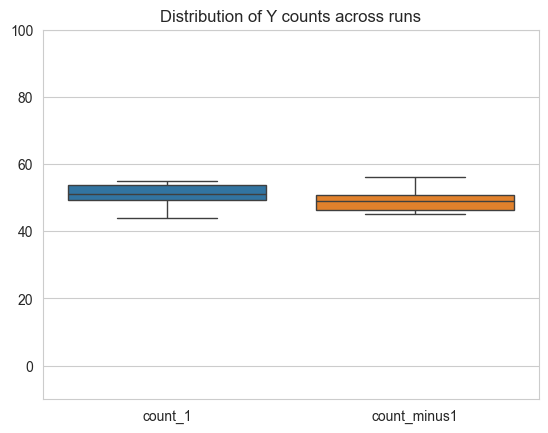

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     47     53     48     51     50     56     45     46     50      46
 1     53     47     52     49     50     44     55     54     50      54
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     45     55     48     51     53     53     50     55     46      53
 1     55     45     52     49     47     47     50     45     54      47


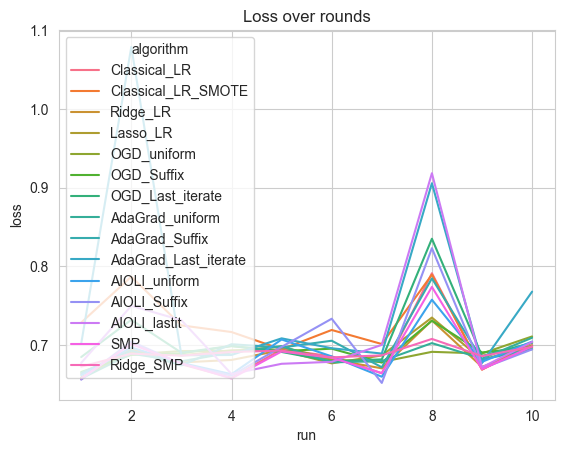

In [500]:
plot_results(well_specified_result)

In [501]:
# well_specified_largebetas = SimulationConfig(
#     sim_betas = [4.4,-0.4,-6.2],
#     sim_setting = "well specified",
#     d = 3,
#     n = 100,
#     runs = 5
# )
#
# well_specified_largebetas_result = run_simulation(well_specified_largebetas)
# print_results(well_specified_largebetas_result)

In [502]:
# plot_results(well_specified_largebetas_result, n = 100)

In [524]:
high_dimensional = SimulationConfig(
    sim_setting = "high dimensional",
    n = 20,
    d = 25,
    runs = 5
)

In [525]:

high_dimensional_result = run_simulation(high_dimensional)
print_results(high_dimensional_result)

20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.505
Lasso LR was fit manually
Run 1 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.507
Lasso LR was fit manually
Run 2 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.517
Lasso LR was fit manually
Run 3 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.572
Dataset is balanced
Lasso LR was fit manually
Run 4 finished
20 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.551
Lasso LR was fit manually
Run 5 finished
Total time: 0:09:41.088145

﷿﷿﷿﷿﷿﷿ Loss Results ﷿﷿﷿﷿﷿﷿


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.633919,9.808622e-03
AIOLI_lastit,0.615739,1.469775e-02
AIOLI_uniform,0.652439,6.797974e-03
AdaGrad_Last_iterate,5.270171,1.189162e+00
AdaGrad_Suffix,2.620757,3.963274e-01
AdaGrad_uniform,3.699796,1.145516e+00
Classical_LR,5.481105,1.401984e+00
Classical_LR_SMOTE,4.321578,6.219145e-01
Lasso_LR,0.667623,1.713552e-02



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.394943,36.344374,36.739317,0.654086
AIOLI_lastit,0.394943,36.764803,37.159746,0.863856
AIOLI_uniform,0.394943,36.666568,37.061511,0.653191
AdaGrad_Last_iterate,0.000860,0.000019,0.000878,0.000063
AdaGrad_Suffix,0.000860,0.000026,0.000886,0.000063
AdaGrad_uniform,0.000860,0.000028,0.000888,0.000062
Classical_LR,0.003271,0.000016,0.003287,0.000223
Classical_LR_SMOTE,0.003763,0.000008,0.003771,0.000133
Lasso_LR,0.086792,0.000007,0.086799,0.010070


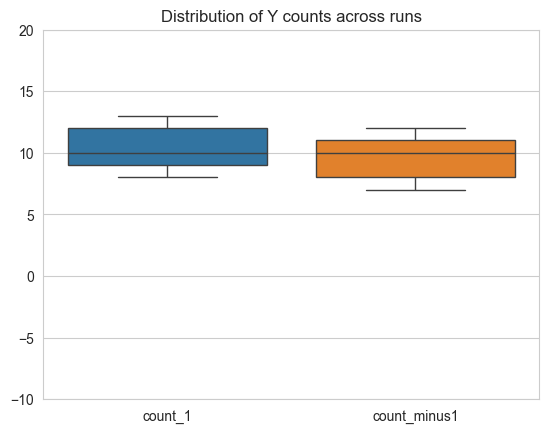

Train set
    run_1  run_2  run_3  run_4  run_5
-1     11      7     12     10      8
 1      9     13      8     10     12
Test set
    run_1  run_2  run_3  run_4  run_5
-1     48     51     47     44     49
 1     52     49     53     56     51


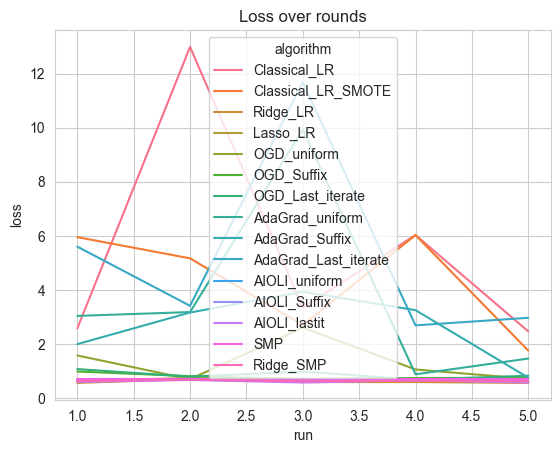

In [509]:
plot_results(high_dimensional_result, n = 20)

In [526]:
high_dimensionality = SimulationConfig(
    sim_setting = "high dimensional",
    runs = 5,
    n = 50,
    d = 25
)

high_dimensionality_result = run_simulation(high_dimensionality)
print_results(high_dimensionality_result)

50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.485
Lasso LR was fit manually
Run 1 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.512
Lasso LR was fit manually
Run 2 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.52
Lasso LR was fit manually
Run 3 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.568
Lasso LR was fit manually
Run 4 finished
50 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.551
Lasso LR was fit manually
Run 5 finished
Total time: 0:58:37.410802

﷿﷿﷿﷿﷿﷿ Loss Results ﷿﷿﷿﷿﷿﷿


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.530637,1.168453e-02
AIOLI_lastit,0.511466,1.161760e-02
AIOLI_uniform,0.571431,9.185553e-03
AdaGrad_Last_iterate,3.261728,4.042582e-01
AdaGrad_Suffix,1.372908,2.197843e-01
AdaGrad_uniform,2.101373,4.979449e-01
Classical_LR,12.417617,3.651207e+00
Classical_LR_SMOTE,22.221306,3.466260e+00
Lasso_LR,0.542904,1.447343e-02



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,2.746901,236.545233,239.292134,23.804291
AIOLI_lastit,2.746901,214.006774,216.753675,12.817643
AIOLI_uniform,2.746901,242.027108,244.774009,34.384249
AdaGrad_Last_iterate,0.003155,0.000018,0.003172,0.000576
AdaGrad_Suffix,0.003155,0.000028,0.003182,0.000578
AdaGrad_uniform,0.003155,0.000029,0.003184,0.000578
Classical_LR,0.117323,0.000023,0.117346,0.080084
Classical_LR_SMOTE,0.007457,0.000012,0.007469,0.001059
Lasso_LR,0.367393,0.000011,0.367404,0.128507


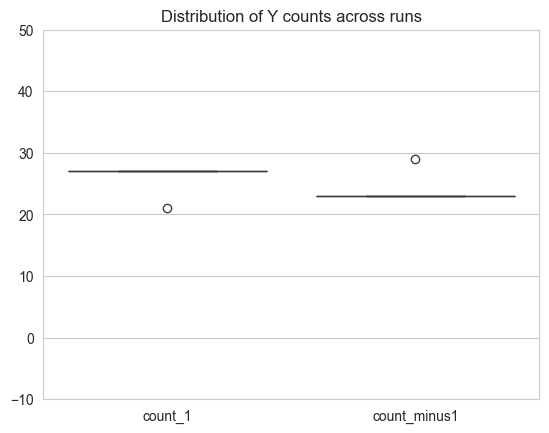

Train set
    run_1  run_2  run_3  run_4  run_5
-1     29     23     23     23     23
 1     21     27     27     27     27
Test set
    run_1  run_2  run_3  run_4  run_5
-1     48     51     47     44     49
 1     52     49     53     56     51


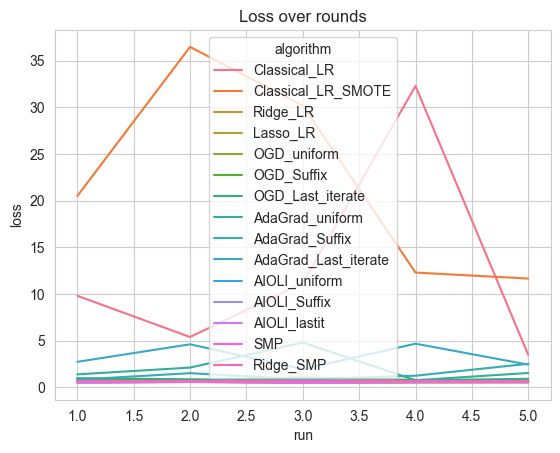

In [527]:
plot_results(high_dimensionality_result, n = 50)

In [ ]:
high_dimensionality_higher_n = SimulationConfig(
    sim_setting = "high dimensional",
    runs = 5,
    n = 100,
    d = 25
)

high_dimensionality_higher_n_result = run_simulation(high_dimensionality_higher_n)
print_results(high_dimensionality_higher_n_result)

In [ ]:
# sinusoidal = SimulationConfig(
#     sim_setting = "sinusoidal",
#     n = 100,
#     d = 3
# )
#
# sinusoidal_result = run_simulation(sinusoidal)
# print_results(sinusoidal_result)

In [ ]:
# plot_results(sinusoidal_result)

In [510]:
quadratic = SimulationConfig(
    sim_setting = "quadratic",
    d = 3
)

quadratic_result = run_simulation(quadratic)
print_results(quadratic_result)

100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.051
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.052
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.054
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.048
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.045
Dataset is balanced
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the quadratic balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.047
Lasso LR was fit ma

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.599840,0.013868
AIOLI_lastit,0.617708,0.012640
AIOLI_uniform,0.590069,0.013837
AdaGrad_Last_iterate,0.670807,0.032065
AdaGrad_Suffix,0.642617,0.015829
AdaGrad_uniform,0.648131,0.010323
Classical_LR,0.582623,0.012773
Classical_LR_SMOTE,0.597758,0.014649
Lasso_LR,0.595187,0.015368



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.188251,18.570325,18.758576,0.646968
AIOLI_lastit,0.188251,18.189576,18.377827,0.560521
AIOLI_uniform,0.188251,18.360344,18.548595,0.624672
AdaGrad_Last_iterate,0.000892,0.000011,0.000903,0.000004
AdaGrad_Suffix,0.000892,0.000020,0.000912,0.000005
AdaGrad_uniform,0.000892,0.000018,0.000910,0.000004
Classical_LR,0.001889,0.000016,0.001905,0.000250
Classical_LR_SMOTE,0.001846,0.000009,0.001855,0.000251
Lasso_LR,0.007407,0.000008,0.007415,0.002247


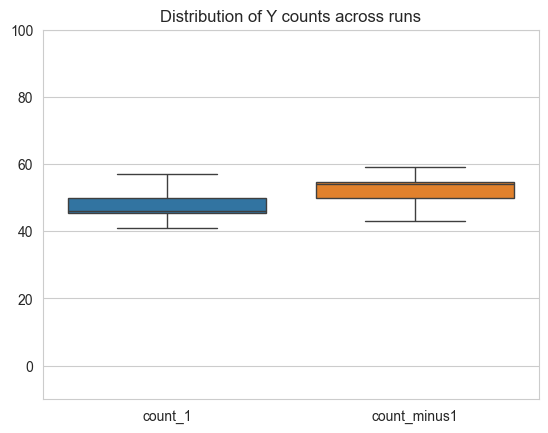

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     54     54     54     57     50     59     43     49     55      50
 1     46     46     46     43     50     41     57     51     45      50
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     48     61     49     52     59     51     51     57     51      57
 1     52     39     51     48     41     49     49     43     49      43


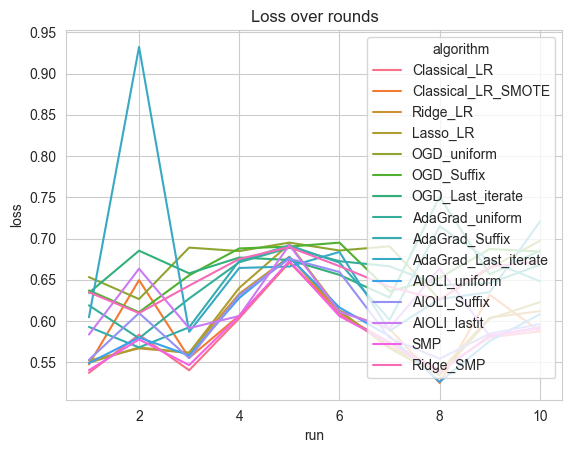

In [511]:
plot_results(quadratic_result)

In [583]:
settings_results1 = {
    # "Well specified": well_specified_result,
    "High Dimensional": high_dimensional_result,
    "High Dimensionality": high_dimensionality_result,
    # "Quadratic": quadratic_result,
    # "Binomial X": binomial_result
}
settings_results = {
    "Well specified": well_specified_result,
    # "High Dimensional": high_dimensional_result,
    # "High Dimensionality": high_dimensionality_result,
    "Quadratic": quadratic_result,
    "Binomial X": binomial_result
}

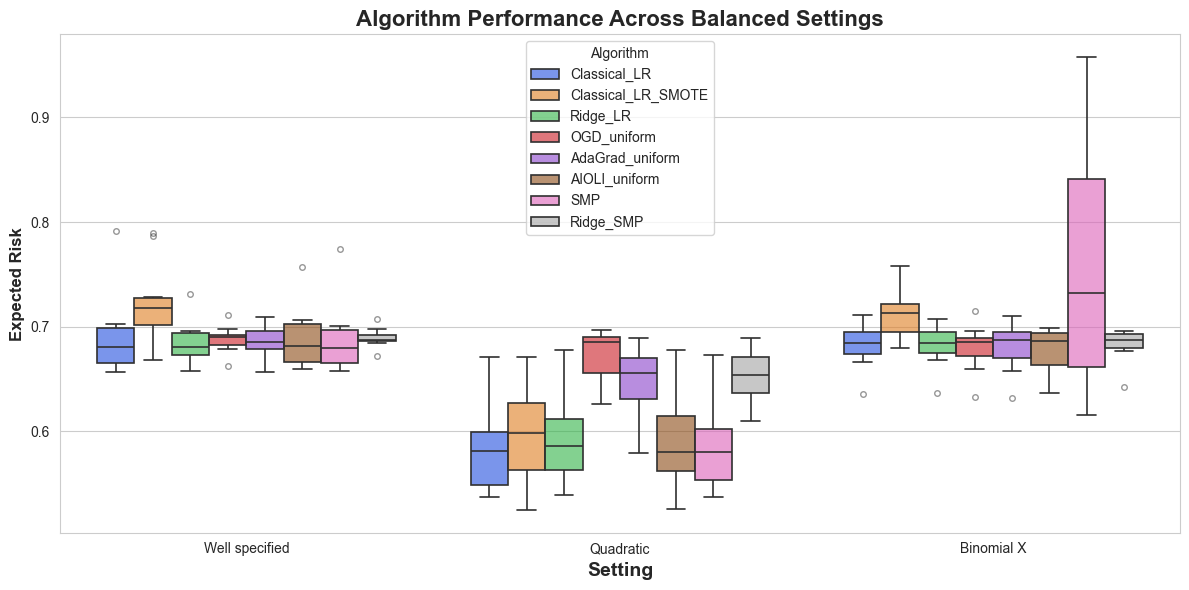

In [529]:
compare_settings(
    settings_results, selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"]
)

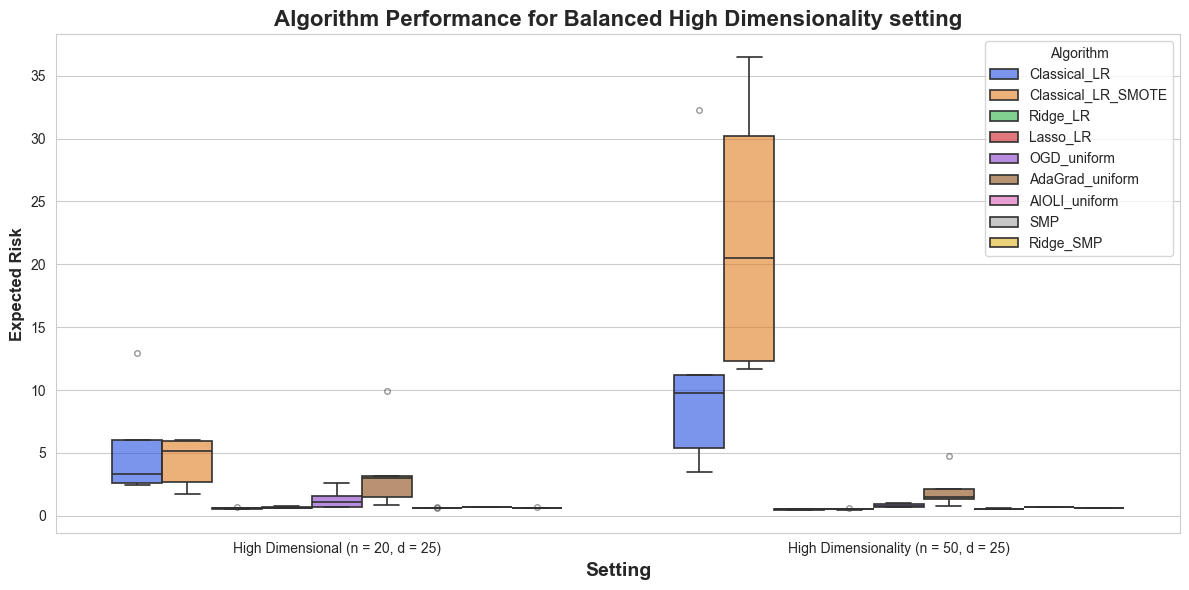

In [584]:
compare_settings(
    settings_results1,
    title = "Algorithm Performance for Balanced High Dimensionality setting", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","Lasso_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"],
    x_labels={"High Dimensional": "High Dimensional (n = 20, d = 25)", "High Dimensionality": "High Dimensionality (n = 50, d = 25)"}
)

In [531]:
# FOR AVERAGING STRATEGIES PART

settings_results_HD = {
    # "Well specified": well_specified_result,
    "High Dimensional": high_dimensional_result,
    "High Dimensionality": high_dimensionality_result,
    # "Quadratic": quadratic_result,
    # "Binomial X": binomial_result
}

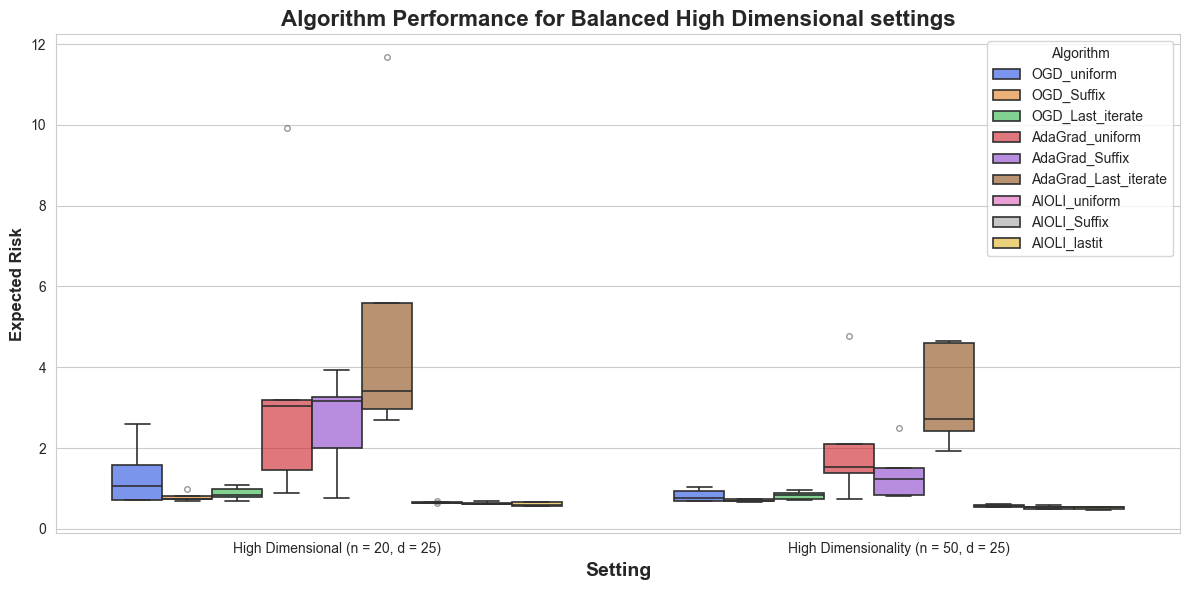

In [532]:
compare_settings(
    settings_results_HD,
    title = "Algorithm Performance for Balanced High Dimensional settings", selected_algorithms= [ "OGD_uniform","AdaGrad_uniform","AIOLI_uniform",
                                                                                                     "OGD_Suffix","OGD_Last_iterate","AdaGrad_Suffix","AdaGrad_Last_iterate",
                                                                                                     "AIOLI_Suffix","AIOLI_lastit"],
    x_labels={"High Dimensional": "High Dimensional (n = 20, d = 25)", "High Dimensionality": "High Dimensionality (n = 50, d = 25)"}
)

In [ ]:
highly_correlated_x = SimulationConfig(
    sim_setting = "highly correlated x",
    n = 100,
    d = 3
)

highly_correlated_x_result = run_simulation(highly_correlated_x)
print_results(highly_correlated_x_result)

In [535]:
alternating = SimulationConfig(
    sim_setting = "alternating",
    n = 100,
    d = 3,
    runs = 5
)

alternating_result = run_simulation(alternating)
print_results(alternating_result)

100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.475
Dataset is balanced
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.465
Dataset is balanced
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.451
Dataset is balanced
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.444
Dataset is balanced
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the alternating balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.46
Dataset is balanced
Lasso LR was fit manually
Run 5 finished
Total time: 0:03:47.902666

﷿﷿﷿﷿﷿﷿ Loss Results ﷿﷿﷿﷿﷿﷿


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.703129,0.004699
AIOLI_lastit,0.722580,0.011094
AIOLI_uniform,0.705414,0.007158
AdaGrad_Last_iterate,0.712454,0.005725
AdaGrad_Suffix,0.698079,0.002558
AdaGrad_uniform,0.698124,0.001970
Classical_LR,0.705923,0.005915
Classical_LR_SMOTE,0.705923,0.005915
Lasso_LR,0.696235,0.001999



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.192734,14.732840,14.925574,0.199255
AIOLI_lastit,0.192734,14.680385,14.873119,0.177429
AIOLI_uniform,0.192734,15.329369,15.522103,0.228428
AdaGrad_Last_iterate,0.001271,0.000011,0.001282,0.000268
AdaGrad_Suffix,0.001271,0.000018,0.001289,0.000268
AdaGrad_uniform,0.001271,0.000018,0.001289,0.000268
Classical_LR,0.001805,0.000021,0.001826,0.000472
Classical_LR_SMOTE,0.001661,0.000014,0.001675,0.000238
Lasso_LR,0.014272,0.000012,0.014284,0.003151


In [746]:
sign = SimulationConfig(
    sim_setting = "sign",
    n = 100,
    d = 3,
    runs = 10
)

sign_result = run_simulation(sign)
print_results(sign_result)

100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.525
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.495
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.49
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.515
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.48
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the sign balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.53
Lasso LR was fit manually
Run 6 finished
100 (training) samples were gen

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.115408,0.003836
AIOLI_lastit,0.099936,0.003169
AIOLI_uniform,0.140221,0.003851
AdaGrad_Last_iterate,0.178428,0.011094
AdaGrad_Suffix,0.185515,0.007512
AdaGrad_uniform,0.223366,0.011838
Classical_LR,0.063894,0.031222
Classical_LR_SMOTE,0.081225,0.035865
Lasso_LR,0.123013,0.005614



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.290010,29.198949,29.488959,2.837967
AIOLI_lastit,0.290010,27.692228,27.982238,2.383241
AIOLI_uniform,0.290010,30.388767,30.678777,3.140042
AdaGrad_Last_iterate,0.002306,0.000016,0.002321,0.000409
AdaGrad_Suffix,0.002306,0.000024,0.002330,0.000409
AdaGrad_uniform,0.002306,0.000025,0.002331,0.000409
Classical_LR,0.004826,0.000025,0.004851,0.000605
Classical_LR_SMOTE,0.005030,0.000017,0.005047,0.000731
Lasso_LR,0.007568,0.000017,0.007584,0.001381


In [747]:
hidden_x = SimulationConfig(
    sim_setting = "hidden x",
    n = 100,
    d = 3,
    runs = 10
)

hidden_x_result = run_simulation(hidden_x)
print_results(hidden_x_result)

100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.481
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.501
Dataset is balanced
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.506
Dataset is balanced
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.543
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.544
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the hidden x balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.489
Datas

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.655297,0.011509
AIOLI_lastit,0.657596,0.012773
AIOLI_uniform,0.650672,0.013204
AdaGrad_Last_iterate,0.673462,0.022987
AdaGrad_Suffix,0.665278,0.014966
AdaGrad_uniform,0.663559,0.013549
Classical_LR,0.644124,0.012883
Classical_LR_SMOTE,0.647764,0.017184
Lasso_LR,0.651791,0.013003



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.380090,38.559867,38.939958,3.366906
AIOLI_lastit,0.380090,37.358370,37.738461,4.036302
AIOLI_uniform,0.380090,36.980359,37.360449,3.588752
AdaGrad_Last_iterate,0.002247,0.000024,0.002271,0.000426
AdaGrad_Suffix,0.002247,0.000034,0.002282,0.000426
AdaGrad_uniform,0.002247,0.000035,0.002283,0.000426
Classical_LR,0.003752,0.000034,0.003786,0.000871
Classical_LR_SMOTE,0.003365,0.000020,0.003385,0.000445
Lasso_LR,0.020003,0.000018,0.020020,0.008040


## Unbalanced

### Experiments

In [ ]:
1 - (0.002 + 0.002)

In [512]:
binomial_unbalanced = SimulationConfig(
    sim_setting = "binomial_x",
    n = 100,
    d = 1,
    sim_balanced= False
)

binomial_unbalanced_result = run_simulation(binomial_unbalanced)
print_results(binomial_unbalanced_result)

100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.991
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.993
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.988
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.989
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 4 finished
100 (training) samples were generated in the binomial_x unbalanced setting. Using 1 variable(s), with an average P(Y=1) of 0.993
Dataset only has one class
Logistic regression was fit manually


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.060118,0.023833
AIOLI_lastit,0.061717,0.024755
AIOLI_uniform,0.059982,0.021522
AdaGrad_Last_iterate,0.073047,0.031114
AdaGrad_Suffix,0.067090,0.030171
AdaGrad_uniform,0.066091,0.029104
Classical_LR,0.161903,0.105142
Classical_LR_SMOTE,0.165583,0.104546
Lasso_LR,0.061058,0.024184



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.085797,7.744309,7.830106,0.305673
AIOLI_lastit,0.085797,8.285131,8.370928,0.519957
AIOLI_uniform,0.085797,7.427321,7.513118,0.295343
AdaGrad_Last_iterate,0.000902,0.000009,0.000911,0.000165
AdaGrad_Suffix,0.000902,0.000017,0.000919,0.000166
AdaGrad_uniform,0.000902,0.000014,0.000916,0.000166
Classical_LR,0.002030,0.000020,0.002050,0.000465
Classical_LR_SMOTE,0.001681,0.000013,0.001693,0.000285
Lasso_LR,0.001615,0.000011,0.001626,0.000215


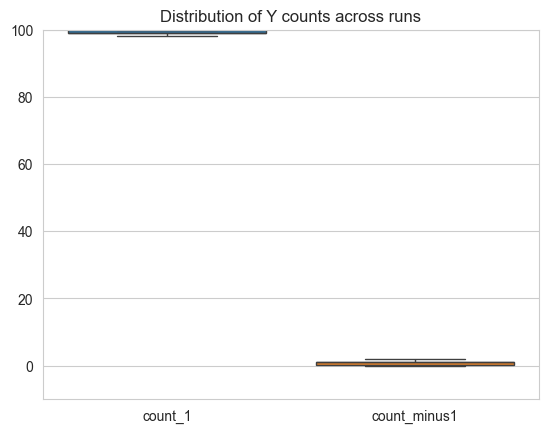

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1      1      1      1    NaN    NaN      1      1      2    NaN       1
 1     99     99     99  100.0  100.0     99     99     98  100.0      99
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1    NaN    NaN    NaN      5      1    NaN      1      2    NaN       2
 1  100.0  100.0  100.0     95     99  100.0     99     98  100.0      98


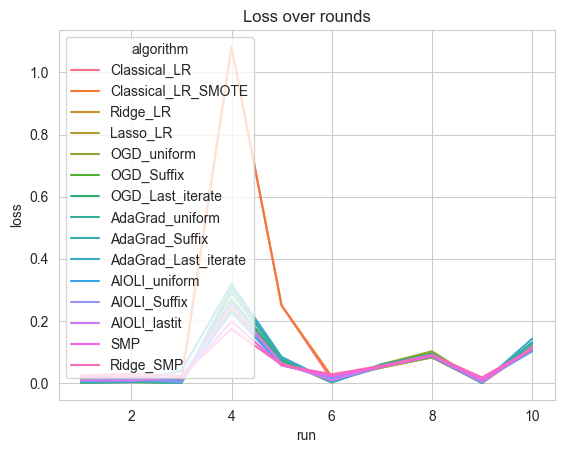

In [513]:
plot_results(binomial_unbalanced_result, n = 100)

In [514]:
well_specified_unbalanced = SimulationConfig(
    sim_setting = "well specified",
    sim_balanced= False
)

well_specified_unbalanced_result = run_simulation(well_specified_unbalanced)
print_results(well_specified_unbalanced_result)

100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.971
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.984
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.978
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.989
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 4 finished
100 (training) samples were generated in the well specified unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.986
Lasso LR was fit manually
Run 5 finished
100

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.077875,0.009648
AIOLI_lastit,0.091397,0.015057
AIOLI_uniform,0.078482,0.008627
AdaGrad_Last_iterate,0.109060,0.026493
AdaGrad_Suffix,0.086616,0.012773
AdaGrad_uniform,0.084980,0.013630
Classical_LR,0.116953,0.030557
Classical_LR_SMOTE,0.135626,0.031125
Lasso_LR,0.080626,0.009450



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.277677,26.071401,26.349077,0.754047
AIOLI_lastit,0.277677,28.009060,28.286737,0.892357
AIOLI_uniform,0.277677,27.404512,27.682189,0.827646
AdaGrad_Last_iterate,0.001360,0.000034,0.001394,0.000197
AdaGrad_Suffix,0.001360,0.000018,0.001378,0.000196
AdaGrad_uniform,0.001360,0.000018,0.001379,0.000196
Classical_LR,0.003276,0.000022,0.003298,0.000582
Classical_LR_SMOTE,0.002983,0.000013,0.002997,0.000422
Lasso_LR,0.017798,0.000012,0.017809,0.002384


In [515]:
well_specified_unbalanced_result["test_results"]

,run,algorithm,loss
0,1,Classical_LR,0.105162
1,1,Classical_LR_SMOTE,0.138476
2,1,Ridge_LR,0.111680
3,1,Lasso_LR,0.111634
4,1,OGD_uniform,0.103309
...,...,...,...
145,10,AIOLI_uniform,0.049677
146,10,AIOLI_Suffix,0.048105
147,10,AIOLI_lastit,0.045204
148,10,SMP,0.110712


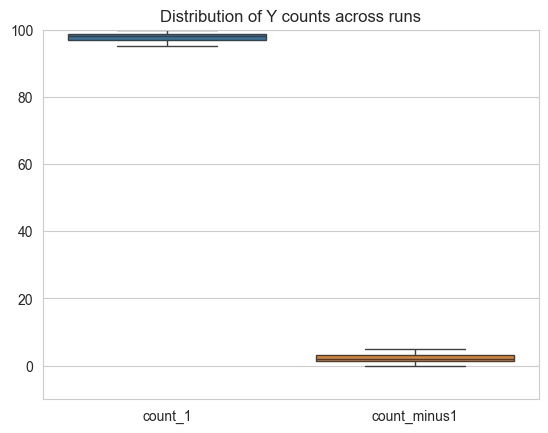

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1      5      1      4    NaN      2      3      2      2      3       1
 1     95     99     96  100.0     98     97     98     98     97      99
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1      2      2      1      2      2      1    NaN      2      3       1
 1     98     98     99     98     98     99  100.0     98     97      99


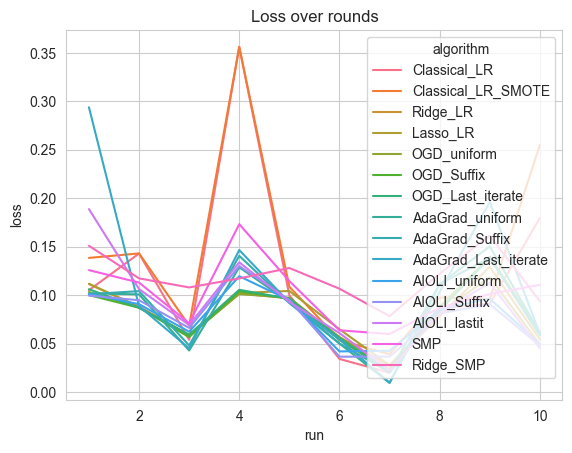

In [516]:
plot_results(well_specified_unbalanced_result)

In [ ]:
well_specified_unbalanced_result["test_results"]

In [749]:
high_dimensional_unbalanced = SimulationConfig(
    sim_setting = "high dimensional",
    n = 20,
    d = 25,
    runs = 20,
    sim_balanced= False
)

high_dimensional_unbalanced_result = run_simulation(high_dimensional_unbalanced)
print_results(high_dimensional_unbalanced_result)


20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.902
Lasso LR was fit manually
Run 1 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.913
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.866
Lasso LR was fit manually
Run 3 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.912
Lasso LR was fit manually
Run 4 finished
20 (training) samples were generated in the high dimensional unbalanced setting. Using 25 variable(s), with an average P(Y=1) of 0.931
Lasso LR was fit manually
Run 5 fi

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.403916,1.855017e-02
AIOLI_lastit,0.382067,1.859261e-02
AIOLI_uniform,0.443578,1.614157e-02
AdaGrad_Last_iterate,2.029859,7.211732e-01
AdaGrad_Suffix,2.519581,7.601970e-01
AdaGrad_uniform,2.785873,7.087447e-01
Classical_LR,1.376719,2.821600e-01
Classical_LR_SMOTE,1.549950,5.003367e-01
Lasso_LR,0.325011,3.939984e-02



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.408814,37.642174,38.050988,0.805799
AIOLI_lastit,0.408814,37.893483,38.302297,0.829259
AIOLI_uniform,0.408814,38.382964,38.791778,0.816191
AdaGrad_Last_iterate,0.000886,0.000010,0.000896,0.000191
AdaGrad_Suffix,0.000886,0.000016,0.000903,0.000191
AdaGrad_uniform,0.000886,0.000016,0.000902,0.000191
Classical_LR,0.003511,0.000016,0.003527,0.000596
Classical_LR_SMOTE,0.005067,0.000010,0.005077,0.000600
Lasso_LR,0.126795,0.000009,0.126804,0.011560


In [753]:
print_results(high_dimensional_unbalanced_result)

Total time: 0:40:01.779393

﷿﷿﷿﷿﷿﷿ Loss Results ﷿﷿﷿﷿﷿﷿


,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.4039164779,0.0185501714
AIOLI_lastit,0.3820674343,0.0185926115
AIOLI_uniform,0.4435781287,0.0161415663
AdaGrad_Last_iterate,2.0298587951,0.7211732301
AdaGrad_Suffix,2.5195813312,0.7601970175
AdaGrad_uniform,2.7858734099,0.7087447181
Classical_LR,1.3767192034,0.2821599564
Classical_LR_SMOTE,1.5499501480,0.5003366931
Lasso_LR,0.3250113497,0.0393998385



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.4088140500,37.6421740000,38.0509880500,0.8057993674
AIOLI_lastit,0.4088140500,37.8934832500,38.3022973000,0.8292587648
AIOLI_uniform,0.4088140500,38.3829643500,38.7917784000,0.8161907352
AdaGrad_Last_iterate,0.0008864500,0.0000098500,0.0008963000,0.0001913162
AdaGrad_Suffix,0.0008864500,0.0000164000,0.0009028500,0.0001910808
AdaGrad_uniform,0.0008864500,0.0000158500,0.0009023000,0.0001911076
Classical_LR,0.0035107000,0.0000158500,0.0035265500,0.0005955676
Classical_LR_SMOTE,0.0050669000,0.0000101000,0.0050770000,0.0006001653
Lasso_LR,0.1267953500,0.0000090000,0.1268043500,0.0115598468


In [ ]:
plot_results(high_dimensional_unbalanced_result, n = 20)

In [ ]:
high_dimensionality_unbalanced = SimulationConfig(
    sim_setting = "high dimensional",
    runs = 20,
    n = 50,
    d = 25,
    sim_balanced = False
)

high_dimensionality_unbalanced_result = run_simulation(high_dimensionality_unbalanced)
print_results(high_dimensionality_unbalanced_result)


In [ ]:
plot_results(high_dimensionality_unbalanced_result, n =50)

In [ ]:
# sinusoidal_unbalanced = SimulationConfig(
#     sim_setting = "sinusoidal",
#     n = 100,
#     d = 3,
#     sim_balanced=False
# )
#
# sinusoidal_unbalanced_result = run_simulation(sinusoidal_unbalanced)
# print_results(sinusoidal_unbalanced_result)

In [ ]:
# plot_results(sinusoidal_unbalanced_result, n = 100)

In [586]:
quadratic_unbalanced = SimulationConfig(
    sim_setting = "quadratic",
    d = 3,
    sim_balanced= False
)

quadratic_unbalanced_result = run_simulation(quadratic_unbalanced)
print_results(quadratic_unbalanced_result)

100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.876
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.88
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.872
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.884
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the quadratic unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.884
Lasso LR was fit manually
Run 5 finished
100 (training) samples were g

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.120135,0.017662
AIOLI_lastit,0.118600,0.016745
AIOLI_uniform,0.119486,0.017050
AdaGrad_Last_iterate,0.153529,0.026209
AdaGrad_Suffix,0.137888,0.022052
AdaGrad_uniform,0.138378,0.022220
Classical_LR,0.227978,0.079289
Classical_LR_SMOTE,0.254714,0.083687
Lasso_LR,0.114784,0.014666



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.262476,23.812551,24.075027,0.231193
AIOLI_lastit,0.262476,24.315900,24.578375,0.659675
AIOLI_uniform,0.262476,24.347083,24.609559,0.315041
AdaGrad_Last_iterate,0.001161,0.000008,0.001169,0.000225
AdaGrad_Suffix,0.001161,0.000013,0.001174,0.000224
AdaGrad_uniform,0.001161,0.000015,0.001176,0.000224
Classical_LR,0.002707,0.000019,0.002726,0.000344
Classical_LR_SMOTE,0.002866,0.000013,0.002878,0.000137
Lasso_LR,0.019420,0.000011,0.019430,0.001416


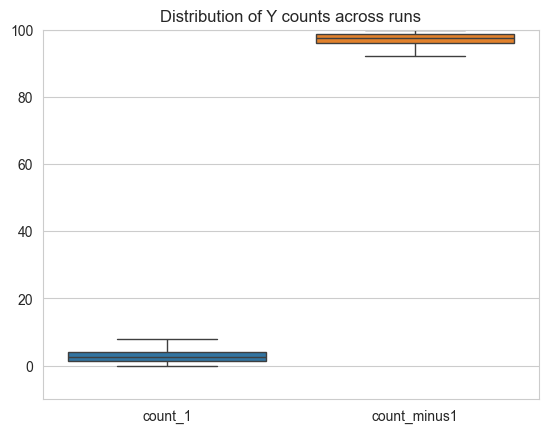

Train set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1  100.0     92     99     98     97     98     99     96     94      96
 1    NaN      8      1      2      3      2      1      4      6       4
Test set
    run_1  run_2  run_3  run_4  run_5  run_6  run_7  run_8  run_9  run_10
-1     95     98     97     96  100.0     98     99     98     95      97
 1      5      2      3      4    NaN      2      1      2      5       3


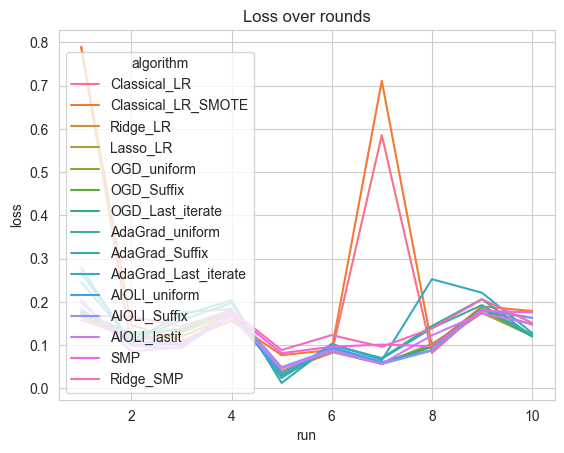

In [587]:
plot_results(quadratic_unbalanced_result)

In [745]:
sign_unbalanced = SimulationConfig(
    sim_setting = "sign",
    n = 100,
    d = 3,
    runs = 10,
    sim_balanced = False
)

sign_unbalanced_result = run_simulation(sign_unbalanced)
print_results(sign_unbalanced_result)

100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.975
Lasso LR was fit manually
Run 1 finished
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.98
Lasso LR was fit manually
Run 2 finished
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.975
Lasso LR was fit manually
Run 3 finished
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.975
Lasso LR was fit manually
Run 4 finished
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.975
Lasso LR was fit manually
Run 5 finished
100 (training) samples were generated in the sign unbalanced setting. Using 3 variable(s), with an average P(Y=1) of 0.975
Lasso LR was fit manually
Run 6 finished
100 (training) sa

,Average_Loss,SE_Loss
algorithm,,
AIOLI_Suffix,0.070669,0.009034
AIOLI_lastit,0.066428,0.008632
AIOLI_uniform,0.084125,0.009294
AdaGrad_Last_iterate,0.094060,0.018013
AdaGrad_Suffix,0.101303,0.018457
AdaGrad_uniform,0.101264,0.014129
Classical_LR,0.163217,0.097436
Classical_LR_SMOTE,0.139548,0.087645
Lasso_LR,0.069645,0.007584



﷿﷿﷿﷿﷿﷿ Time Results (seconds) ﷿﷿﷿﷿﷿﷿


,Avg_Time_Fit,Avg_Time_Loss,Avg_Time_Total,SE_Time_Total
algorithm,,,,
AIOLI_Suffix,0.228167,21.332205,21.560371,1.669574
AIOLI_lastit,0.228167,19.399173,19.627340,0.553283
AIOLI_uniform,0.228167,22.380115,22.608281,2.159202
AdaGrad_Last_iterate,0.001067,0.000009,0.001076,0.000128
AdaGrad_Suffix,0.001067,0.000013,0.001080,0.000129
AdaGrad_uniform,0.001067,0.000015,0.001081,0.000129
Classical_LR,0.002952,0.000020,0.002973,0.000247
Classical_LR_SMOTE,0.003474,0.000014,0.003488,0.000441
Lasso_LR,0.022601,0.000014,0.022615,0.005595


In [ ]:
settings_unbalanced_results = {
    "Well specified": well_specified_unbalanced_result,
    # "High Dimensional": high_dimensional_unbalanced_result,
    # "High Dimensionality": high_dimensionality_unbalanced_result,
    "Quadratic": quadratic_unbalanced_result,
    "Binomial X": binomial_unbalanced_result
}

settings_unbalanced_results1 = {
    # "Well specified": well_specified_unbalanced_result,
    "High Dimensional": high_dimensional_unbalanced_result,
    "High Dimensionality": high_dimensionality_unbalanced_result,
    # "Quadratic": quadratic_unbalanced_result,
    # "Binomial X": binomial_unbalanced_result
}

In [ ]:
compare_settings(
    settings_unbalanced_results,
    title = "Algorithm Performance Across Unbalanced Settings", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Lasso_LR","Ridge_LR","OGD_uniform","AIOLI_uniform","SMP","Ridge_SMP", "AdaGrad_uniform"]
)

In [ ]:
compare_settings(
    settings_unbalanced_results1,
    title = "Algorithm Performance for Unbalanced High Dimensionality setting", selected_algorithms= [ "Classical_LR", "Classical_LR_SMOTE","Ridge_LR","Lasso_LR","OGD_uniform","AdaGrad_uniform","AIOLI_uniform","SMP","Ridge_SMP"],
    x_labels={"High Dimensional": "High Dimensional (n = 20, d = 25)", "High Dimensionality": "High Dimensionality (n = 50, d = 25)"}
)

## Changing n

In [571]:
hazan_small_n = simulations_changing_n([10,20,60], hazan, filename = "hazan_small_n")

Running simulations for n = 10

10 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.012764652829240164
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
10 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.012764652829240164
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
10 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.012764652829240164
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually


KeyboardInterrupt: 

In [ ]:
hazan_small_n[1]

In [ ]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP", "Ridge_LR","OGD_uniform","AdaGrad_uniform", "Classical_LR"] ,raw_data= hazan_small_n[1])

In [690]:
hazan_changing_n_new = simulations_changing_n([20,100,150], hazan, filename = "hazan_changing_n")

Running simulations for n = 20

20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.030000000000000002
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 1 finished
20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.030000000000000002
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 2 finished
20 (training) samples were generated using the 1-dimensional setting described by Hazan et al. (2014). With an average P(Y=1) of 0.030000000000000002
Dataset only has one class
Logistic regression was fit manually
Ridge LR was fit manually
Lasso LR was fit manually
Logistic regression was fit manually
Run 3 finished
20 (training) 

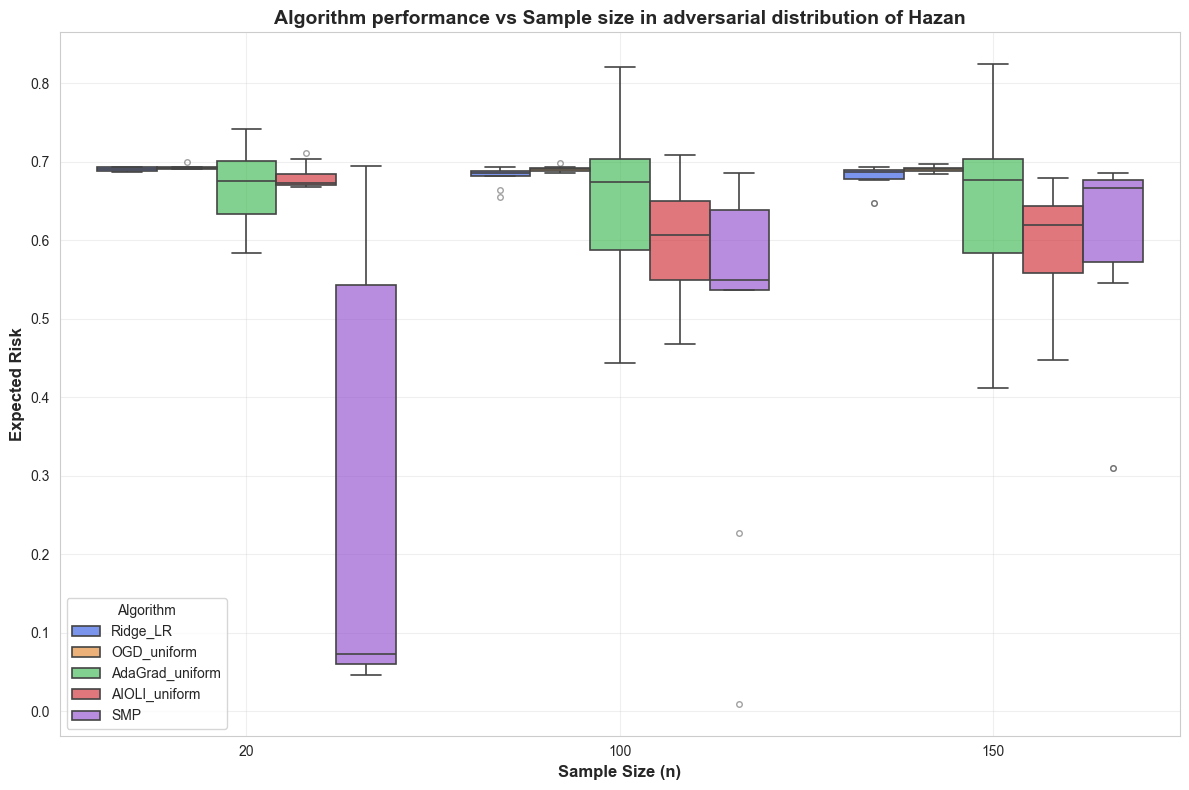

In [692]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP", "Ridge_LR","OGD_uniform","AdaGrad_uniform"] ,raw_data= hazan_changing_n_new[1], title= "Algorithm performance vs Sample size in adversarial distribution of Hazan")

In [574]:
hazan_changing_n_new[0]

,n,algorithm,avg_loss,std_loss,num_runs
0,20,AIOLI_Suffix,0.686819,0.000823,10
1,20,AIOLI_lastit,0.684891,0.001094,10
2,20,AIOLI_uniform,0.688985,0.000530,10
3,20,AdaGrad_Last_iterate,0.658011,0.048922,10
4,20,AdaGrad_Suffix,0.662262,0.040855,10
5,20,AdaGrad_uniform,0.669240,0.028276,10
6,20,Classical_LR,3.047576,3.551446,10
7,20,Classical_LR_SMOTE,3.047576,3.551446,10
8,20,Lasso_LR,0.693147,0.000000,10
9,20,OGD_Last_iterate,0.692581,0.000277,10


In [578]:
df = hazan_changing_n_new[0]

df["se_loss"] = df["std_loss"] / 10
df = df.drop(columns=["std_loss","num_runs"])

df


,n,algorithm,avg_loss,se_loss
0,20,AIOLI_Suffix,0.686819,0.000082
1,20,AIOLI_lastit,0.684891,0.000109
2,20,AIOLI_uniform,0.688985,0.000053
3,20,AdaGrad_Last_iterate,0.658011,0.004892
4,20,AdaGrad_Suffix,0.662262,0.004086
5,20,AdaGrad_uniform,0.669240,0.002828
6,20,Classical_LR,3.047576,0.355145
7,20,Classical_LR_SMOTE,3.047576,0.355145
8,20,Lasso_LR,0.693147,0.000000
9,20,OGD_Last_iterate,0.692581,0.000028


In [ ]:
hazan_changing_n = simulations_changing_n([20,100,200,300], hazan, filename = "hazan_changing_n")


In [ ]:
hazan_changing_n[1]

In [ ]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP", "Ridge_LR","OGD_uniform","AdaGrad_uniform"] ,raw_data= hazan_changing_n[1])

In [ ]:
hazan_changing_n[0]

In [ ]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP", "Ridge_LR","OGD_uniform","AdaGrad_uniform", "Classical_LR"] ,raw_data= hazan_changing_n[1])

In [ ]:
high_dimensional_changing_n = simulations_changing_n([10,30,50,100], high_dimensional, filename = "high_dimensional_changing_n")

In [ ]:
# high_dimensional_changing_n

In [ ]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR","AdaGrad_uniform","OGD_uniform", "Classical_LR"] ,raw_data= high_dimensional_changing_n[1])

In [ ]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR"] ,raw_data= high_dimensional_changing_n[1])

In [ ]:
high_dimensional_changing_n[1]

# RUN HERE

In [395]:
high_dimensional_large_n = SimulationConfig(
    sim_setting = "high dimensional",
    n = 20,
    d = 25,
    runs = 10
)

In [396]:
high_dimensional_large_n = simulations_changing_n([150,200], high_dimensional_large_n, filename = "high_dimensional_large_n")

Running simulations for n = 150

150 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.481
Lasso LR was fit manually
Run 1 finished
150 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.489
Lasso LR was fit manually
Run 2 finished
150 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.507
Lasso LR was fit manually
Run 3 finished
150 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.537
Lasso LR was fit manually
Run 4 finished
150 (training) samples were generated in the high dimensional balanced setting. Using 25 variable(s), with an average P(Y=1) of 0.546
Lasso LR was fit manually
Run 5 finished
150 (training) samples were generated in the high dimensional balanced setting. Using 25 var

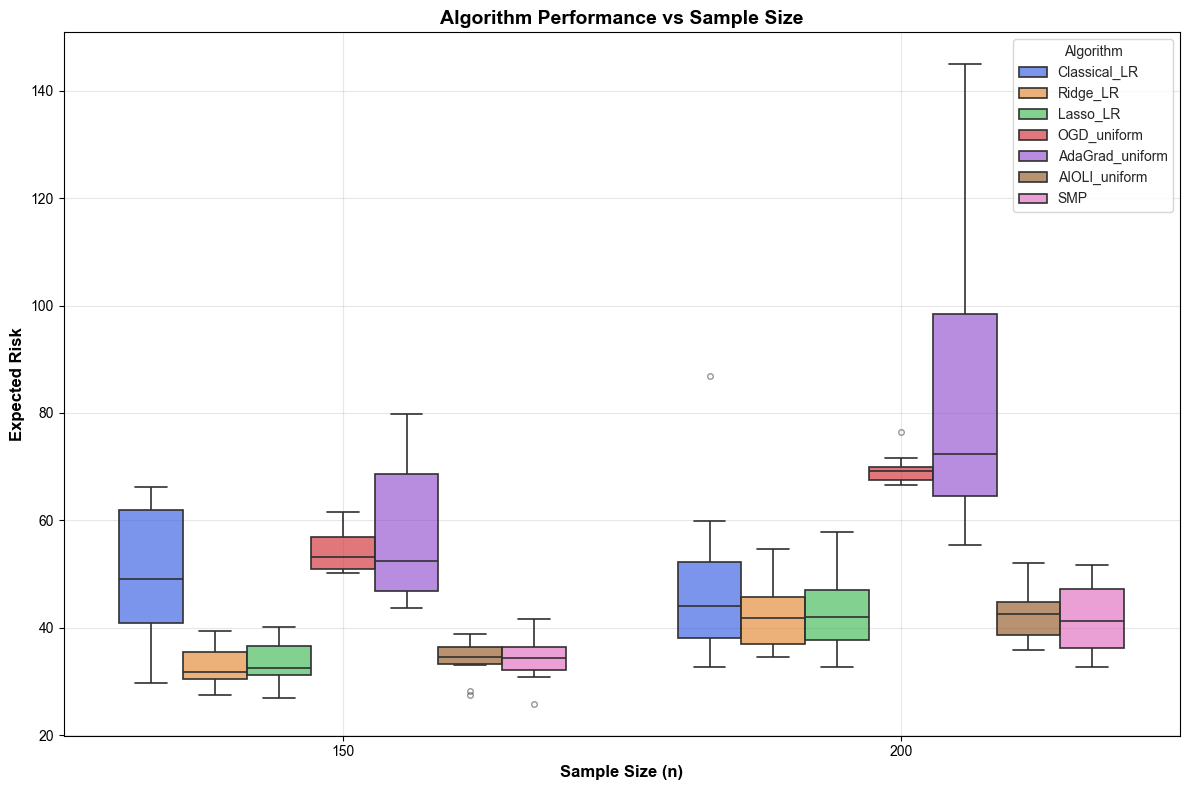

In [399]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR","AdaGrad_uniform","OGD_uniform", "Classical_LR"] ,raw_data= high_dimensional_large_n[1])

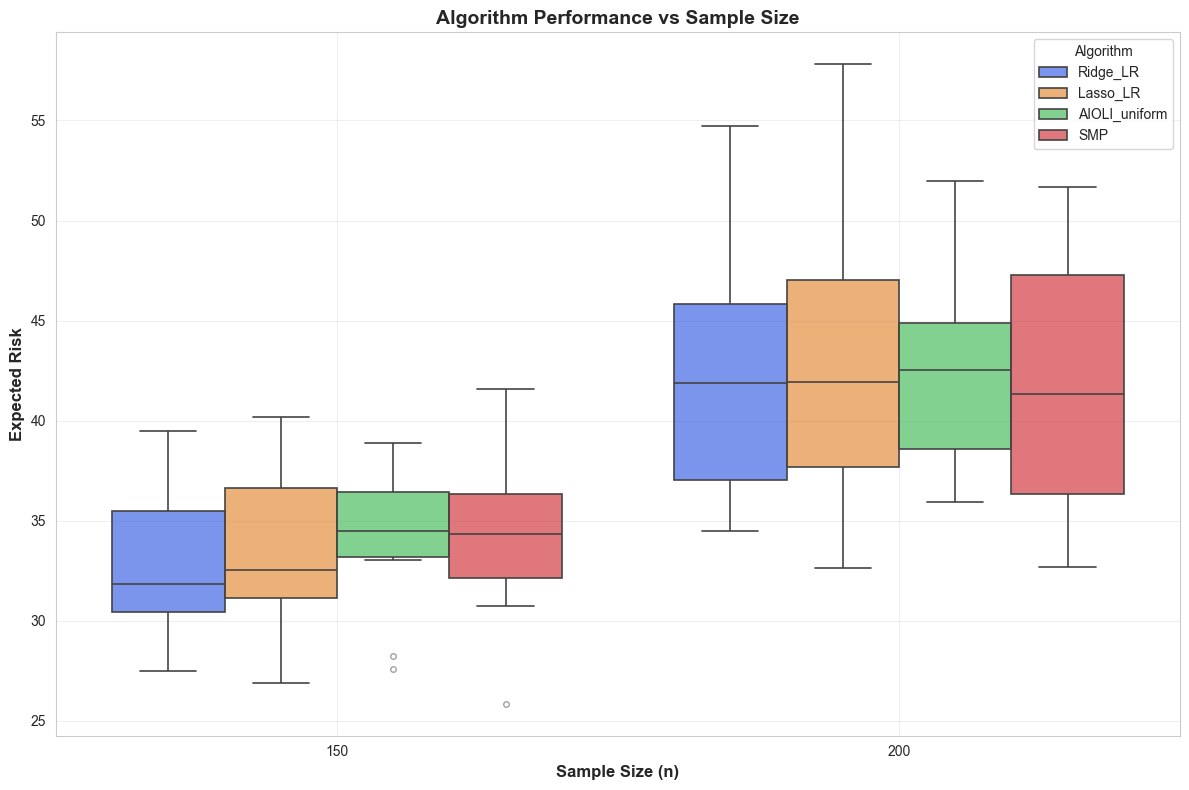

In [398]:
plot_simulation_results(algorithms = ["AIOLI_uniform", "SMP","Lasso_LR", "Ridge_LR"] ,raw_data= high_dimensional_large_n[1])

In [580]:
well_specified_changing_n = simulations_changing_n([10,50,100], well_specified, filename = "well_specified_changing_n")

Running simulations for n = 10

10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505
Dataset is balanced
Lasso LR was fit manually
Run 1 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.513
Lasso LR was fit manually
Run 2 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.498
Lasso LR was fit manually
Run 3 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.499
Lasso LR was fit manually
Run 4 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.505
Lasso LR was fit manually
Run 5 finished
10 (training) samples were generated in the well specified balanced setting. Using 3 variable

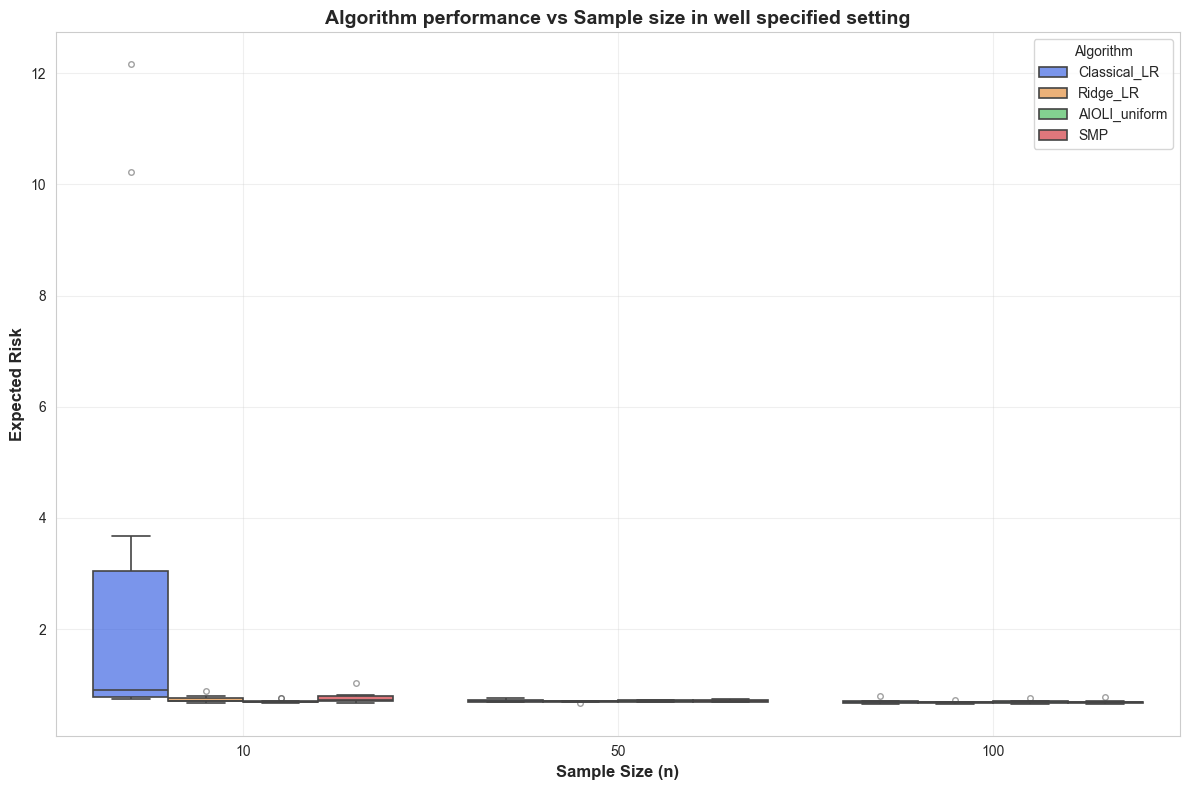

In [582]:
plot_simulation_results(algorithms = ["AIOLI_uniform","Classical_LR", "SMP", "Ridge_LR"] ,raw_data= well_specified_changing_n[1],  title= "Algorithm performance vs Sample size in well specified setting")

# Datasets

In [ ]:
# to push

In [289]:

import kagglehub
import os

# Set cache to current directory
os.environ['KAGGLEHUB_CACHE'] = os.getcwd()

# Download latest version ﷿﷿﷿ returns the local path to the dataset folder
path = kagglehub.dataset_download("ashrafkhan94/oil-spill")
print("Dataset downloaded to:", path)
print("Files:", os.listdir(path)[0])  # inspect actual filename(s)
filename = os.listdir(path)[0]

Dataset downloaded to: C:\Users\marie\PycharmProjects\Thesis_Online-to-batch_Logistic-Regression\datasets\ashrafkhan94\oil-spill\versions\1
Files: oil-spill.csv


In [290]:
csv_file = os.path.join(path, filename)  # adjust name based on os.listdir(path) output
df = pd.read_csv(csv_file, header = None)

In [291]:
df = df.drop(df.columns[0],axis=1) # Remove first column because its for analysis based on the image number and its not one of the predictive variables.

In [292]:
df

,1,2,3,4,5,6,7,8,9,10,...,40,41,42,43,44,45,46,47,48,49
0,2558,1506.09,456.63,90,6395000.0,40.88,7.89,29780.0,0.19,214.7,...,2850.00,1000.00,763.16,135.46,3.73,0,33243.19,65.74,7.95,1
1,22325,79.11,841.03,180,55812500.0,51.11,1.21,61900.0,0.02,901.7,...,5750.00,11500.00,9593.48,1648.80,0.60,0,51572.04,65.73,6.26,0
2,115,1449.85,608.43,88,287500.0,40.42,7.34,3340.0,0.18,86.1,...,1400.00,250.00,150.00,45.13,9.33,1,31692.84,65.81,7.84,1
3,1201,1562.53,295.65,66,3002500.0,42.40,7.97,18030.0,0.19,166.5,...,6041.52,761.58,453.21,144.97,13.33,1,37696.21,65.67,8.07,1
4,312,950.27,440.86,37,780000.0,41.43,7.03,3350.0,0.17,232.8,...,1320.04,710.63,512.54,109.16,2.58,0,29038.17,65.66,7.35,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
932,12,92.42,364.42,135,97200.0,59.42,10.34,884.0,0.17,110.0,...,381.84,254.56,84.85,146.97,4.50,0,2593.50,65.85,6.39,0
933,11,98.82,248.64,159,89100.0,59.64,10.18,831.0,0.17,107.2,...,284.60,180.00,150.00,51.96,1.90,0,4361.25,65.70,6.53,0
934,14,25.14,428.86,24,113400.0,60.14,17.94,847.0,0.30,133.9,...,402.49,180.00,180.00,0.00,2.24,0,2153.05,65.91,6.12,0
935,10,96.00,451.30,68,81000.0,59.90,15.01,831.0,0.25,97.5,...,402.49,180.00,90.00,73.48,4.47,0,2421.43,65.97,6.32,0


In [293]:
trialdata = generate_data("well specified")

500 (training) samples were generated in the well specified balanced setting. Using 3 variable(s), with an average P(Y=1) of 0.499


In [294]:
oil_x = df[df.columns[:-1]]

In [295]:
oil_y = df[df.columns[-1]]
oil_y.replace(0, -1, inplace=True)
oil_y

0      1
1     -1
2      1
3      1
4     -1
      ..
932   -1
933   -1
934   -1
935   -1
936   -1
Name: 49, Length: 937, dtype: int64

In [296]:
test_size = round(0.5*df.shape[0])
oil_x_train = oil_x[test_size:]
oil_y_train = oil_y[test_size:]
oil_x_test = oil_x[:test_size]
oil_y_test = oil_y[:test_size]

In [297]:
# def evaluate_on_data(data_x,data_y):
#
#     # Separate test and train
#     test_size = round(0.5*data_x.shape[0])
#     x_train = np.array(data_x[test_size:])
#     y_train = np.array(data_y[test_size:])
#     x_test = np.array(data_x[:test_size])
#     y_test = np.array(data_y[:test_size])
#
#     d = data_x.shape[1]
#
#     # Run algorithms
#     ## Get SMOTE dataset for unbalanced cases
#     sm = SMOTE(data_x = x_train, data_y = y_train, S = 100)
#     smote_x, smote_y = sm.apply_smote()
#
#     ogd = online_gd(data_y=y_train, data_x=x_train, B=default_B)
#     adagrad = online_AdaGrad(data_y=y_train, data_x=x_train, B_vector = np.repeat(5,d))
#     aioli_model = AIOLI()
#     ai = aioli_model.fit(data_y=y_train, data_x=x_train, X=default_X, B=default_B/13)
#     classic_LR = classic_logistic_regression(data_x=x_train, data_y=y_train)
#     ridge_LR = ridge_logistic_regression(data_x=x_train, data_y=y_train)
#     lasso_LR = lasso_logistic_regression(data_x=x_train, data_y=y_train)
#     smp = sample_minmax_predictor(x_train, y_train)
#     ridge_smp = ridge_sample_minmax_predictor(x_train, y_train)
#     classic_LR_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)
#
#     # OTB estimates
#     # OGD
#     OGD_OTB_uniform = calculate_OTB(ogd["All_Betas"], "uniform")
#     OGD_OTB_Suffix  = calculate_OTB(ogd["All_Betas"], "suffix_averaging")
#     OGD_OTB_lastit  = calculate_OTB(ogd["All_Betas"], "last_iterate")
#     # AdaGrad
#     adagrad_OTB_uniform = calculate_OTB(adagrad["All_Betas"], "uniform")
#     adagrad_OTB_Suffix  = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
#     adagrad_OTB_lastit  = calculate_OTB(adagrad["All_Betas"], "last_iterate")
#
#     ############################## TEST RESULTS ##############################
#     # OGD
#     loss_OGD_uniform_test = log_loss(OGD_OTB_uniform, x_test, y_test)
#     loss_OGD_Suffix_test  = log_loss(OGD_OTB_Suffix,  x_test, y_test)
#     loss_OGD_lastit_test  = log_loss(OGD_OTB_lastit,  x_test, y_test)
#
#     # Adagrad
#     loss_adagrad_uniform_test = log_loss(adagrad_OTB_uniform, x_test, y_test)
#     loss_adagrad_Suffix_test  = log_loss(adagrad_OTB_Suffix,  x_test, y_test)
#     loss_adagrad_lastit_test  = log_loss(adagrad_OTB_lastit,  x_test, y_test)
#
#     # AIOLI
#     loss_AIOLI_uniform_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
#     loss_AIOLI_Suffix_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="suffix_averaging")["loss"]
#     loss_AIOLI_lastit_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="last_iterate")["loss"]
#
#     # Logistic Regression
#     loss_LR_test = log_loss(classic_LR["Batch_estimate"], x_test, y_test)
#     loss_LR_smote_test = log_loss(classic_LR_smote["Batch_estimate"], x_test, y_test)
#     loss_LR_Ridge_test = log_loss(ridge_LR["Batch_estimate"],   x_test, y_test)
#     loss_LR_Lasso_test = log_loss(lasso_LR["Batch_estimate"],   x_test, y_test)
#
#     # SMP
#     smp_result = smp.get_new_loss(x_test, y_test)
#     ridge_smp_result = ridge_smp.get_new_loss(x_test, y_test)
#
#     algorithms_test = {
#         "Classical_LR":  {"loss": loss_LR_test},
#         "Classical_LR_SMOTE":      {"loss": loss_LR_smote_test},
#         "Ridge_LR":      {"loss": loss_LR_Ridge_test},
#         "Lasso_LR":      {"loss": loss_LR_Lasso_test},
#         "OGD_uniform": {"loss": loss_OGD_uniform_test},
#         "OGD_Suffix":  {"loss": loss_OGD_Suffix_test},
#         "OGD_Last_iterate": {"loss": loss_OGD_lastit_test},
#         "AdaGrad_uniform": {"loss": loss_adagrad_uniform_test},
#         "AdaGrad_Suffix":  {"loss": loss_adagrad_Suffix_test},
#         "AdaGrad_Last_iterate": {"loss": loss_adagrad_lastit_test},
#         "AIOLI_uniform": {"loss": loss_AIOLI_uniform_test},
#         "AIOLI_Suffix":  {"loss": loss_AIOLI_Suffix_test},
#         "AIOLI_lastit":  {"loss": loss_AIOLI_lastit_test},
#         "SMP":      {"loss": smp_result["loss"]},
#         "Ridge_SMP":      {"loss": ridge_smp_result["loss"]}
#     }
#
#     test_set_results = []
#     for name, metrics in algorithms_test.items():
#          test_set_results.append({
#             "algorithm": name,
#             **metrics
#         })
#
#     return {
#             "test_results": pd.DataFrame(test_set_results)
#         }


In [298]:
type(np.array(oil_x))

numpy.ndarray

In [299]:
# evaluate_on_data(oil_x,oil_y)

# Ignore from here on, it's simply code to test some functions/debugging

## AIOLI averaging outside sigmoid

In [ ]:
# class AIOLI:
#     def __init__(self):
#         self.first_sum  = []
#         self.etas_gradients = []
#         self.x0 = [] # Initializer for minimizing algorithm
#         self.reg_lambda = 0
#         self.train_size = 0
#         self.d = 0
#         self.n = 0
#
#     # Define function to minimize for AIOLI
#     @staticmethod # Because I dont use the self
#     def parameter_function_AIOLI(b, xt, reg_lambda, first_sum, etas_gradients):
#         l_hat = np.inner(b,first_sum) + b @ etas_gradients @ b #  @ to do matrix-vector multiplication
#         # Use function np.logaddexp = log(exp(x1) + exp(x2)) to ensure numerical stability, not sure how it works
#         result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)**2
#         return result
#
#     def new_point_loss(self,X,Y, OTB_method):
#         convergence_new = 0
#         beta_hat = np.zeros((self.train_size,self.d))
#         first_sum  = np.zeros(self.d)
#         etas_gradients = np.zeros((self.d,self.d))
#         for t in range(self.train_size):
#             # Minimize using data up until t-1
#             result = minimize(self.parameter_function_AIOLI, self.x0, method = "l-bfgs-b", args=(X, self.reg_lambda,first_sum, etas_gradients))
#             beta_hat[t] = result.x
#             convergence_new += result.success
#             # Update minimization elements for next round
#             first_sum += self.first_sum[t]
#             etas_gradients += self.etas_gradients[t]
#
#         # Get OTB
#         big_beta = calculate_OTB(beta_hat, OTB_method)
#
#         # Suffer loss
#         loss_point = (1/self.n)*np.sum(np.logaddexp(0,-Y*np.inner(X,beta_hat)))
#
#         return loss_point
#
#     def new_data_loss(self,new_data_x,new_data_y, OTB_method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None):
#         start_time = datetime.datetime.now()
#         new_losses = [ self.new_point_loss(X,Y, OTB_method) for (X,Y) in zip(new_data_x,new_data_y) ] # Zip pairs the rows of x and y
#         end_time = datetime.datetime.now()
#         return{
#                 "runtime" : (end_time - start_time).total_seconds(),
#                 "loss" : sum(new_losses)
#             }
#
#
#     def fit(self, data_y, data_x, B, X, OTB_method = None, OTB_average_proportion = None, minimize_method = "l-bfgs-b", dynamic_B = False):
#         """AIOLI
#         This is the function to run AIOLI.
#
#         Parameters
#         ---------
#         data_y : ndarray
#             Vector with outcome(y) values. Dimensions: n x 1
#         data_x: ndarray
#             Array with independent variables. Dimensions: n x d
#         B: float
#             Radius of the L2 ball constraint for the parameter vector beta
#         X: float
#             Radius of the L2 ball constraint for the feature vector x"""
#         # Record start time
#         start_time = datetime.datetime.now()
#
#         # Get data dimensions
#         self.n = data_x.shape[0]
#         n = self.n
#         self.d = data_x.shape[1]
#         d = self.d
#         self.x0 = np.zeros(d) # Initializer for minimizing algorithm
#         self.train_size = n
#         # Initialize vectors for storage
#         betas = np.zeros((n, d))
#         ys = np.zeros(n)
#         y_hats = np.zeros(n)
#         loss = np.zeros(n)
#         etas = np.zeros(n)
#         gradients = np.zeros((n, d))
#         self.reg_lambda = 1 / (B**2)
#
#         # Keep sums for loss functions
#         self.first_sum  = np.zeros((n, d))
#         self.etas_gradients = np.zeros((n,d,d))
#         first_sum  = np.zeros(d)
#         etas_gradients = np.zeros((d,d))
#
#         # Track convergence
#         convergence = 0
#         minimizer_gradient = 0
#
#         # Run Algorithm
#         for t in range(n):
#             # Get context vector
#             xt = data_x[t]
#
#             # Update beta parameter
#             # noinspection PyTypeChecker # This is to avoid the underlining which
#             if t == 0: # Initialize to 0 for first round
#                 betas[t] = np.zeros(d)
#             else:
#                 result = minimize(self.parameter_function_AIOLI,
#                                   np.zeros(d),
#                                   method = minimize_method,
#                                   args=(xt, self.reg_lambda,first_sum, etas_gradients),
#                                   options = {"maxiter":100000}
#                                   )
#                 betas[t] = result.x
#                 convergence += result.success
#                 minimizer_gradient += np.linalg.norm(result.jac)
#
#             # # Project beta onto set
#             # betas[t] = project_onto_l2_ball(beta_tilde,B)
#             # betas[t] = self.x0
#
#             # Generate prediction
#             y_hats[t] = np.inner(xt,betas[t])
#
#             # Observe true y from data
#             ys[t] = data_y[t]
#
#              # Compute gradient
#             gradients[t] = -ys[t]*xt*sig(-ys[t]*np.inner(xt,betas[t]))
#
#             # Estimate eta
#             etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)
#
#             # Suffer loss
#             loss[t] = np.logaddexp(0,-ys[t]*np.inner(xt,betas[t]))
#
#             # Compute elements for AIOLI loss function
#
#             fs = gradients[t]*(1 - etas[t]*np.inner(betas[t],gradients[t]))
#             eg = (etas[t] / 2) * np.outer(gradients[t], gradients[t])
#             self.first_sum[t] = fs
#             self.etas_gradients[t] = eg
#             first_sum += fs
#             etas_gradients += eg
#             # Here this is separated and a bit reiterative because else the way the vector is stored messes up with the function. I tried multiple ways and this seemed the best one.
#
#             # Dynamic Hyperparameter tuning
#             if dynamic_B:
#                 B = max(B, np.linalg.norm(betas[t]))
#
#         # for loop ends
#
#         # Get Batch estimate
#         betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)
#
#         # Get Batch estimate loss
#         loss_OTB = log_loss(betas_OTB,data_x, data_y)
#
#         end_time = datetime.datetime.now()
#
#         return{
#             "runtime" : (end_time - start_time).total_seconds(),
#             "Total_Loss" : loss_OTB,
#             "Online_Loss" : sum(loss),
#             "Batch_estimate": betas_OTB,
#             "All_Betas": betas,
#             "convergence" : convergence,
#             "minimizer_gradient" : minimizer_gradient
#         }
#


## Tests

In [300]:
#etas = np.array([1/np.sqrt(3),1/np.sqrt(3),1/np.sqrt(3)])
#xt = np.array([1,2,3])
#betas = np.array([[2,2,5],[1,1,3],[4,5,6]])
#reg_lambda = 0.3
#gradients = np.array([[2,2,5],[1,1,3],[4,5,6]])
#b = np.array([1,2,3])
#sum_loss = 5


#(sum(etas)/2)*np.inner((b-betas[2]),gradients[2])*np.inner(gradients[2],(b-betas[2]))
#np.linalg.norm(etas)


In [301]:
#diff = b - betas
#inner_prod = np.sum(gradients * diff,axis = 1)
#np.sum(np.sum(etas)/2 * inner_prod**2)

In [302]:
# x0 = np.array([0,0,0])

#res = minimize(parameter_function_AIOLI, x0, method = "L-BFGS-B", args=(xt, reg_lambda, sum_loss,first_sum, etas_gradients))
#parameter_function_AIOLI(x0, xt, betas, etas, reg_lambda, sum_loss,gradients)
#res.x

In [303]:
# diff = b - betas
# gs_bs = np.sum(gradients * diff,axis = 1)
# quadratic = np.sum(np.sum(etas)/2 * gs_bs**2)
#
# l_hat = sum_loss + np.sum(gs_bs) + quadratic
#
# l_hat + np.log(1+np.exp(np.inner(b,xt))) + np.log(1+np.exp(np.inner(-b,xt))) + reg_lambda*np.linalg.norm(b)

## Generate data

In [304]:
# n = 1000
#
# mean = [20, 5, 2]
# cov = [[1, 0, 0], [0, 3, 0], [0,0,2]]  # diagonal covariance
# d = np.shape(cov)[1]
# y = np.random.binomial(n=1, p=0.3, size=n)
#
# x1, x2, x3 = np.random.multivariate_normal(mean, cov, size = n).T
# plt.plot(x1, x2, 'x')
# plt.axis('equal')
# plt.show()
#
# plt.plot(x1, x3, 'x')
# plt.axis('equal')
# plt.show()


In [305]:
# x = np.random.multivariate_normal(mean, cov, size = n)
# sns.countplot(x=y)
# plt.show()


In [306]:
# np.log(1000)

## OTB conversion proof tests

In [307]:
# weights = np.array([0.3,0.7])
# values = np.array([2,3])
#
# print(np.sum(values))
# print(np.sum(weights*values))